# Residual-gas background vs photon energy

Run 58890 is the residual-gas scan used as the photon-energy-dependent background for the config-1 glycine scans.

This notebook starts from the shot-resolved static-XAS file written by `compute_static_xas_cfg1.py`. The energy sections have already been detected from the local-DAQ train-ID starts, so the analysis here focuses on:

- averaging eTOF and iTOF spectra per photon energy,
- visualising the background as a 2D energy x TOF map,
- quantifying how the background intensity and shape change with photon energy,
- creating a per-energy background table that can be used for glycine subtraction,
- optionally loading a glycine signal map and plotting signal, background, and signal minus background.

In [1]:
import os, sys


from pathlib import Path
os.environ["FLASH_ENV"] = "remote"

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [2]:
import sys
from pathlib import Path

import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

%matplotlib inline

# Locate repo root and put analysis/scripts on the import path.
cwd = Path.cwd().resolve()
repo_root = Path("/home/mmanresa/glycine26/")

# 2. Safety check to make sure the folder structure is what we expect
scripts_dir = repo_root / "analysis" / "scripts"
if not scripts_dir.exists():
    raise RuntimeError(f"Could not find scripts folder at: {scripts_dir}")

# 3. Add it to Python's path
sys.path.insert(0, str(scripts_dir))

import config as path_config  # noqa: E402
import config
from compute_aggregates import load_aggregates  # noqa: E402
import pandas as pd

In [4]:
CARBON_TRANSMISSION_CSV = Path(config.COMBINED_DIR).parent / "Calibrations" / "carbon_transmission_pos17mm_3mm_aperture_run58871.csv"

carbon_calib = pd.read_csv(CARBON_TRANSMISSION_CSV)

def carbon_correction_factor(incident_energy_eV):
    incident_energy_eV = np.asarray(incident_energy_eV, dtype=float)
    return np.interp(
        incident_energy_eV,
        carbon_calib["energy_eV"],
        carbon_calib["correction_factor"],
        left=carbon_calib["correction_factor"].iloc[0],
        right=carbon_calib["correction_factor"].iloc[-1],
    )

carbon_calib.head()

,energy_eV,transmission_model,relative_transmission,correction_factor,absolute_correction_to_unity,edge_model_only,low_energy_poly,is_extrapolated
0,260.00,0.923504,1.088299,0.918865,1.082832,0.834262,0.923504,True
1,260.05,0.923034,1.087745,0.919333,1.083383,0.834132,0.923034,True
2,260.10,0.922565,1.087192,0.919801,1.083935,0.834002,0.922565,True
3,260.15,0.922095,1.086638,0.920270,1.084487,0.833873,0.922095,True
4,260.20,0.921625,1.086085,0.920739,1.085040,0.833743,0.921625,True


## Inputs (old, before doing aggregates)

`BACKGROUND_STATIC_H5` should already exist after running:

```bash
FLASH_ENV=remote python analysis/scripts/compute_static_xas_cfg1.py \
  analysis/configs/tof_static/background_run58890.py
```

For the subtraction plots, use either:

- `SIGNAL_STATIC_H5`: a compatible glycine static-XAS output, or
- `SIGNAL_AGG_FILES`: the aggregate files used by `cfg1_etof_vs_energy.ipynb`, one file per photon energy.

Leave both as `None` while developing the background-only part.

In [15]:
RUN_NO = 58890

BACKGROUND_STATIC_H5 = (
    Path(path_config.COMBINED_DIR).parent
    / "xas_static"
    / f"run{RUN_NO}_cfg1_static_xas.h5"
)

# Option A: point this at a glycine static-XAS file with datasets matching
# compute_static_xas_cfg1.py output.
SIGNAL_STATIC_H5 = None
# Example:
# SIGNAL_STATIC_H5 = Path(path_config.COMBINED_DIR).parent / "xas_static" / "runXXXXX_cfg1_static_xas.h5"

# Option B: use config-1 aggregate files, as in cfg1_etof_vs_energy.ipynb.
# Each tuple is (path, photon_energy_eV). If SIGNAL_GMD_BIN is None, the
# notebook averages D/G across GMD bins weighted by n_per_bin.
SIGNAL_AGG_FILES = None
# Example:
# SIGNAL_AGG_FILES = [
#     (Path(path_config.COMBINED_DIR) / "glycine_WL_scan_271.0eV_aggregates.h5", 271.0),
#     (Path(path_config.COMBINED_DIR) / "glycine_WL_scan_271.5eV_aggregates.h5", 271.5),
# ]
SIGNAL_GMD_BIN = None

# TOF histogram edges. Use np.arange for a fixed bin width.
# The calibration notebook uses 1-unit eTOF bins over [0, 5000].
# Do not write np.linspace(0, 5000, 1): that creates only one edge,
# i.e. zero bins.
ETOF_BIN_WIDTH = 1.0
ETOF_BIN_EDGES = np.arange(0.0, 5000.0 + ETOF_BIN_WIDTH, ETOF_BIN_WIDTH)

# Ions are usually much later; keep a wider range by default.
ITOF_BIN_WIDTH = 20.0
ITOF_BIN_EDGES = np.arange(0.0, 40000.0 + ITOF_BIN_WIDTH, ITOF_BIN_WIDTH)

# Duplicate nominal energies: "keep_last" keeps the later repeat,
# "merge" averages repeats weighted by summed GMD, "keep_all" keeps sections.
DUPLICATE_ENERGY_POLICY = "keep_last"

# Optional scale factor for subtraction. Keep at 1.0 for GMD-normalised maps.
BACKGROUND_SCALE = 1.0

# Display ranges. Use (None, None) for full range.
ETOF_RANGE = (None, None)
ITOF_RANGE = (None, None)

print("background:", BACKGROUND_STATIC_H5)
print("signal static:", SIGNAL_STATIC_H5)
print("signal aggs  :", SIGNAL_AGG_FILES)

background: /asap3/flash/gpfs/fl24/2026/data/11022188/processed/xas_static/run58890_cfg1_static_xas.h5
signal static: None
signal aggs  : None


## Helpers

In [5]:
def load_static_xas(path):
    """Load a compute_static_xas_cfg1.py output file."""
    path = Path(path)
    with h5py.File(path, "r") as f:
        out = {
            "path": path,
            "tofs_e": f["tofs_e"][...],
            "tofs_i": f["tofs_i"][...],
            "gmd": f["gmd"][...],
            "n_shots": f["n_shots"][...].astype(np.int64),
            "energies": f["nominal_energies"][...].astype(np.float64),
            "attrs": dict(f.attrs),
        }
    return out


def spectra_per_energy(tofs, gmd, n_shots, edges):
    """Histogram TOF hits per energy section and normalise by summed GMD."""
    n_energy = tofs.shape[0]
    n_bins = len(edges) - 1
    spec = np.full((n_energy, n_bins), np.nan, dtype=np.float64)
    sum_gmd = np.zeros(n_energy, dtype=np.float64)
    valid_shots = np.zeros(n_energy, dtype=np.int64)
    hit_counts = np.zeros(n_energy, dtype=np.int64)

    for i in range(n_energy):
        n = int(n_shots[i])
        if n <= 0:
            continue

        g = gmd[i, :n]
        ok = np.isfinite(g)
        if not ok.any():
            continue

        hits = tofs[i, :n][ok].ravel()
        hits = hits[hits > 0]
        sum_gmd[i] = float(np.nansum(g[ok]))
        valid_shots[i] = int(ok.sum())
        hit_counts[i] = int(hits.size)

        if hits.size == 0 or sum_gmd[i] <= 0:
            continue

        hist, _ = np.histogram(hits, bins=edges)
        spec[i] = hist / sum_gmd[i]

    return spec, sum_gmd, valid_shots, hit_counts


def merge_repeated_energies(spec, energies, weights=None):
    """Weighted-average spectra for repeated nominal energies."""
    energies = np.asarray(energies, dtype=np.float64)
    unique = np.array(sorted(np.unique(energies)))
    merged = np.full((unique.size, spec.shape[1]), np.nan, dtype=np.float64)
    if weights is None:
        weights = np.ones(energies.size, dtype=np.float64)
    weights = np.asarray(weights, dtype=np.float64)

    for i, e in enumerate(unique):
        idx = np.where(energies == e)[0]
        rows = spec[idx]
        w = weights[idx]
        valid = np.isfinite(rows).any(axis=1) & np.isfinite(w) & (w > 0)
        if not valid.any():
            continue
        merged[i] = np.average(rows[valid], axis=0, weights=w[valid])
    return unique, merged


def resolve_duplicate_energies(spec, energies, *, policy="keep_last", weights=None):
    """Handle repeated nominal energies after section-wise spectra are made."""
    energies = np.asarray(energies, dtype=np.float64)
    if policy == "keep_all":
        return energies, spec
    if policy == "merge":
        return merge_repeated_energies(spec, energies, weights=weights)
    if policy != "keep_last":
        raise ValueError("DUPLICATE_ENERGY_POLICY must be 'keep_last', 'merge', or 'keep_all'")

    keep = []
    for e in sorted(np.unique(energies)):
        idx = np.where(energies == e)[0]
        keep.append(idx[-1])
    keep = np.array(keep, dtype=np.int64)
    return energies[keep], spec[keep]


def half_step_edges(x):
    x = np.asarray(x, dtype=np.float64)
    if x.size == 1:
        return np.array([x[0] - 0.5, x[0] + 0.5])
    mid = 0.5 * (x[:-1] + x[1:])
    return np.concatenate([[2 * x[0] - mid[0]], mid, [2 * x[-1] - mid[-1]]])


def plot_map(spec, tof_edges, energies, *, title, clabel, tof_range=(None, None), cmap="viridis"):
    e_edges = half_step_edges(energies)
    finite = spec[np.isfinite(spec)]
    vmin = float(np.nanpercentile(finite, 1)) if finite.size else 0.0
    vmax = float(np.nanpercentile(finite, 99.5)) if finite.size else 1.0
    fig, ax = plt.subplots(figsize=(9, 4.8), constrained_layout=True)
    im = ax.pcolormesh(tof_edges, e_edges, spec, shading="auto", cmap=cmap, vmin=vmin, vmax=vmax)
    fig.colorbar(im, ax=ax, label=clabel)
    ax.set_xlabel("TOF (100 ps ticks)")
    ax.set_ylabel("nominal photon energy (eV)")
    ax.set_title(title)
    if tof_range[0] is not None or tof_range[1] is not None:
        ax.set_xlim(tof_range)
    return fig, ax


def plot_diff_map(diff, tof_edges, energies, *, title, clabel, tof_range=(None, None)):
    e_edges = half_step_edges(energies)
    finite = diff[np.isfinite(diff)]
    lim = float(np.nanpercentile(np.abs(finite), 99.0)) if finite.size else 1.0
    if not np.isfinite(lim) or lim <= 0:
        lim = 1.0
    fig, ax = plt.subplots(figsize=(9, 4.8), constrained_layout=True)
    norm = TwoSlopeNorm(vmin=-lim, vcenter=0.0, vmax=lim)
    im = ax.pcolormesh(tof_edges, e_edges, diff, shading="auto", cmap="RdBu_r", norm=norm)
    fig.colorbar(im, ax=ax, label=clabel)
    ax.set_xlabel("TOF (100 ps ticks)")
    ax.set_ylabel("nominal photon energy (eV)")
    ax.set_title(title)
    if tof_range[0] is not None or tof_range[1] is not None:
        ax.set_xlim(tof_range)
    return fig, ax

In [6]:
def load_signal_aggregate_map(files, *, gmd_bin=None):
    """Load config-1 spectral aggregates into an energy x eTOF map."""
    files = sorted([(Path(p), float(e)) for p, e in files], key=lambda pe: pe[1])
    energies = np.array([e for _, e in files], dtype=np.float64)
    stack = []
    tof_edges = None
    shot_counts = []

    for path, energy in files:
        agg = load_aggregates(path)
        if agg.config != 1:
            raise ValueError(f"{path.name}: expected config 1, found config {agg.config}")
        if agg.mode != "spectral":
            raise ValueError(f"{path.name}: expected spectral aggregate, found {agg.mode!r}")
        if tof_edges is None:
            tof_edges = agg.tof_edges
        elif not np.array_equal(tof_edges, agg.tof_edges):
            raise ValueError(f"{path.name}: eTOF edges do not match previous aggregate files")

        with np.errstate(invalid="ignore", divide="ignore"):
            per_gmd = agg.D / agg.G[:, None]

        if gmd_bin is None:
            weights = np.asarray(agg.n_per_bin, dtype=np.float64)
            valid = np.isfinite(per_gmd).any(axis=1) & (weights > 0)
            if not valid.any():
                spec = np.full(per_gmd.shape[1], np.nan)
            else:
                spec = np.average(per_gmd[valid], axis=0, weights=weights[valid])
        else:
            spec = per_gmd[int(gmd_bin)]

        stack.append(spec)
        shot_counts.append(int(np.sum(agg.n_per_bin)))
        print(f"{energy:7.2f} eV  {path.name}  shots={shot_counts[-1]}")

    return {
        "energies": energies,
        "tof_edges": tof_edges,
        "spec_e": np.vstack(stack),
        "shot_counts": np.array(shot_counts, dtype=np.int64),
    }


def rebin_background_if_needed(bg_source, source_edges, target_edges):
    """Return background on target edges; currently requires identical bins."""
    if not np.array_equal(source_edges, target_edges):
        raise ValueError(
            "background and signal TOF edges differ. Re-run this notebook with "
            "ETOF_BIN_EDGES matching the aggregate TOF edges, or add explicit rebinning."
        )
    return bg_source


def _tof_lineout_to_ke(tof_edges, y, tof_range, *, density=True):
    """
    Convert one TOF-binned lineout to a KE-axis lineout.

    If density=True:
        y is divided by the calibrated KE bin width, so output is per eV.

    If density=False:
        y is only relabelled onto KE centres, so output remains per TOF bin.
    """
    tof_edges = np.asarray(tof_edges, dtype=float)
    y = np.asarray(y, dtype=float)

    tof_cent = 0.5 * (tof_edges[:-1] + tof_edges[1:])

    mask = np.ones_like(tof_cent, dtype=bool)
    if tof_range[0] is not None:
        mask &= tof_cent >= tof_range[0]
    if tof_range[1] is not None:
        mask &= tof_cent <= tof_range[1]

    idx = np.where(mask)[0]
    if idx.size == 0:
        raise ValueError(f"No TOF bins inside range {tof_range}")

    lo = int(idx[0])
    hi = int(idx[-1]) + 1

    ke_edges_s = tof_to_ke(tof_edges[lo:hi + 1])
    ke_cent_s = tof_to_ke(tof_cent[lo:hi])
    y_s = y[lo:hi].astype(float)

    if not np.all(np.isfinite(ke_edges_s)):
        raise ValueError("Some KE edges are NaN. Choose a TOF range fully above t0.")

    if density:
        dke = np.abs(np.diff(ke_edges_s))
        with np.errstate(invalid="ignore", divide="ignore"):
            y_s = y_s / dke

    good = np.isfinite(ke_cent_s) & np.isfinite(y_s)
    order = np.argsort(ke_cent_s[good])

    return ke_cent_s[good][order], y_s[good][order]


def row_normalise_binding_map(
    binding_map,
    *,
    be_edges=None,
    be_x_edges=None,
    integral_mode="signed",
):
    """
    Row-normalise a binding-energy map by its BE integral.

    For equal BE bins:
        provide be_edges, shape (n_be_bins + 1,)

    For unequal/native BE bins:
        provide be_x_edges, shape either:
            (n_energy + 1, n_be_bins + 1), from pcolormesh
        or
            (n_energy, n_be_bins + 1)

    integral_mode:
        "signed"   -> integral of the actual signal
        "positive" -> integral of positive part only
        "absolute" -> integral of absolute intensity
    """
    binding_map = np.asarray(binding_map, dtype=float)
    n_rows, n_cols = binding_map.shape

    if be_x_edges is not None:
        bx = np.asarray(be_x_edges, dtype=float)
        widths = np.abs(np.diff(bx, axis=1))

        if widths.shape[0] == n_rows + 1:
            # pcolormesh vertex grid. Top/bottom widths should be equivalent,
            # but averaging is robust.
            widths = 0.5 * (widths[:-1, :] + widths[1:, :])
        elif widths.shape[0] != n_rows:
            raise ValueError(
                f"be_x_edges gives widths with {widths.shape[0]} rows, "
                f"but binding_map has {n_rows} rows"
            )

    elif be_edges is not None:
        be_edges = np.asarray(be_edges, dtype=float)
        widths_1d = np.abs(np.diff(be_edges))

        if widths_1d.size != n_cols:
            raise ValueError(
                f"be_edges describes {widths_1d.size} bins, "
                f"but binding_map has {n_cols} columns. "
                "You are probably using equal-grid be_edges with an unequal/native BE map."
            )

        widths = np.broadcast_to(widths_1d[None, :], binding_map.shape)

    else:
        raise ValueError("Provide either be_edges or be_x_edges.")

    if widths.shape != binding_map.shape:
        raise ValueError(
            f"width shape {widths.shape} does not match binding_map shape {binding_map.shape}"
        )

    if integral_mode == "signed":
        integrand = binding_map
    elif integral_mode == "positive":
        integrand = np.where(binding_map > 0, binding_map, 0.0)
    elif integral_mode == "absolute":
        integrand = np.abs(binding_map)
    else:
        raise ValueError("integral_mode must be 'signed', 'positive', or 'absolute'")

    binding_integral = np.nansum(integrand * widths, axis=1)

    with np.errstate(invalid="ignore", divide="ignore"):
        binding_map_norm = binding_map / binding_integral[:, None]

    binding_map_norm[~np.isfinite(binding_map_norm)] = np.nan

    return binding_map_norm, binding_integral

## Load and average run 58890

In [7]:
bg = (BACKGROUND_STATIC_H5)

bg_spec_e_raw, bg_sum_gmd, bg_valid_shots, bg_hits_e = spectra_per_energy(
    bg["tofs_e"], bg["gmd"], bg["n_shots"], ETOF_BIN_EDGES
)
bg_spec_i_raw, _, _, bg_hits_i = spectra_per_energy(
    bg["tofs_i"], bg["gmd"], bg["n_shots"], ITOF_BIN_EDGES
)

bg_energies, bg_spec_e = resolve_duplicate_energies(
    bg_spec_e_raw, bg["energies"], policy=DUPLICATE_ENERGY_POLICY, weights=bg_sum_gmd
)
_, bg_spec_i = resolve_duplicate_energies(
    bg_spec_i_raw, bg["energies"], policy=DUPLICATE_ENERGY_POLICY, weights=bg_sum_gmd
)

print(f"loaded {bg['path'].name}")
print(f"sections              : {bg['energies'].size}")
print(f"plotted energies       : {bg_energies.size} ({DUPLICATE_ENERGY_POLICY})")
print(f"shots total            : {int(bg['n_shots'].sum())}")
print(f"signal bunch range attr: {tuple(bg['attrs'].get('signal_bunch_range', []))}")
print(f"section source attr    : {bg['attrs'].get('section_source', 'not recorded')}")

for i, e in enumerate(bg["energies"]):
    print(
        f"section {i:2d}  E={e:6.2f} eV  "
        f"shots={int(bg['n_shots'][i]):7d}  "
        f"sumGMD={bg_sum_gmd[i]:10.3g}  "
        f"eHits={bg_hits_e[i]:8d}  iHits={bg_hits_i[i]:8d}"
    )

NameError: name 'BACKGROUND_STATIC_H5' is not defined

## Background 2D maps

In [13]:
plot_map(
    bg_spec_e,
    ETOF_BIN_EDGES,
    bg_energies,
    title="Residual-gas eTOF background vs photon energy",
    clabel="eTOF hits / summed GMD / bin",
    tof_range=ETOF_RANGE,
)
plt.show()

plot_map(
    bg_spec_i,
    ITOF_BIN_EDGES,
    bg_energies,
    title="Residual-gas iTOF background vs photon energy",
    clabel="iTOF hits / summed GMD / bin",
    tof_range=ITOF_RANGE,
)
plt.show()

NameError: name 'bg_spec_e' is not defined

## Background aggregates

In [8]:
# --- Load residual-gas background aggregates -------------------------

import re
from compute_aggregates import load_aggregates

BACKGROUND_AGG_DIR = config.COMBINED_DIR / "background_run58890_per_energy"
BACKGROUND_GLOB = "background_*eV_run58890_aggregates_etof1.h5"
BACKGROUND_ENERGY_RE = re.compile(
    r"^background_(\d+(?:\.\d+)?)eV_run58890_aggregates_etof1\.h5$"
)

MAX_ENERGY = None  # or 279.5 if you want to restrict

def _energy_from_background_agg_name(p):
    m = BACKGROUND_ENERGY_RE.fullmatch(Path(p).name)
    if not m:
        raise ValueError(f"could not parse energy from {p}")
    return float(m.group(1))

bg_agg_files = []
for p in sorted(Path(BACKGROUND_AGG_DIR).glob(BACKGROUND_GLOB)):
    e = _energy_from_background_agg_name(p)
    if MAX_ENERGY is None or e <= MAX_ENERGY:
        bg_agg_files.append((p, e))

bg_agg_files = sorted(bg_agg_files, key=lambda pe: pe[1])

print(f"{len(bg_agg_files)} background aggregate files:")
for p, e in bg_agg_files:
    print(f"  {e:7.2f} eV  {p.name}")

# --- Load eTOF -> KE calibration ------------------------------------

from pathlib import Path
import json
import numpy as np

CALIB_PATH = Path(config.COMBINED_DIR).parent / "Calibrations" / "etof_energy_calibration_t0_scan.json"

with open(CALIB_PATH, "r", encoding="utf-8") as fh:
    calib = json.load(fh)

best_t0 = calib["t0_tof_units"]
best_slope = calib["slope_eV_tof_unit2"]
best_E0 = calib["E0_eV"]

def KE_from_TOF(t):
    t = np.asarray(t, dtype=float)
    with np.errstate(divide="ignore", invalid="ignore"):
        ke = best_slope / (t - best_t0)**2 + best_E0
    return np.where(t > best_t0, ke, np.nan)

tof_to_ke = KE_from_TOF

9 background aggregate files:
   271.00 eV  background_271.0eV_run58890_aggregates_etof1.h5
   271.50 eV  background_271.5eV_run58890_aggregates_etof1.h5
   272.00 eV  background_272.0eV_run58890_aggregates_etof1.h5
   272.50 eV  background_272.5eV_run58890_aggregates_etof1.h5
   273.00 eV  background_273.0eV_run58890_aggregates_etof1.h5
   273.50 eV  background_273.5eV_run58890_aggregates_etof1.h5
   274.00 eV  background_274.0eV_run58890_aggregates_etof1.h5
   274.50 eV  background_274.5eV_run58890_aggregates_etof1.h5
   275.00 eV  background_275.0eV_run58890_aggregates_etof1.h5


In [9]:
# --- Stack aggregate background maps: energy x GMD bin x eTOF --------

bg_agg_energies = np.array([e for _, e in bg_agg_files], dtype=float)

bg_agg_stack = None
bg_agg_n_shots = None
bg_agg_tof_edges = None
bg_agg_gmd_edges = None

for k, (path, e) in enumerate(bg_agg_files):
    agg = load_aggregates(path)

    if agg.config != 1:
        raise ValueError(f"{path.name}: expected config 1, got {agg.config}")
    if agg.mode != "spectral":
        raise ValueError(f"{path.name}: expected spectral mode, got {agg.mode!r}")

    if bg_agg_tof_edges is None:
        bg_agg_tof_edges = agg.tof_edges
        bg_agg_gmd_edges = agg.gmd_edges

        n_E = len(bg_agg_files)
        n_gmd = agg.n_gmd_bins
        n_tof = agg.n_tof

        bg_agg_stack = np.full((n_E, n_gmd, n_tof), np.nan)
        bg_agg_n_shots = np.zeros((n_E, n_gmd), dtype=int)
    else:
        if not np.array_equal(agg.tof_edges, bg_agg_tof_edges):
            raise ValueError(f"{path.name}: tof_edges mismatch")
        if not np.array_equal(agg.gmd_edges, bg_agg_gmd_edges):
            raise ValueError(f"{path.name}: gmd_edges mismatch")

    with np.errstate(invalid="ignore", divide="ignore"):
        bg_agg_stack[k] = agg.D / agg.G[:, None]

    bg_agg_n_shots[k] = agg.n_per_bin

print("background aggregate stack:", bg_agg_stack.shape)
print("energies:", bg_agg_energies)
print("GMD edges:", bg_agg_gmd_edges)
print("TOF:", bg_agg_tof_edges[0], bg_agg_tof_edges[-1], len(bg_agg_tof_edges) - 1)

background aggregate stack: (9, 4, 5000)
energies: [271.  271.5 272.  272.5 273.  273.5 274.  274.5 275. ]
GMD edges: [ 0.  3.  6. 12. 24.]
TOF: 0.0 5000.0 5000


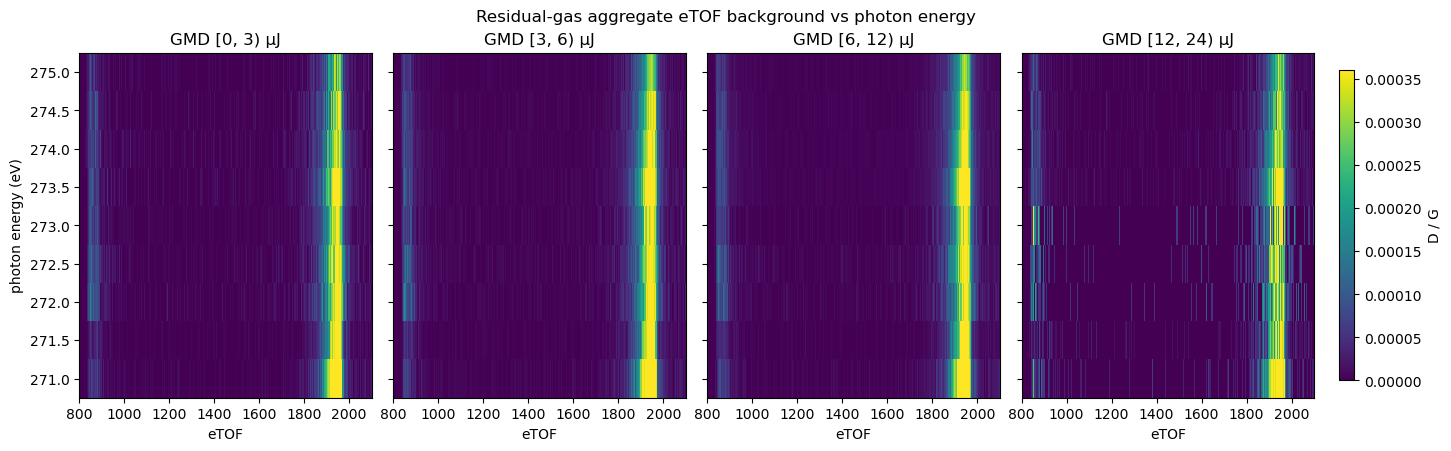

In [10]:
# --- Plot aggregate background 2D maps -------------------------------

def _energy_edges(e):
    e = np.asarray(e, dtype=float)
    if len(e) == 1:
        return np.array([e[0] - 0.25, e[0] + 0.25])
    mid = 0.5 * (e[:-1] + e[1:])
    return np.concatenate([[2 * e[0] - mid[0]], mid, [2 * e[-1] - mid[-1]]])

e_edges = _energy_edges(bg_agg_energies)

finite = bg_agg_stack[np.isfinite(bg_agg_stack)]

VMIN = float(np.nanpercentile(finite, 1))
VMAX = float(np.nanpercentile(finite, 99.5))


TOF_RANGE = (800, 1100)

fig, axes = plt.subplots(
    1, len(bg_agg_gmd_edges) - 1,
    figsize=(3.6 * (len(bg_agg_gmd_edges) - 1), 4.4),
    sharey=True,
    constrained_layout=True,
)
axes = np.atleast_1d(axes)

for g, ax in enumerate(axes):
    pcm = ax.pcolormesh(
        bg_agg_tof_edges,
        e_edges,
        bg_agg_stack[:, g, :],
        cmap="viridis",
        vmin=VMIN,
        vmax=VMAX,
        shading="auto",
    )

    ax.set_title(f"GMD [{bg_agg_gmd_edges[g]:.2g}, {bg_agg_gmd_edges[g+1]:.2g}) µJ")
    ax.set_xlabel("eTOF")
    ax.set_xlim(*TOF_RANGE)
    ax.set_xlim(800,2100)   #Bright feature at around 2000

axes[0].set_ylabel("photon energy (eV)")
cbar = fig.colorbar(pcm, ax=axes, location="right", shrink=0.9, pad=0.02)
cbar.set_label("D / G")
fig.suptitle("Residual-gas aggregate eTOF background vs photon energy")
plt.show()

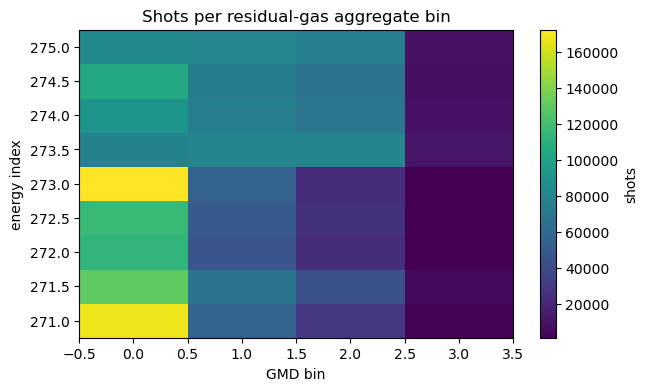

In [11]:
plt.figure(figsize=(7, 4))
plt.imshow(bg_agg_n_shots, aspect="auto", origin="lower")
plt.colorbar(label="shots")
plt.xlabel("GMD bin")
plt.ylabel("energy index")
plt.yticks(np.arange(len(bg_agg_energies)), [f"{e:.1f}" for e in bg_agg_energies])
plt.title("Shots per residual-gas aggregate bin")
plt.show()

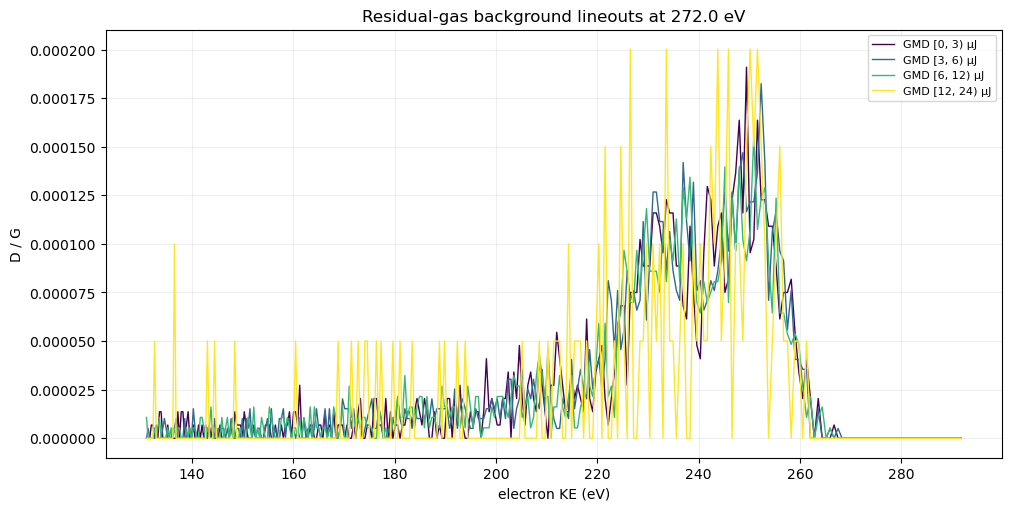

In [12]:
# --- Background-only lineouts: each GMD bin for one photon energy -----

BACKGROUND_ENERGY_TO_PLOT = 272.0
TOF_LINEOUT_RANGE = (800, 1100)
USE_KE_AXIS = True

idx = np.where(np.isclose(bg_agg_energies, BACKGROUND_ENERGY_TO_PLOT))[0]
if len(idx) == 0:
    raise ValueError(
        f"{BACKGROUND_ENERGY_TO_PLOT:.1f} eV not found in bg_agg_energies: "
        f"{bg_agg_energies}"
    )

i = int(idx[0])

tof_cent = 0.5 * (bg_agg_tof_edges[:-1] + bg_agg_tof_edges[1:])
tof_mask = np.ones_like(tof_cent, dtype=bool)
if TOF_LINEOUT_RANGE[0] is not None:
    tof_mask &= tof_cent >= TOF_LINEOUT_RANGE[0]
if TOF_LINEOUT_RANGE[1] is not None:
    tof_mask &= tof_cent <= TOF_LINEOUT_RANGE[1]

if USE_KE_AXIS:
    x = tof_to_ke(tof_cent[tof_mask])
    good = np.isfinite(x)
    order = np.argsort(x[good])
    x_plot = x[good][order]
    xlabel = "electron KE (eV)"
else:
    good = np.ones(np.count_nonzero(tof_mask), dtype=bool)
    order = np.arange(np.count_nonzero(tof_mask))
    x_plot = tof_cent[tof_mask]
    xlabel = "eTOF"

cmap = plt.get_cmap("viridis")
n_gmd = len(bg_agg_gmd_edges) - 1

fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)

for g in range(n_gmd):
    y = bg_agg_stack[i, g, tof_mask]
    y = y[good][order]

    ax.plot(
        x_plot,
        y,
        lw=1.0,
        color=cmap(g / max(n_gmd - 1, 1)),
        label=f"GMD [{bg_agg_gmd_edges[g]:.2g}, {bg_agg_gmd_edges[g+1]:.2g}) µJ",
    )

ax.set_xlabel(xlabel)
ax.set_ylabel("D / G")
ax.set_title(f"Residual-gas background lineouts at {bg_agg_energies[i]:.1f} eV")
ax.grid(alpha=0.2)
ax.legend(fontsize=8)
plt.show()

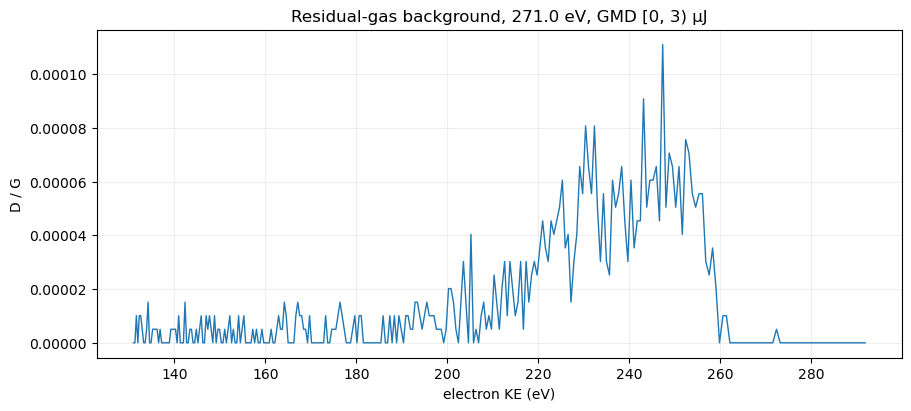

Plotted background energy: 271.00 eV
GMD bin: [0.0, 3.0) µJ
max D/G in plotted range: 0.000110981


In [13]:
# --- Background lineout: first GMD bin, lowest photon energy ----------

GMD_BIN = 0
TOF_LINEOUT_RANGE = (800, 1100)
USE_KE_AXIS = True

# Lowest available background photon energy
i = int(np.nanargmin(bg_agg_energies))
e = bg_agg_energies[i]

tof_cent = 0.5 * (bg_agg_tof_edges[:-1] + bg_agg_tof_edges[1:])

tof_mask = np.ones_like(tof_cent, dtype=bool)
if TOF_LINEOUT_RANGE[0] is not None:
    tof_mask &= tof_cent >= TOF_LINEOUT_RANGE[0]
if TOF_LINEOUT_RANGE[1] is not None:
    tof_mask &= tof_cent <= TOF_LINEOUT_RANGE[1]

y = bg_agg_stack[i, GMD_BIN, tof_mask]

if USE_KE_AXIS:
    x = tof_to_ke(tof_cent[tof_mask])
    good = np.isfinite(x)
    x = x[good]
    y = y[good]

    order = np.argsort(x)
    x = x[order]
    y = y[order]
    xlabel = "electron KE (eV)"
else:
    x = tof_cent[tof_mask]
    xlabel = "eTOF"

fig, ax = plt.subplots(figsize=(9, 4), constrained_layout=True)
ax.plot(x, y, lw=1.0)

ax.set_xlabel(xlabel)
ax.set_ylabel("D / G")
ax.set_title(
    f"Residual-gas background, {e:.1f} eV, "
    f"GMD [{bg_agg_gmd_edges[GMD_BIN]:.2g}, {bg_agg_gmd_edges[GMD_BIN+1]:.2g}) µJ"
)
ax.grid(alpha=0.2)

plt.show()

print(f"Plotted background energy: {e:.2f} eV")
print(f"GMD bin: [{bg_agg_gmd_edges[GMD_BIN]}, {bg_agg_gmd_edges[GMD_BIN+1]}) µJ")
print(f"max D/G in plotted range: {np.nanmax(y):.6g}")

## Load the signal runs

### Old

In [339]:
# --- Option A: explicit list (path, energy_eV) -----------------------
FILES = None  # e.g. [("runXXX_aggregates.h5", 290.0), ...]

# --- Option B: glob a directory and parse eV from filename ----------
AGG_DIR    = config.COMBINED_DIR
GLOB = "glycine_WL_scan_*eV_aggregates_etof1.h5"

ENERGY_RE = re.compile(
    r"^glycine_WL_scan_(\d+(?:\.\d+)?)eV_aggregates_etof1$"
)

MAX_ENERGY = 288

# --- Display / cosmetics -------------------------------------------
TOF_RANGE  = (None, None)   # plot x-limits in TOF units; (None, None) = full
VMIN, VMAX = None, None     # shared colour scale for plot 1; None = auto
DIFF_SYM   = True           # symmetric diverging colormap for plot 2

# --- Discover files ------------------------------------------------
def _energy_from_name(p):
    m = ENERGY_RE.search(Path(p).stem)
    if not m:
        raise ValueError(
            f"could not parse photon energy (looked for '<num>eV') from {p}"
        )
    return float(m.group(1))

if FILES is None:
    paths = sorted(Path(AGG_DIR).glob(GLOB))
    if not paths:
        raise FileNotFoundError(f"no files match {AGG_DIR}/{GLOB}")
    FILES = [(p, _energy_from_name(p)) for p in paths]

FILES = [(p, e) for p, e in FILES if e <= MAX_ENERGY]


def _is_decimal_zero_energy_file(p):
    return re.search(r"_\d+\.0eV_aggregates_etof1\.h5$", Path(p).name) is not None

# For repeated nominal energies, prefer the file written as "279.0eV"
# over the bare "279eV".
dedup = {}
for p, e in FILES:
    old = dedup.get(e)
    if old is None:
        dedup[e] = (p, e)
    elif _is_decimal_zero_energy_file(p):
        dedup[e] = (p, e)

FILES = sorted(dedup.values(), key=lambda pe: pe[1])

print(f"{len(FILES)} aggregate files:")
for p, e in FILES:
    print(f"  {e:>8.2f} eV  {Path(p).name}")

32 aggregate files:
    270.00 eV  glycine_WL_scan_270.0eV_aggregates_etof1.h5
    270.50 eV  glycine_WL_scan_270.5eV_aggregates_etof1.h5
    271.00 eV  glycine_WL_scan_271.0eV_aggregates_etof1.h5
    271.50 eV  glycine_WL_scan_271.5eV_aggregates_etof1.h5
    272.00 eV  glycine_WL_scan_272.0eV_aggregates_etof1.h5
    272.50 eV  glycine_WL_scan_272.5eV_aggregates_etof1.h5
    273.00 eV  glycine_WL_scan_273.0eV_aggregates_etof1.h5
    273.50 eV  glycine_WL_scan_273.5eV_aggregates_etof1.h5
    274.00 eV  glycine_WL_scan_274.0eV_aggregates_etof1.h5
    274.50 eV  glycine_WL_scan_274.5eV_aggregates_etof1.h5
    275.00 eV  glycine_WL_scan_275.0eV_aggregates_etof1.h5
    275.50 eV  glycine_WL_scan_275.5eV_aggregates_etof1.h5
    276.00 eV  glycine_WL_scan_276.0eV_aggregates_etof1.h5
    276.50 eV  glycine_WL_scan_276.5eV_aggregates_etof1.h5
    277.00 eV  glycine_WL_scan_277.0eV_aggregates_etof1.h5
    277.50 eV  glycine_WL_scan_277.5eV_aggregates_etof1.h5
    278.00 eV  glycine_WL_scan_278.0

In [340]:
energies = np.array([e for _, e in FILES], dtype=np.float64)

stack = None        # (n_E, n_gmd, n_tof) normalised D/G
n_shots = None      # (n_E, n_gmd) shot count per bin
tof_edges = None
gmd_edges = None

for k, (path, e) in enumerate(FILES):
    agg = load_aggregates(path)
    if agg.config != 1:
        raise ValueError(
            f"{Path(path).name}: config={agg.config}, expected 1"
        )
    if agg.mode != "spectral":
        raise ValueError(
            f"{Path(path).name}: mode={agg.mode!r}, expected 'spectral'"
        )
    if tof_edges is None:
        tof_edges = agg.tof_edges
        gmd_edges = agg.gmd_edges
        n_E   = len(FILES)
        n_gmd = agg.n_gmd_bins
        n_tof = agg.n_tof
        stack   = np.full((n_E, n_gmd, n_tof), np.nan, dtype=np.float64)
        n_shots = np.zeros((n_E, n_gmd), dtype=np.int64)
    else:
        if not np.array_equal(agg.tof_edges, tof_edges):
            raise ValueError(
                f"{Path(path).name}: tof_edges mismatch"
            )
        if not np.array_equal(agg.gmd_edges, gmd_edges):
            raise ValueError(
                f"{Path(path).name}: gmd_edges mismatch"
            )

    # D / G per GMD bin; broadcast G along the TOF axis.
    with np.errstate(invalid="ignore", divide="ignore"):
        stack[k] = agg.D / agg.G[:, None]
    n_shots[k] = agg.n_per_bin

tof_cent = 0.5 * (tof_edges[:-1] + tof_edges[1:])
gmd_cent = 0.5 * (gmd_edges[:-1] + gmd_edges[1:])

print(f"stack shape  : {stack.shape}  (n_E, n_gmd, n_tof)")
print(f"GMD bins     : {n_gmd}  edges {gmd_edges}")
print(f"TOF range    : [{tof_edges[0]:.2f}, {tof_edges[-1]:.2f}) in {n_tof} bins")
print(f"energy range : [{energies.min():.2f}, {energies.max():.2f}] eV ({len(energies)} points)")

stack shape  : (32, 4, 5000)  (n_E, n_gmd, n_tof)
GMD bins     : 4  edges [ 0.  3.  6. 12. 24.]
TOF range    : [0.00, 5000.00) in 5000 bins
energy range : [270.00, 288.00] eV (32 points)


### New

In [14]:
# --- Option A: explicit list (path, energy_eV) -----------------------
FILES = None  # e.g. [("runXXX_aggregates.h5", 290.0), ...]

# --- Option B: glob a directory and parse eV from filename ----------
AGG_DIR = config.COMBINED_DIR
GLOB = "glycine_WL_scan_*eV_aggregates_etof1.h5"

ENERGY_RE = re.compile(
    r"^glycine_WL_scan_(\d+(?:\.\d+)?)eV_aggregates_etof1$"
)

MAX_ENERGY = 288.0

# --- Display / cosmetics -------------------------------------------
TOF_RANGE = (None, None)
VMIN, VMAX = None, None
DIFF_SYM = True

# --- Discover files ------------------------------------------------
def _energy_from_name(p):
    m = ENERGY_RE.search(Path(p).stem)
    if not m:
        raise ValueError(
            f"could not parse photon energy (looked for '<num>eV') from {p}"
        )
    return float(m.group(1))


if FILES is None:
    paths = sorted(Path(AGG_DIR).glob(GLOB))
    if not paths:
        raise FileNotFoundError(f"no files match {AGG_DIR}/{GLOB}")
    FILES = [(p, _energy_from_name(p)) for p in paths]

FILES = [(Path(p), float(e)) for p, e in FILES if e <= MAX_ENERGY]
FILES = sorted(FILES, key=lambda pe: (pe[1], Path(pe[0]).name))

# Group files with the same parsed nominal photon energy.
# This intentionally combines e.g. 279eV and 279.0eV.
files_by_energy = {}
for p, e in FILES:
    files_by_energy.setdefault(e, []).append(p)

energies = np.array(sorted(files_by_energy), dtype=np.float64)

print(f"{len(FILES)} aggregate files grouped into {len(energies)} energies:")
for e in energies:
    print(f"  {e:8.2f} eV")
    for p in files_by_energy[e]:
        print(f"      {p.name}")

37 aggregate files grouped into 32 energies:
    270.00 eV
      glycine_WL_scan_270.0eV_aggregates_etof1.h5
    270.50 eV
      glycine_WL_scan_270.5eV_aggregates_etof1.h5
    271.00 eV
      glycine_WL_scan_271.0eV_aggregates_etof1.h5
    271.50 eV
      glycine_WL_scan_271.5eV_aggregates_etof1.h5
    272.00 eV
      glycine_WL_scan_272.0eV_aggregates_etof1.h5
    272.50 eV
      glycine_WL_scan_272.5eV_aggregates_etof1.h5
    273.00 eV
      glycine_WL_scan_273.0eV_aggregates_etof1.h5
    273.50 eV
      glycine_WL_scan_273.5eV_aggregates_etof1.h5
    274.00 eV
      glycine_WL_scan_274.0eV_aggregates_etof1.h5
    274.50 eV
      glycine_WL_scan_274.5eV_aggregates_etof1.h5
    275.00 eV
      glycine_WL_scan_275.0eV_aggregates_etof1.h5
    275.50 eV
      glycine_WL_scan_275.5eV_aggregates_etof1.h5
    276.00 eV
      glycine_WL_scan_276.0eV_aggregates_etof1.h5
    276.50 eV
      glycine_WL_scan_276.5eV_aggregates_etof1.h5
    277.00 eV
      glycine_WL_scan_277.0eV_aggregates_etof

### Inspecting the two scans

In [15]:
# --- Diagnostic: compare each aggregate file before merging -----------

file_rows = []

for path, e in FILES:
    agg = load_aggregates(path)

    if agg.config != 1 or agg.mode != "spectral":
        continue

    n = np.asarray(agg.n_per_bin, dtype=np.float64)
    total_gmd_file = np.asarray(agg.G, dtype=np.float64) * n

    # Reconstruct total eTOF counts per GMD bin and TOF bin.
    D_sum_file = np.nan_to_num(agg.D, nan=0.0) * n[:, None]

    total_counts = np.nansum(D_sum_file)
    total_gmd_sum = np.nansum(total_gmd_file)
    total_shots = int(np.nansum(n))

    yield_per_uJ = total_counts / total_gmd_sum if total_gmd_sum > 0 else np.nan
    counts_per_shot = total_counts / total_shots if total_shots > 0 else np.nan
    gmd_per_shot = total_gmd_sum / total_shots if total_shots > 0 else np.nan

    stem = Path(path).stem
    scan_label = "decimal/.5/.0 scan" if re.search(r"\d+\.\d+eV", stem) else "integer scan"

    file_rows.append({
        "energy": e,
        "path": path,
        "name": Path(path).name,
        "scan_label": scan_label,
        "shots": total_shots,
        "total_counts": total_counts,
        "total_gmd": total_gmd_sum,
        "counts_per_shot": counts_per_shot,
        "gmd_per_shot": gmd_per_shot,
        "yield_per_uJ": yield_per_uJ,
    })

print("Per-file totals:")
for r in file_rows:
    print(
        f"{r['energy']:7.2f} eV  {r['scan_label']:18s}  "
        f"shots={r['shots']:8d}  "
        f"GMD={r['total_gmd']:10.4g} uJ  "
        f"counts={r['total_counts']:10.4g}  "
        f"counts/shot={r['counts_per_shot']:10.4g}  "
        f"GMD/shot={r['gmd_per_shot']:10.4g}  "
        f"counts/uJ={r['yield_per_uJ']:10.4g}  "
        f"{r['name']}"
    )

Per-file totals:
 270.00 eV  decimal/.5/.0 scan  shots=  300328  GMD= 1.337e+06 uJ  counts= 1.525e+06  counts/shot=     5.079  GMD/shot=     4.452  counts/uJ=     1.141  glycine_WL_scan_270.0eV_aggregates_etof1.h5
 270.50 eV  decimal/.5/.0 scan  shots=  301023  GMD= 1.606e+06 uJ  counts= 1.684e+06  counts/shot=     5.593  GMD/shot=     5.335  counts/uJ=     1.049  glycine_WL_scan_270.5eV_aggregates_etof1.h5
 271.00 eV  decimal/.5/.0 scan  shots=  302649  GMD= 1.485e+06 uJ  counts=  1.61e+06  counts/shot=      5.32  GMD/shot=     4.906  counts/uJ=     1.084  glycine_WL_scan_271.0eV_aggregates_etof1.h5
 271.50 eV  decimal/.5/.0 scan  shots=  301982  GMD=  1.51e+06 uJ  counts= 1.607e+06  counts/shot=      5.32  GMD/shot=     4.999  counts/uJ=     1.064  glycine_WL_scan_271.5eV_aggregates_etof1.h5
 272.00 eV  decimal/.5/.0 scan  shots=  301118  GMD= 1.187e+06 uJ  counts= 1.336e+06  counts/shot=     4.438  GMD/shot=     3.943  counts/uJ=     1.126  glycine_WL_scan_272.0eV_aggregates_etof1.h

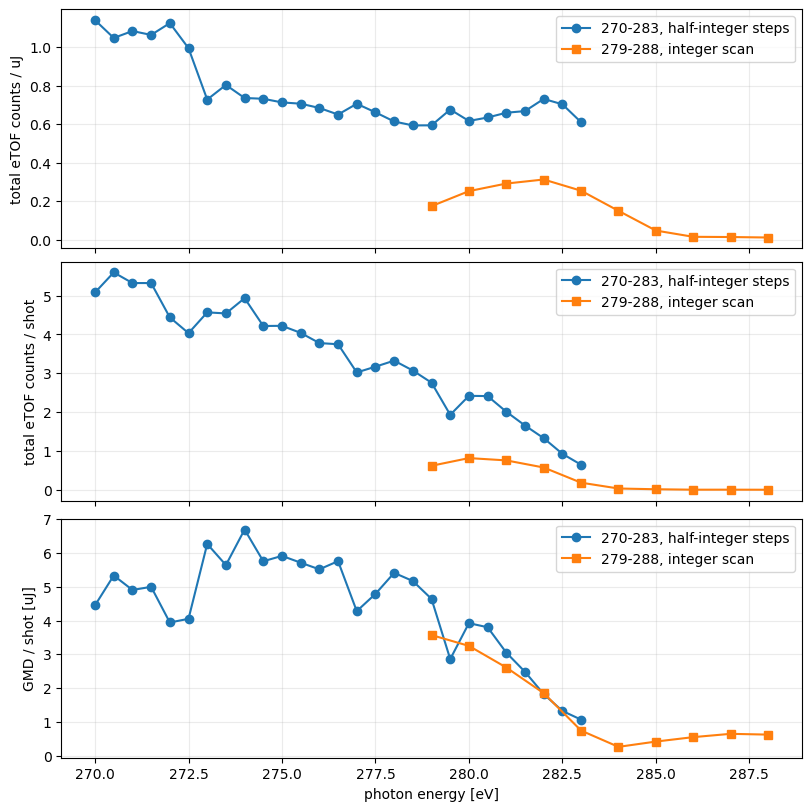

In [16]:
# --- Plot per-file intensity diagnostics ------------------------------

fig, axes = plt.subplots(3, 1, figsize=(8, 8), sharex=True, constrained_layout=True)

scans_to_plot = [
    # (raw_key_in_dict, display_label_for_legend, marker)
    ("decimal/.5/.0 scan", "270-283, half-integer steps", "o"),
    ("integer scan", "279-288, integer scan", "s"),
]

for raw_label, display_label, marker in scans_to_plot:
    rows = [r for r in file_rows if r["scan_label"] == raw_label]
    if not rows:
        continue

    e = np.array([r["energy"] for r in rows])
    y_uJ = np.array([r["yield_per_uJ"] for r in rows])
    y_shot = np.array([r["counts_per_shot"] for r in rows])
    g_shot = np.array([r["gmd_per_shot"] for r in rows])

    order = np.argsort(e)

    # Pass display_label to matplotlib's legend
    axes[0].plot(e[order], y_uJ[order], marker + "-", label=display_label)
    axes[1].plot(e[order], y_shot[order], marker + "-", label=display_label)
    axes[2].plot(e[order], g_shot[order], marker + "-", label=display_label)

axes[0].set_ylabel("total eTOF counts / uJ")
axes[1].set_ylabel("total eTOF counts / shot")
axes[2].set_ylabel("GMD / shot [uJ]")
axes[2].set_xlabel("photon energy [eV]")

for ax in axes:
    ax.grid(alpha=0.25)
    ax.legend()

plt.show()

In [17]:
# --- Diagnostic: did compute_aggregates include closed-shutter trains? -

def _keep_mask_like_compute_aggregates(f, trim_start, trim_end):
    btf = f["between_tdc_files"][:].astype(bool)
    good_pos = np.where(~btf)[0]

    if trim_end > 0:
        good_pos = good_pos[trim_start:-trim_end]
    else:
        good_pos = good_pos[trim_start:]

    keep = np.zeros(btf.shape[0], dtype=bool)
    keep[good_pos] = True
    return keep


def _train_hit_counts(f, tof_edges, chunk_size=1000):
    n_total = f["tofs_e"].shape[0]
    out = np.zeros(n_total, dtype=np.float64)

    tof_lo = float(tof_edges[0])
    tof_hi = float(tof_edges[-1])

    for s in range(0, n_total, chunk_size):
        e = min(s + chunk_size, n_total)
        tofs = f["tofs_e"][s:e]
        out[s:e] = np.count_nonzero(
            (tofs >= tof_lo) & (tofs < tof_hi) & (tofs != 0),
            axis=(1, 2),
        )

    return out


def _classify_open_from_shutter(shutter, train_hits, keep):
    sh = np.asarray(shutter, dtype=np.float64)
    finite = np.isfinite(sh) & keep

    if finite.sum() < 2:
        return None, None, np.nan

    lo, hi = np.nanpercentile(sh[finite], [10, 90])
    thr = 0.5 * (lo + hi)

    high = finite & (sh >= thr)
    low = finite & (sh < thr)

    high_hits = np.nanmean(train_hits[high]) if high.any() else np.nan
    low_hits = np.nanmean(train_hits[low]) if low.any() else np.nan

    # The open state should have more eTOF hits.
    if high_hits >= low_hits:
        is_open = high
        is_closed = low
    else:
        is_open = low
        is_closed = high

    return is_open, is_closed, thr


def _summarise_masked_input(input_h5, mask, *, tof_edges, gmd_edges, chunk_size=1000):
    input_h5 = Path(input_h5)

    total_counts = 0.0
    total_gmd = 0.0
    total_shots = 0
    total_trains = int(np.count_nonzero(mask))

    tof_lo = float(tof_edges[0])
    tof_hi = float(tof_edges[-1])
    gmd_edges = np.asarray(gmd_edges, dtype=float)

    with h5py.File(input_h5, "r") as f:
        n_total = mask.size

        for s in range(0, n_total, chunk_size):
            e = min(s + chunk_size, n_total)
            row_mask = mask[s:e]

            if not row_mask.any():
                continue

            gmd = f["gmd"][s:e][row_mask]
            tofs = f["tofs_e"][s:e][row_mask]

            gmd_flat = gmd.ravel()
            gmd_bin = np.digitize(gmd_flat, gmd_edges) - 1

            valid_shot = (
                np.isfinite(gmd_flat)
                & (gmd_bin >= 0)
                & (gmd_bin < len(gmd_edges) - 1)
            )

            if not valid_shot.any():
                continue

            tofs_flat = tofs.reshape(-1, tofs.shape[-1])
            hits = tofs_flat[valid_shot]

            total_counts += float(np.count_nonzero(
                (hits >= tof_lo) & (hits < tof_hi) & (hits != 0)
            ))
            total_gmd += float(np.nansum(gmd_flat[valid_shot]))
            total_shots += int(valid_shot.sum())

    return {
        "trains": total_trains,
        "shots": total_shots,
        "counts": total_counts,
        "gmd": total_gmd,
        "counts_per_shot": total_counts / total_shots if total_shots else np.nan,
        "gmd_per_shot": total_gmd / total_shots if total_shots else np.nan,
        "counts_per_uJ": total_counts / total_gmd if total_gmd > 0 else np.nan,
    }


for path, e in FILES:
    # Focus on files that actually have shutter information.
    agg = load_aggregates(path)
    input_h5 = Path(agg.metadata["input_h5"])

    with h5py.File(input_h5, "r") as f:
        if "shutter" not in f:
            continue

        trim_start = int(agg.metadata.get("trim_start", 0))
        trim_end = int(agg.metadata.get("trim_end", 0))

        keep = _keep_mask_like_compute_aggregates(f, trim_start, trim_end)
        train_hits = _train_hit_counts(f, agg.tof_edges)
        is_open, is_closed, thr = _classify_open_from_shutter(
            f["shutter"][:],
            train_hits,
            keep,
        )

    if is_open is None:
        print(f"{e:7.2f} eV  {Path(path).name}: could not classify shutter")
        continue

    all_kept = keep
    open_only = is_open
    closed_only = is_closed

    rows = [
        ("all kept     ", _summarise_masked_input(input_h5, all_kept, tof_edges=agg.tof_edges, gmd_edges=agg.gmd_edges)),
        ("shutter open ", _summarise_masked_input(input_h5, open_only, tof_edges=agg.tof_edges, gmd_edges=agg.gmd_edges)),
        ("shutter closed", _summarise_masked_input(input_h5, closed_only, tof_edges=agg.tof_edges, gmd_edges=agg.gmd_edges)),
    ]

    print(f"\n{e:7.2f} eV  {Path(path).name}")
    print(f"  shutter threshold: {thr:.4g}")
    print(f"  open train frac  : {np.count_nonzero(open_only) / np.count_nonzero(keep):.3f}")

    for label, r in rows:
        print(
            f"  {label}: "
            f"trains={r['trains']:7d}  "
            f"shots={r['shots']:9d}  "
            f"counts/shot={r['counts_per_shot']:9.4g}  "
            f"GMD/shot={r['gmd_per_shot']:9.4g}  "
            f"counts/uJ={r['counts_per_uJ']:9.4g}"
        )


 279.00 eV  glycine_WL_scan_279eV_aggregates_etof1.h5
  shutter threshold: 0.9871
  open train frac  : 0.468
  all kept     : trains=   6554  shots=   657875  counts/shot=   0.6233  GMD/shot=     3.57  counts/uJ=   0.1746
  shutter open : trains=   3067  shots=   309292  counts/shot=   0.6282  GMD/shot=    3.596  counts/uJ=   0.1747
  shutter closed: trains=   3457  shots=   348583  counts/shot=    0.619  GMD/shot=    3.547  counts/uJ=   0.1745

 280.00 eV  glycine_WL_scan_280eV_aggregates_etof1.h5
  shutter threshold: 0.9871
  open train frac  : 0.475
  all kept     : trains=   6028  shots=   608134  counts/shot=   0.8207  GMD/shot=    3.249  counts/uJ=   0.2526
  shutter open : trains=   2865  shots=   289040  counts/shot=   0.8229  GMD/shot=    3.251  counts/uJ=   0.2532
  shutter closed: trains=   3163  shots=   319094  counts/shot=   0.8186  GMD/shot=    3.248  counts/uJ=   0.2521

 281.00 eV  glycine_WL_scan_281eV_aggregates_etof1.h5
  shutter threshold: 0.987
  open train frac 

In [18]:
# 1. Verify real aggregate binning
for p, e in FILES[:6]:
    agg = load_aggregates(p)
    d = np.diff(agg.tof_edges)
    print(p.name, "n_tof=", agg.n_tof,
          "tof range=", (agg.tof_edges[0], agg.tof_edges[-1]),
          "bin widths unique first=", np.unique(d)[:5],
          "n_per_bin=", agg.n_per_bin)

# 2. Check whether write_h5 clipped electron hits
import h5py, numpy as np
from pathlib import Path

for p, e in FILES[:5]:
    agg = load_aggregates(p)
    src = Path(agg.metadata["input_h5"])
    with h5py.File(src, "r") as f:
        hc = (f["tofs_e"][:] > 0).sum(axis=2)
        max_slots = f["tofs_e"].shape[2]
    print(
        p.name,
        "max_slots=", max_slots,
        "frac saturated=", np.mean(hc == max_slots),
        "p99=", np.percentile(hc, 99),
        "max=", hc.max(),
    )

glycine_WL_scan_270.0eV_aggregates_etof1.h5 n_tof= 5000 tof range= (0.0, 5000.0) bin widths unique first= [1.] n_per_bin= [144049  67651  69688  18940]
glycine_WL_scan_270.5eV_aggregates_etof1.h5 n_tof= 5000 tof range= (0.0, 5000.0) bin widths unique first= [1.] n_per_bin= [101187  88587  91341  19908]
glycine_WL_scan_271.0eV_aggregates_etof1.h5 n_tof= 5000 tof range= (0.0, 5000.0) bin widths unique first= [1.] n_per_bin= [125970  76021  79812  20846]
glycine_WL_scan_271.5eV_aggregates_etof1.h5 n_tof= 5000 tof range= (0.0, 5000.0) bin widths unique first= [1.] n_per_bin= [115753  83771  84308  18150]
glycine_WL_scan_272.0eV_aggregates_etof1.h5 n_tof= 5000 tof range= (0.0, 5000.0) bin widths unique first= [1.] n_per_bin= [154395  71820  64045  10858]
glycine_WL_scan_272.5eV_aggregates_etof1.h5 n_tof= 5000 tof range= (0.0, 5000.0) bin widths unique first= [1.] n_per_bin= [148269  77960  63971  11130]
glycine_WL_scan_270.0eV_aggregates_etof1.h5 max_slots= 50 frac saturated= 6.594066000006

### Merge the two scans and load

In [20]:
# --- Load and rigorously merge duplicate-energy aggregates ------------
#
# Aggregates store means:
#   agg.D[g] = sum(hit_histograms in GMD bin g) / n_shots_g
#   agg.G[g] = sum(GMD values in GMD bin g) / n_shots_g
#
# For duplicate energies, reconstruct additive quantities first:
#   D_sum = agg.D * n_shots
#   G_sum = agg.G * n_shots
#
# Then rebuild the merged aggregate means:
#   D_mean = sum(D_sum) / sum(n_shots)
#   G_mean = sum(G_sum) / sum(n_shots)
#
# The plotted/used spectrum is:
#   stack = D_mean / G_mean
#
# This is equivalent to sum(D_sum) / sum(G_sum), but keeps the merged
# aggregate quantities available for later use.

D_mean = None        # (n_E, n_gmd, n_tof), merged aggregate <D>
G_mean = None        # (n_E, n_gmd), merged aggregate <G>
stack = None         # (n_E, n_gmd, n_tof), merged <D> / <G>
n_shots = None       # (n_E, n_gmd), merged shot count
total_gmd = None     # (n_E, n_gmd), summed GMD = G_mean * n_shots
tof_edges = None
gmd_edges = None

for k, e in enumerate(energies):
    D_sum_e = None
    G_sum_e = None
    n_sum_e = None

    for path in files_by_energy[e]:
        agg = load_aggregates(path)

        if agg.config != 1:
            raise ValueError(f"{Path(path).name}: config={agg.config}, expected 1")
        if agg.mode != "spectral":
            raise ValueError(f"{Path(path).name}: mode={agg.mode!r}, expected 'spectral'")

        if tof_edges is None:
            tof_edges = agg.tof_edges
            gmd_edges = agg.gmd_edges
            n_E = len(energies)
            n_gmd = agg.n_gmd_bins
            n_tof = agg.n_tof

            D_mean = np.full((n_E, n_gmd, n_tof), np.nan, dtype=np.float64)
            G_mean = np.full((n_E, n_gmd), np.nan, dtype=np.float64)
            stack = np.full((n_E, n_gmd, n_tof), np.nan, dtype=np.float64)
            n_shots = np.zeros((n_E, n_gmd), dtype=np.int64)
            total_gmd = np.zeros((n_E, n_gmd), dtype=np.float64)
        else:
            if not np.array_equal(agg.tof_edges, tof_edges):
                raise ValueError(f"{Path(path).name}: tof_edges mismatch")
            if not np.array_equal(agg.gmd_edges, gmd_edges):
                raise ValueError(f"{Path(path).name}: gmd_edges mismatch")

        n = np.asarray(agg.n_per_bin, dtype=np.float64)
        valid = (n > 0) & np.isfinite(agg.G)

        D_sum = np.zeros_like(agg.D, dtype=np.float64)
        G_sum = np.zeros(agg.n_gmd_bins, dtype=np.float64)

        D_sum[valid] = np.nan_to_num(agg.D[valid], nan=0.0) * n[valid, None]
        G_sum[valid] = agg.G[valid] * n[valid]

        if D_sum_e is None:
            D_sum_e = D_sum
            G_sum_e = G_sum
            n_sum_e = np.asarray(agg.n_per_bin, dtype=np.int64).copy()
        else:
            D_sum_e += D_sum
            G_sum_e += G_sum
            n_sum_e += np.asarray(agg.n_per_bin, dtype=np.int64)

    valid_merged = n_sum_e > 0

    with np.errstate(invalid="ignore", divide="ignore"):
        D_mean[k, valid_merged] = (
            D_sum_e[valid_merged] / n_sum_e[valid_merged, None]
        )
        G_mean[k, valid_merged] = (
            G_sum_e[valid_merged] / n_sum_e[valid_merged]
        )
        stack[k, valid_merged] = (
            D_mean[k, valid_merged] / G_mean[k, valid_merged, None]
        )

    stack[k, ~valid_merged] = np.nan
    n_shots[k] = n_sum_e
    total_gmd[k] = G_sum_e

tof_cent = 0.5 * (tof_edges[:-1] + tof_edges[1:])
gmd_cent = 0.5 * (gmd_edges[:-1] + gmd_edges[1:])

print(f"stack shape  : {stack.shape}  (n_E, n_gmd, n_tof)")
print(f"GMD bins     : {n_gmd}  edges {gmd_edges}")
print(f"TOF range    : [{tof_edges[0]:.2f}, {tof_edges[-1]:.2f}) in {n_tof} bins")
print(f"energy range : [{energies.min():.2f}, {energies.max():.2f}] eV ({len(energies)} points)")

print("\nMerged duplicate-energy groups:")
for k, e in enumerate(energies):
    if len(files_by_energy[e]) > 1:
        print(
            f"  {e:7.2f} eV: {len(files_by_energy[e])} files, "
            f"shots={int(n_shots[k].sum())}, "
            f"total GMD={np.nansum(total_gmd[k]):.4g}"
        )

stack shape  : (32, 4, 5000)  (n_E, n_gmd, n_tof)
GMD bins     : 4  edges [ 0.  3.  6. 12. 24.]
TOF range    : [0.00, 5000.00) in 5000 bins
energy range : [270.00, 288.00] eV (32 points)

Merged duplicate-energy groups:
   279.00 eV: 2 files, shots=959269, total GMD=3.747e+06
   280.00 eV: 2 files, shots=908544, total GMD=3.154e+06
   281.00 eV: 2 files, shots=906662, total GMD=2.497e+06
   282.00 eV: 2 files, shots=904231, total GMD=1.664e+06
   283.00 eV: 2 files, shots=893210, total GMD=7.579e+05


### Further investigation upstream in the pipeline

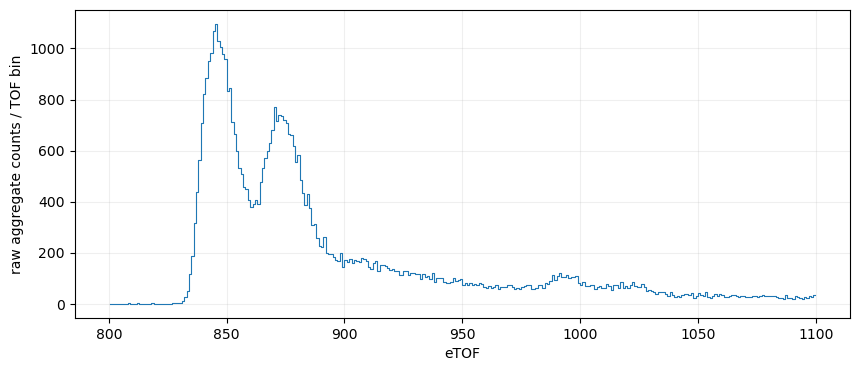

In [22]:
E_TO_PLOT = 274.0
GMD_BIN = 0
TOF_LINEOUT_RANGE = (800, 1100)

i = int(np.argmin(np.abs(energies - E_TO_PLOT)))
p, e = FILES[i]
agg = load_aggregates(p)

tof_cent = 0.5 * (agg.tof_edges[:-1] + agg.tof_edges[1:])
mask = (tof_cent >= TOF_LINEOUT_RANGE[0]) & (tof_cent <= TOF_LINEOUT_RANGE[1])

counts = agg.D[GMD_BIN] * agg.n_per_bin[GMD_BIN]  # undo mean-per-shot
err = np.sqrt(np.maximum(counts, 1))

plt.figure(figsize=(10, 4))
plt.step(tof_cent[mask], counts[mask], where="mid", lw=0.8)
plt.ylabel("raw aggregate counts / TOF bin")
plt.xlabel("eTOF")
plt.grid(alpha=0.2)
plt.show()

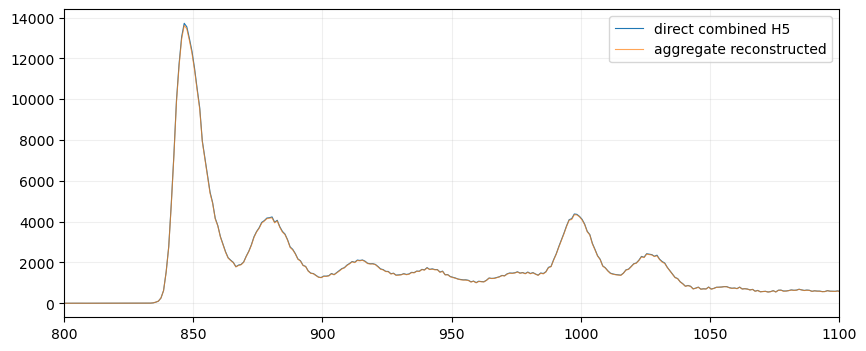

max abs diff: 106.0


In [23]:
p, e = FILES[0]
agg = load_aggregates(p)
src = Path(agg.metadata["input_h5"])

with h5py.File(src, "r") as f:
    keep = ~f["between_tdc_files"][:].astype(bool)
    hits = f["tofs_e"][keep]
    gmd = f["gmd"][keep]

hits_flat = hits.ravel()
hits_flat = hits_flat[hits_flat > 0]

direct_counts, _ = np.histogram(hits_flat, bins=agg.tof_edges)
agg_counts = np.nansum(agg.D * agg.n_per_bin[:, None], axis=0)

plt.figure(figsize=(10,4))
plt.plot(tof_cent, direct_counts, lw=0.8, label="direct combined H5")
plt.plot(tof_cent, agg_counts, lw=0.8, alpha=0.7, label="aggregate reconstructed")
plt.xlim(800, 1100)
plt.legend()
plt.grid(alpha=0.2)
plt.show()

print("max abs diff:", np.nanmax(np.abs(direct_counts - agg_counts)))

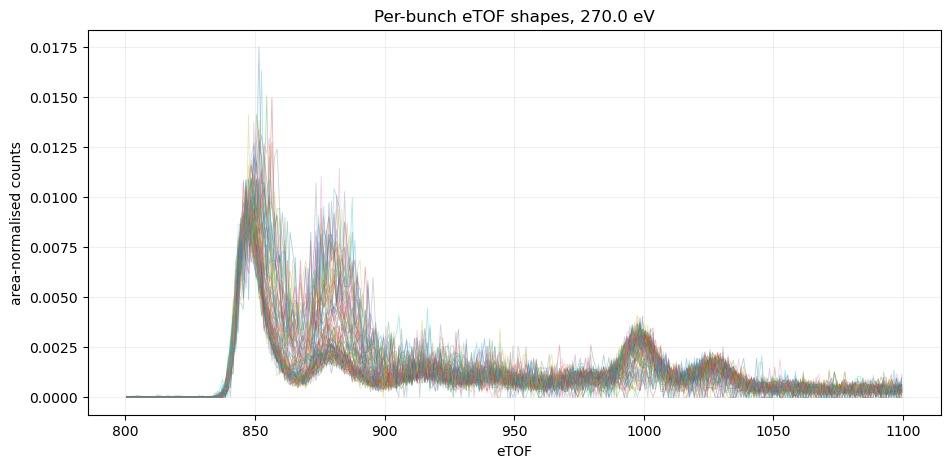

In [24]:
p, e = FILES[0]
agg = load_aggregates(p)
src = Path(agg.metadata["input_h5"])

with h5py.File(src, "r") as f:
    tofs = f["tofs_e"][:]
    gmd = f["gmd"][:]

tof_edges = agg.tof_edges
tof_cent = 0.5 * (tof_edges[:-1] + tof_edges[1:])
mask = (tof_cent >= 800) & (tof_cent <= 1100)

bunches = range(0, tofs.shape[1])

plt.figure(figsize=(11, 5))
for b in bunches:
    hits = tofs[:, b, :].ravel()
    hits = hits[hits > 0]
    if hits.size == 0:
        continue
    counts, _ = np.histogram(hits, bins=tof_edges)
    if counts.sum() > 0:
        plt.plot(tof_cent[mask], counts[mask] / counts.sum(), lw=0.6, alpha=0.35)

plt.xlabel("eTOF")
#plt.xlim(850,900)
plt.ylabel("area-normalised counts")
plt.title(f"Per-bunch eTOF shapes, {e:.1f} eV")
plt.grid(alpha=0.2)
plt.show()

### Plotting by GMD bin

In [ ]:


def _energy_edges(e):
    """Half-step edges around a non-uniform energy axis for pcolormesh."""
    e = np.asarray(e, dtype=np.float64)
    mid = 0.5 * (e[:-1] + e[1:])
    return np.concatenate([[2 * e[0] - mid[0]], mid, [2 * e[-1] - mid[-1]]])

e_edges = _energy_edges(energies)

finite = stack[np.isfinite(stack)]
vmin = VMIN if VMIN is not None else float(np.nanpercentile(finite, 1))
vmax = VMAX if VMAX is not None else float(np.nanpercentile(finite, 99))

vmin = 0
vmax = 0.014

fig, axes = plt.subplots(
    1, n_gmd, figsize=(3.6 * n_gmd, 4.4), sharey=True,
    constrained_layout=True,
)
axes = np.atleast_1d(axes)

for g, ax in enumerate(axes):
    pcm = ax.pcolormesh(
        tof_edges, e_edges, stack[:, g, :],
        cmap="viridis", vmin=vmin, vmax=vmax, shading="auto",
    )
    ax.set_title(
        f"GMD [{gmd_edges[g]:.2g}, {gmd_edges[g + 1]:.2g}) µJ"
    )
    ax.set_xlabel("eTOF")
    if TOF_RANGE[0] is not None or TOF_RANGE[1] is not None:
        ax.set_xlim(TOF_RANGE[0], TOF_RANGE[1])
    ax.set_xlim(800,1100)

axes[0].set_ylabel("photon energy (eV)")
cbar = fig.colorbar(pcm, ax=axes, location="right", shrink=0.9, pad=0.02)
cbar.set_label("D / G  (counts per shot per µJ)")
fig.suptitle("GMD-normalised eTOF spectrum vs photon energy, per GMD bin")
plt.show()

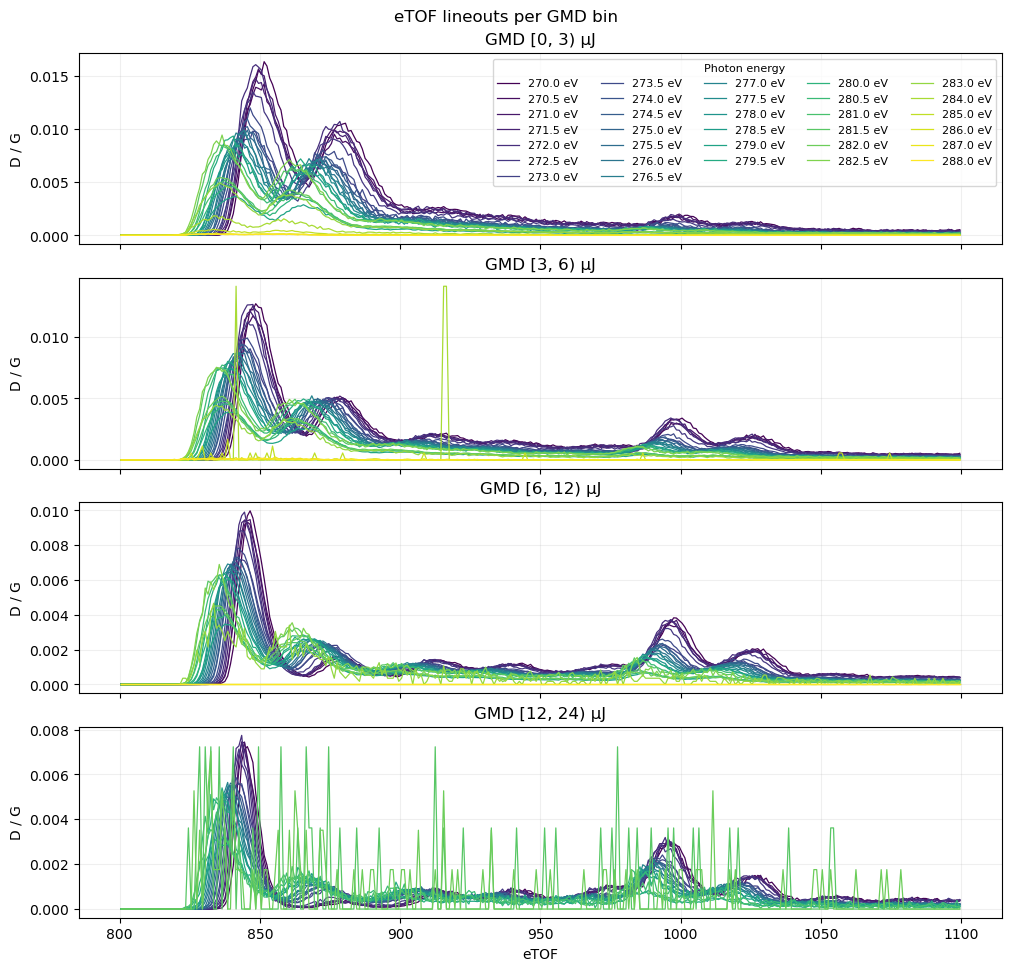

In [26]:
# --- Lineout plot: eTOF spectra per GMD bin -------------------------

ENERGIES_TO_PLOT = None
# Example if you want fewer curves:
# ENERGIES_TO_PLOT = [270.0, 272.0, 274.0, 276.0, 278.0, 279.5]

TOF_LINEOUT_RANGE = (800, 1100)

# Optional smoothing only for visual comparison.
# Set to 1 for no smoothing.
SMOOTH_BINS = 1
# SMOOTH_BINS = 5

def _smooth_1d(y, width):
    if width is None or width <= 1:
        return y
    kernel = np.ones(int(width), dtype=float) / float(width)
    return np.convolve(y, kernel, mode="same")

tof_cent = 0.5 * (tof_edges[:-1] + tof_edges[1:])

if ENERGIES_TO_PLOT is None:
    plot_idx = np.arange(len(energies))
else:
    plot_idx = []
    for e in ENERGIES_TO_PLOT:
        i = int(np.argmin(np.abs(energies - e)))
        if abs(energies[i] - e) > 1e-6:
            print(f"warning: requested {e} eV, using nearest {energies[i]} eV")
        plot_idx.append(i)
    plot_idx = np.array(plot_idx, dtype=int)

xmask = np.ones_like(tof_cent, dtype=bool)
if TOF_LINEOUT_RANGE[0] is not None:
    xmask &= tof_cent >= TOF_LINEOUT_RANGE[0]
if TOF_LINEOUT_RANGE[1] is not None:
    xmask &= tof_cent <= TOF_LINEOUT_RANGE[1]

fig, axes = plt.subplots(
    n_gmd, 1,
    figsize=(10, 2.4 * n_gmd),
    sharex=True,
    constrained_layout=True,
)
axes = np.atleast_1d(axes)

cmap = plt.get_cmap("viridis")
colors = cmap(np.linspace(0, 1, len(plot_idx)))

for g, ax in enumerate(axes):
    for c, i in zip(colors, plot_idx):
        y = stack[i, g, :]
        y = _smooth_1d(y, SMOOTH_BINS)
        ax.plot(
            tof_cent[xmask],
            y[xmask],
            lw=0.9,
            color=c,
            label=f"{energies[i]:.1f} eV",
        )

    ax.set_title(f"GMD [{gmd_edges[g]:.2g}, {gmd_edges[g + 1]:.2g}) µJ")
    ax.set_ylabel("D / G")
    ax.grid(alpha=0.2)

axes[-1].set_xlabel("eTOF")
axes[0].legend(
    title="Photon energy",
    ncols=min(5, len(plot_idx)),
    fontsize=8,
    title_fontsize=8,
    loc="upper right",
)

fig.suptitle("eTOF lineouts per GMD bin")
plt.show()

### Investigating combination of scans

In [66]:
# --- Build separate first-scan and second-scan products ----------------
# first scan  : filenames with decimal energies, e.g. 279.0eV, 279.5eV
# second scan : filenames with integer energies, e.g. 279eV, 280eV

def _scan_family_from_name(path):
    stem = Path(path).stem
    m = re.search(r"_scan_(\d+(?:\.\d+)?)eV_aggregates_etof1$", stem)
    if not m:
        return None
    token = m.group(1)
    return "first_decimal_scan" if "." in token else "second_integer_scan"


def _load_single_aggregate_product(path):
    agg = load_aggregates(path)

    if agg.config != 1:
        raise ValueError(f"{Path(path).name}: config={agg.config}, expected 1")
    if agg.mode != "spectral":
        raise ValueError(f"{Path(path).name}: mode={agg.mode!r}, expected spectral")

    n = np.asarray(agg.n_per_bin, dtype=float)
    total_gmd_g = np.asarray(agg.G, dtype=float) * n

    with np.errstate(invalid="ignore", divide="ignore"):
        per_gmd = agg.D / agg.G[:, None]

    valid_g = np.isfinite(per_gmd).any(axis=1) & (total_gmd_g > 0)

    total = np.full(agg.n_tof, np.nan)
    if valid_g.any():
        total = np.average(per_gmd[valid_g], axis=0, weights=total_gmd_g[valid_g])

    return {
        "agg": agg,
        "per_gmd": per_gmd,
        "total": total,
        "n_shots": np.asarray(agg.n_per_bin, dtype=np.int64),
        "total_gmd": total_gmd_g,
        "tof_edges": agg.tof_edges,
        "gmd_edges": agg.gmd_edges,
    }


scan_products = {}

for path, e in FILES:
    family = _scan_family_from_name(path)
    if family is None:
        continue

    prod = _load_single_aggregate_product(path)

    if not np.array_equal(prod["tof_edges"], tof_edges):
        raise ValueError(f"{Path(path).name}: tof_edges mismatch")
    if not np.array_equal(prod["gmd_edges"], gmd_edges):
        raise ValueError(f"{Path(path).name}: gmd_edges mismatch")

    scan_products[(family, float(e))] = {
        "path": Path(path),
        "energy": float(e),
        **prod,
    }

first_energies = np.array(sorted(e for fam, e in scan_products if fam == "first_decimal_scan"))
second_energies = np.array(sorted(e for fam, e in scan_products if fam == "second_integer_scan"))
overlap_energies = np.array(sorted(set(first_energies).intersection(second_energies)))

print("First scan energies :", first_energies)
print("Second scan energies:", second_energies)
print("Overlap energies    :", overlap_energies)

First scan energies : [270.  270.5 271.  271.5 272.  272.5 273.  273.5 274.  274.5 275.  275.5
 276.  276.5 277.  277.5 278.  278.5 279.  279.5 280.  280.5 281.  281.5
 282.  282.5 283. ]
Second scan energies: [279. 280. 281. 282. 283. 284. 285. 286. 287. 288.]
Overlap energies    : [279. 280. 281. 282. 283.]


279.00 eV  first=0.19351  second=0.069655  second/first=0.36  scale second->first=2.778
280.00 eV  first=0.21086  second=0.10221  second/first=0.4847  scale second->first=2.063
281.00 eV  first=0.22925  second=0.11794  second/first=0.5145  scale second->first=1.944
282.00 eV  first=0.2788  second=0.13116  second/first=0.4704  scale second->first=2.126
283.00 eV  first=0.26193  second=0.10741  second/first=0.4101  scale second->first=2.439


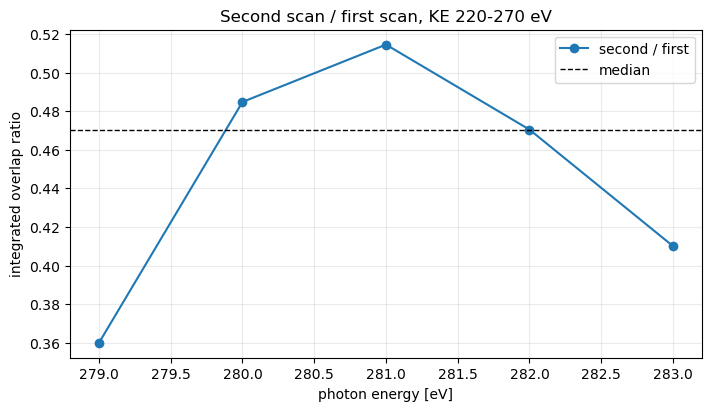

Median second/first ratio: 0.4704
Scatter, std             : 0.05561
Median scale second->first: 2.126


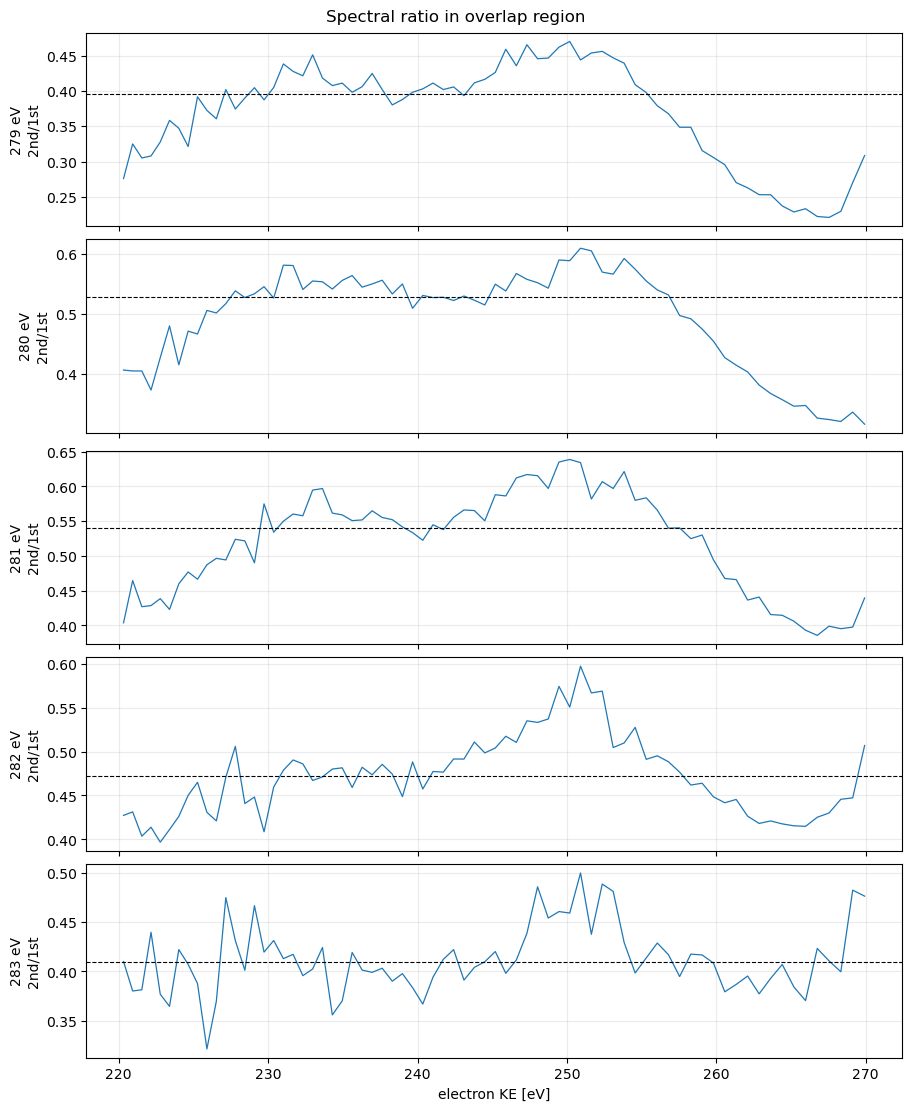

In [67]:
# --- Test 1: overlap ratio between second scan and first scan ----------

KE_RATIO_RANGE = (220, 270)   # change to the KE region you care about
PLOT_SPECTRAL_RATIOS = True

tof_cent = 0.5 * (tof_edges[:-1] + tof_edges[1:])
ke_cent = tof_to_ke(tof_cent)

ke_mask = (
    np.isfinite(ke_cent)
    & (ke_cent >= KE_RATIO_RANGE[0])
    & (ke_cent <= KE_RATIO_RANGE[1])
)

ratio_rows = []

for e in overlap_energies:
    first = scan_products[("first_decimal_scan", float(e))]
    second = scan_products[("second_integer_scan", float(e))]

    y_first = first["total"]
    y_second = second["total"]

    int_first = np.nansum(y_first[ke_mask])
    int_second = np.nansum(y_second[ke_mask])

    ratio_second_over_first = int_second / int_first if int_first > 0 else np.nan
    scale_second_to_first = int_first / int_second if int_second > 0 else np.nan

    ratio_rows.append((e, int_first, int_second, ratio_second_over_first, scale_second_to_first))

    print(
        f"{e:6.2f} eV  "
        f"first={int_first:.5g}  second={int_second:.5g}  "
        f"second/first={ratio_second_over_first:.4g}  "
        f"scale second->first={scale_second_to_first:.4g}"
    )

ratio_rows = np.array(ratio_rows, dtype=float)

fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)

ax.plot(ratio_rows[:, 0], ratio_rows[:, 3], "o-", label="second / first")
ax.axhline(np.nanmedian(ratio_rows[:, 3]), color="k", ls="--", lw=1.0, label="median")

ax.set_xlabel("photon energy [eV]")
ax.set_ylabel("integrated overlap ratio")
ax.set_title(f"Second scan / first scan, KE {KE_RATIO_RANGE[0]}-{KE_RATIO_RANGE[1]} eV")
ax.grid(alpha=0.25)
ax.legend()

plt.show()

print(f"Median second/first ratio: {np.nanmedian(ratio_rows[:, 3]):.4g}")
print(f"Scatter, std             : {np.nanstd(ratio_rows[:, 3]):.4g}")
print(f"Median scale second->first: {np.nanmedian(ratio_rows[:, 4]):.4g}")


if PLOT_SPECTRAL_RATIOS:
    fig, axes = plt.subplots(
        len(overlap_energies), 1,
        figsize=(9, 2.2 * len(overlap_energies)),
        sharex=True,
        constrained_layout=True,
    )
    axes = np.atleast_1d(axes)

    x = ke_cent[ke_mask]
    order = np.argsort(x)
    x = x[order]

    for ax, e in zip(axes, overlap_energies):
        first = scan_products[("first_decimal_scan", float(e))]
        second = scan_products[("second_integer_scan", float(e))]

        y_first = first["total"][ke_mask][order]
        y_second = second["total"][ke_mask][order]

        with np.errstate(invalid="ignore", divide="ignore"):
            ratio = y_second / y_first

        ax.plot(x, ratio, lw=0.9)
        ax.axhline(np.nanmedian(ratio), color="k", ls="--", lw=0.8)
        ax.set_ylabel(f"{e:.0f} eV\n2nd/1st")
        ax.grid(alpha=0.25)

    axes[-1].set_xlabel("electron KE [eV]")
    fig.suptitle("Spectral ratio in overlap region")
    plt.show()

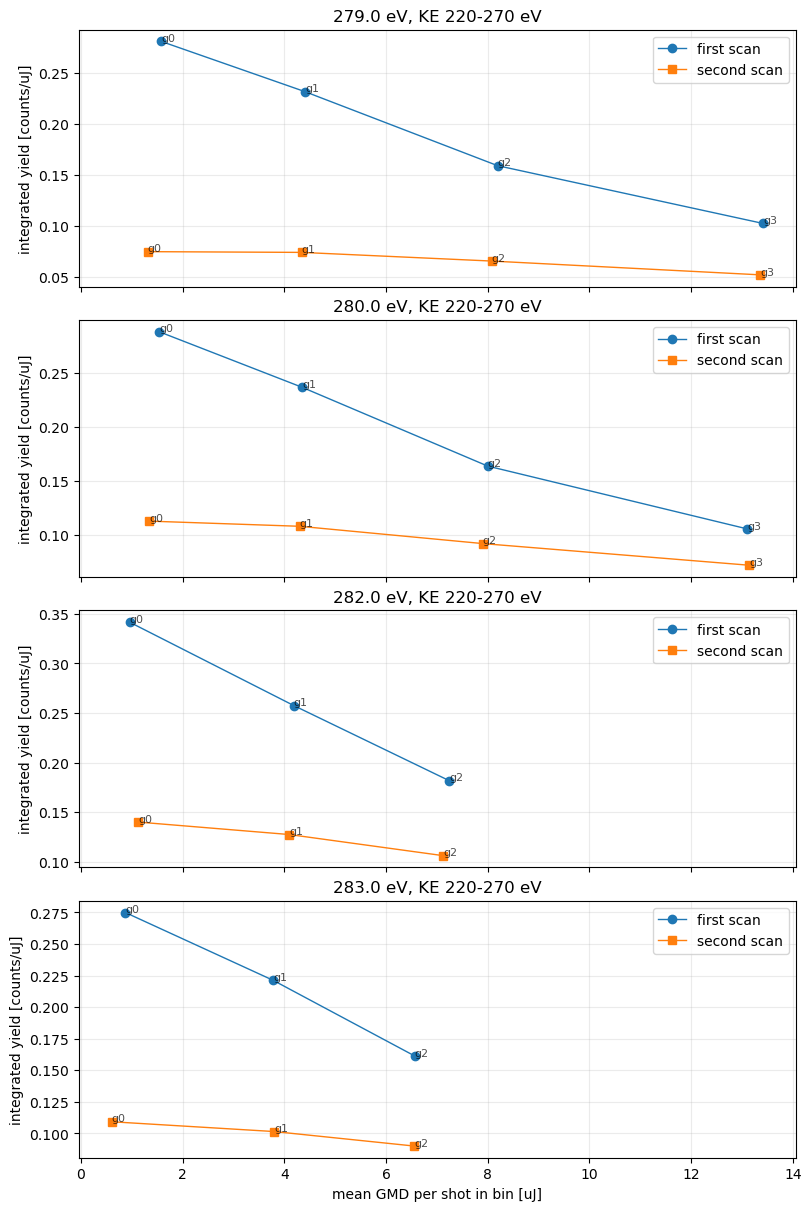

In [68]:
# --- Test 2: GMD-bin linearity / saturation diagnostic ----------------

ENERGIES_FOR_GMD_TEST = [279.0, 280.0, 282.0, 283.0]
KE_YIELD_RANGE = KE_RATIO_RANGE
MIN_SHOTS_PER_GMD_BIN = 100

tof_cent = 0.5 * (tof_edges[:-1] + tof_edges[1:])
ke_cent = tof_to_ke(tof_cent)

ke_mask = (
    np.isfinite(ke_cent)
    & (ke_cent >= KE_YIELD_RANGE[0])
    & (ke_cent <= KE_YIELD_RANGE[1])
)

gmd_cent = 0.5 * (gmd_edges[:-1] + gmd_edges[1:])

fig, axes = plt.subplots(
    len(ENERGIES_FOR_GMD_TEST), 1,
    figsize=(8, 3.0 * len(ENERGIES_FOR_GMD_TEST)),
    sharex=True,
    constrained_layout=True,
)
axes = np.atleast_1d(axes)

for ax, e in zip(axes, ENERGIES_FOR_GMD_TEST):
    for family, label, marker in [
        ("first_decimal_scan", "first scan", "o-"),
        ("second_integer_scan", "second scan", "s-"),
    ]:
        key = (family, float(e))
        if key not in scan_products:
            continue

        prod = scan_products[key]

        per_gmd = prod["per_gmd"]
        n_g = prod["n_shots"]
        total_gmd_g = prod["total_gmd"]

        # Integrated yield per uJ in this KE window, one value per GMD bin.
        yield_per_uJ = np.full(len(gmd_cent), np.nan)
        counts_per_shot = np.full(len(gmd_cent), np.nan)
        mean_gmd_per_shot = np.full(len(gmd_cent), np.nan)

        for g in range(len(gmd_cent)):
            if n_g[g] < MIN_SHOTS_PER_GMD_BIN or total_gmd_g[g] <= 0:
                continue

            # per_gmd is already counts/uJ per TOF bin.
            yield_per_uJ[g] = np.nansum(per_gmd[g, ke_mask])

            # Reconstruct integrated counts, then divide by shots.
            counts_g = yield_per_uJ[g] * total_gmd_g[g]
            counts_per_shot[g] = counts_g / n_g[g]
            mean_gmd_per_shot[g] = total_gmd_g[g] / n_g[g]

        ax.plot(
            mean_gmd_per_shot,
            yield_per_uJ,
            marker,
            lw=1.0,
            label=label,
        )

        for g in range(len(gmd_cent)):
            if np.isfinite(yield_per_uJ[g]):
                ax.text(
                    mean_gmd_per_shot[g],
                    yield_per_uJ[g],
                    f"g{g}",
                    fontsize=8,
                    alpha=0.7,
                )

    ax.set_title(f"{e:.1f} eV, KE {KE_YIELD_RANGE[0]}-{KE_YIELD_RANGE[1]} eV")
    ax.set_ylabel("integrated yield [counts/uJ]")
    ax.grid(alpha=0.25)
    ax.legend()

axes[-1].set_xlabel("mean GMD per shot in bin [uJ]")

plt.show()

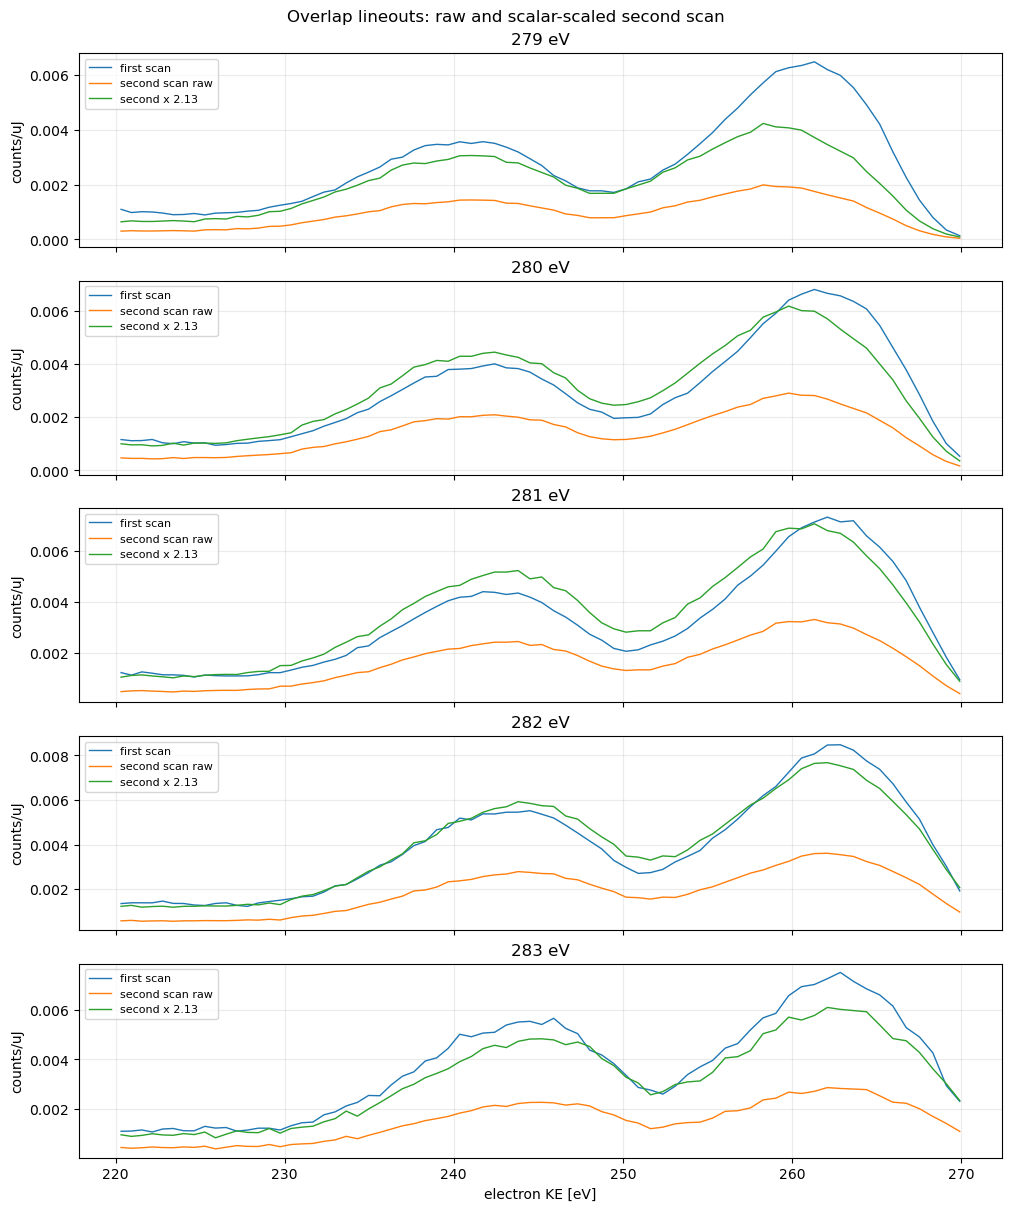

In [69]:
# --- Diagnostic: overlap lineouts before/after scalar scaling ----------

SCALE_SECOND_TO_FIRST = np.nanmedian(ratio_rows[:, 4])
OVERLAP_LINEOUT_RANGE = KE_RATIO_RANGE
SMOOTH_BINS = 1

def _smooth_1d(y, width):
    if width is None or width <= 1:
        return y
    kernel = np.ones(int(width), dtype=float) / float(width)
    return np.convolve(y, kernel, mode="same")

tof_cent = 0.5 * (tof_edges[:-1] + tof_edges[1:])
ke_cent = tof_to_ke(tof_cent)

ke_mask = (
    np.isfinite(ke_cent)
    & (ke_cent >= OVERLAP_LINEOUT_RANGE[0])
    & (ke_cent <= OVERLAP_LINEOUT_RANGE[1])
)

x = ke_cent[ke_mask]
order = np.argsort(x)
x = x[order]

fig, axes = plt.subplots(
    len(overlap_energies), 1,
    figsize=(10, 2.4 * len(overlap_energies)),
    sharex=True,
    constrained_layout=True,
)
axes = np.atleast_1d(axes)

for ax, e in zip(axes, overlap_energies):
    first = scan_products[("first_decimal_scan", float(e))]
    second = scan_products[("second_integer_scan", float(e))]

    y_first = first["total"][ke_mask][order]
    y_second = second["total"][ke_mask][order]
    y_second_scaled = SCALE_SECOND_TO_FIRST * y_second

    y_first = _smooth_1d(y_first, SMOOTH_BINS)
    y_second = _smooth_1d(y_second, SMOOTH_BINS)
    y_second_scaled = _smooth_1d(y_second_scaled, SMOOTH_BINS)

    ax.plot(x, y_first, lw=1.0, label="first scan")
    ax.plot(x, y_second, lw=1.0, label="second scan raw")
    ax.plot(x, y_second_scaled, lw=1.0, label=f"second x {SCALE_SECOND_TO_FIRST:.3g}")

    ax.set_ylabel("counts/uJ")
    ax.set_title(f"{e:.0f} eV")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)

axes[-1].set_xlabel("electron KE [eV]")
fig.suptitle("Overlap lineouts: raw and scalar-scaled second scan")
plt.show()

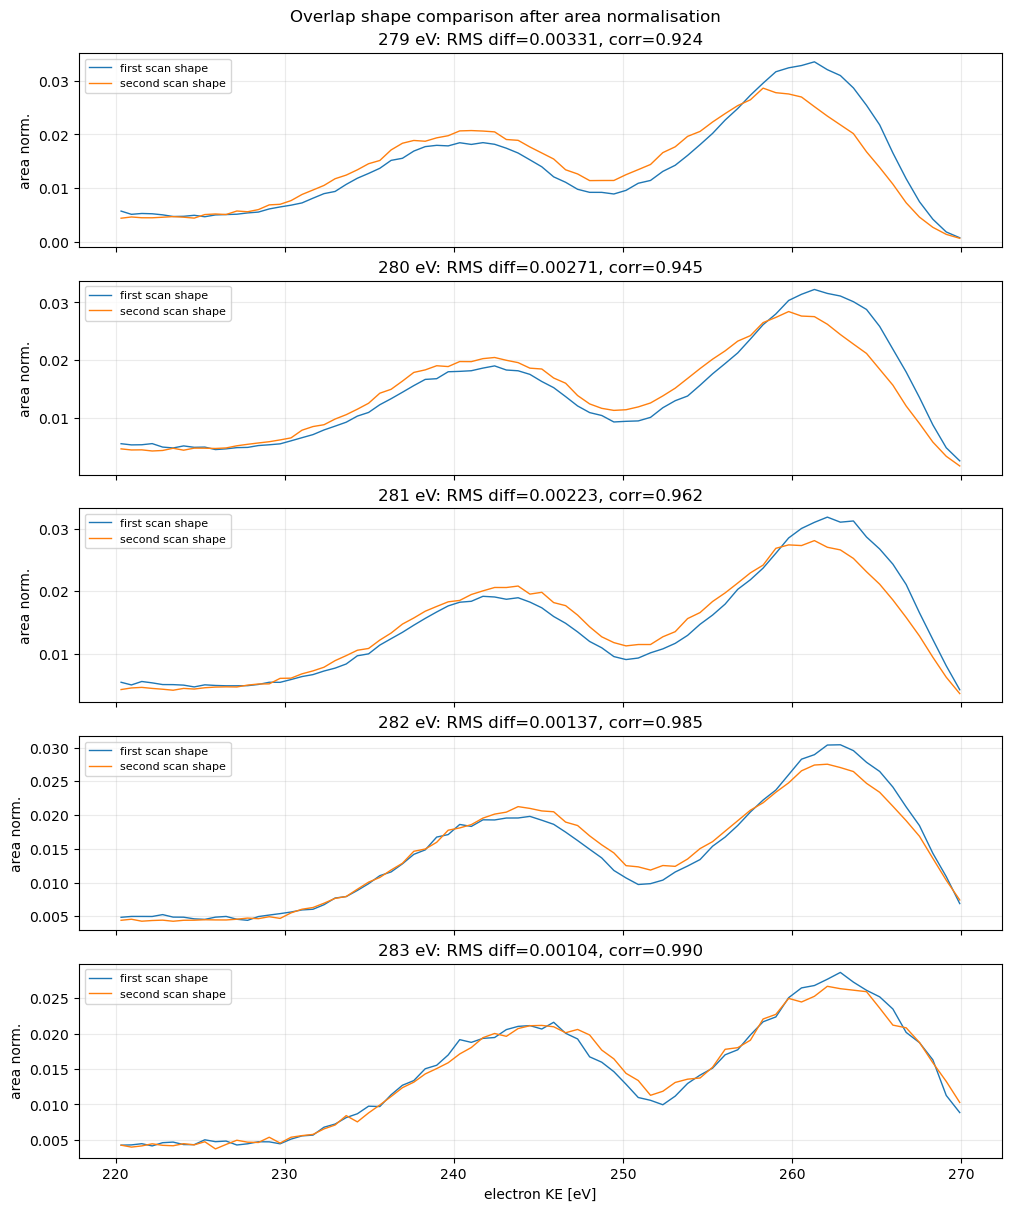

Shape diagnostics:
279.00 eV  RMS shape diff=0.003309  corr=0.9237
280.00 eV  RMS shape diff=0.002709  corr=0.9447
281.00 eV  RMS shape diff=0.002227  corr=0.9617
282.00 eV  RMS shape diff=0.001369  corr=0.9846
283.00 eV  RMS shape diff=0.001043  corr=0.9905


In [70]:
# --- Diagnostic: area-normalised spectral shape comparison ------------

fig, axes = plt.subplots(
    len(overlap_energies), 1,
    figsize=(10, 2.4 * len(overlap_energies)),
    sharex=True,
    constrained_layout=True,
)
axes = np.atleast_1d(axes)

shape_dist_rows = []

for ax, e in zip(axes, overlap_energies):
    first = scan_products[("first_decimal_scan", float(e))]
    second = scan_products[("second_integer_scan", float(e))]

    y1 = first["total"][ke_mask][order].astype(float)
    y2 = second["total"][ke_mask][order].astype(float)

    a1 = np.nansum(y1)
    a2 = np.nansum(y2)

    y1n = y1 / a1 if a1 > 0 else np.full_like(y1, np.nan)
    y2n = y2 / a2 if a2 > 0 else np.full_like(y2, np.nan)

    diff = y2n - y1n
    rms = np.sqrt(np.nanmean(diff**2))
    corr = np.corrcoef(
        np.nan_to_num(y1n, nan=0.0),
        np.nan_to_num(y2n, nan=0.0),
    )[0, 1]

    shape_dist_rows.append((e, rms, corr))

    ax.plot(x, y1n, lw=1.0, label="first scan shape")
    ax.plot(x, y2n, lw=1.0, label="second scan shape")
    ax.set_ylabel("area norm.")
    ax.set_title(f"{e:.0f} eV: RMS diff={rms:.3g}, corr={corr:.3f}")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)

axes[-1].set_xlabel("electron KE [eV]")
fig.suptitle("Overlap shape comparison after area normalisation")
plt.show()

print("Shape diagnostics:")
for e, rms, corr in shape_dist_rows:
    print(f"{e:6.2f} eV  RMS shape diff={rms:.4g}  corr={corr:.4f}")

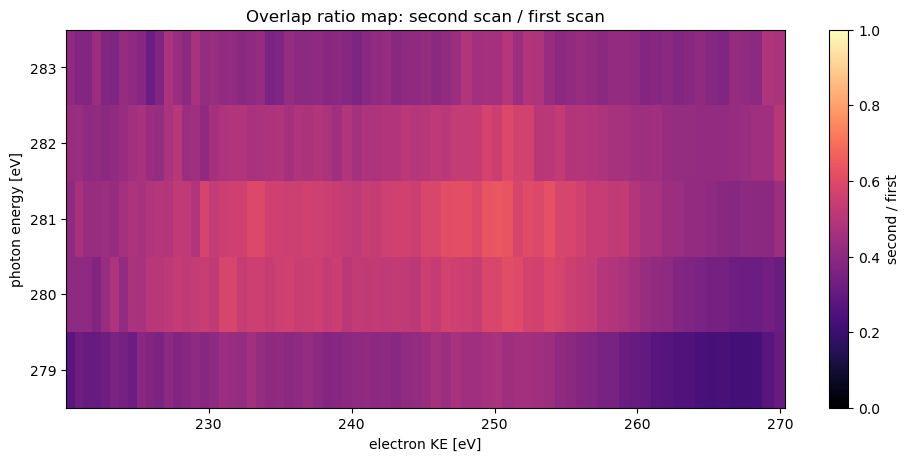

In [71]:
# --- Diagnostic: second/first ratio as energy x KE heatmap ------------

ratio_map = []

for e in overlap_energies:
    first = scan_products[("first_decimal_scan", float(e))]
    second = scan_products[("second_integer_scan", float(e))]

    y1 = first["total"][ke_mask][order]
    y2 = second["total"][ke_mask][order]

    with np.errstate(invalid="ignore", divide="ignore"):
        r = y2 / y1

    ratio_map.append(r)

ratio_map = np.asarray(ratio_map)

# Clip only for visual readability.
RATIO_VMIN = 0.0
RATIO_VMAX = 1.0

fig, ax = plt.subplots(figsize=(9, 4.5), constrained_layout=True)

x_edges = _energy_edges(x)
e_edges_overlap = _energy_edges(overlap_energies)

pcm = ax.pcolormesh(
    x_edges,
    e_edges_overlap,
    ratio_map,
    shading="auto",
    cmap="magma",
    vmin=RATIO_VMIN,
    vmax=RATIO_VMAX,
)

fig.colorbar(pcm, ax=ax, label="second / first")
ax.set_xlabel("electron KE [eV]")
ax.set_ylabel("photon energy [eV]")
ax.set_title("Overlap ratio map: second scan / first scan")

plt.show()

In [72]:
# --- Compact scalar-stitching summary --------------------------------

ratios = ratio_rows[:, 3]
ratio_median = np.nanmedian(ratios)
ratio_rel_scatter = np.nanstd(ratios) / ratio_median

print(f"Overlap second/first median ratio : {ratio_median:.4g}")
print(f"Relative scatter across energies  : {100 * ratio_rel_scatter:.1f}%")
print(f"Scale second -> first             : {1 / ratio_median:.4g}")

if ratio_rel_scatter < 0.10:
    print("Interpretation: overlap is fairly flat; scalar scaling is plausible.")
elif ratio_rel_scatter < 0.25:
    print("Interpretation: scalar scaling may be OK for visual comparison, but is not fully rigorous.")
else:
    print("Interpretation: overlap varies strongly; avoid scalar stitching as a quantitative result.")

Overlap second/first median ratio : 0.4704
Relative scatter across energies  : 11.8%
Scale second -> first             : 2.126
Interpretation: scalar scaling may be OK for visual comparison, but is not fully rigorous.


In [73]:
# --- Build scaled stitched map: first scan + scaled second scan --------

SCALE_SECOND_TO_FIRST = np.nanmedian(ratio_rows[:, 4])
OVERLAP_POLICY = "gmd_weighted_mean"
# Options:
#   "gmd_weighted_mean" : combine first + scaled second at duplicate energies
#   "first_only"        : keep first scan where both exist
#   "second_scaled_only": use scaled second scan where both exist

combined_energy_dict = {}

def _total_gmd_exposure(prod):
    return float(np.nansum(prod["total_gmd"]))


# Add first scan without scaling.
for e in first_energies:
    prod = scan_products[("first_decimal_scan", float(e))]
    combined_energy_dict.setdefault(float(e), []).append({
        "label": "first",
        "spectrum": prod["total"],
        "weight": _total_gmd_exposure(prod),
        "path": prod["path"],
    })


# Add second scan after scaling.
for e in second_energies:
    prod = scan_products[("second_integer_scan", float(e))]
    combined_energy_dict.setdefault(float(e), []).append({
        "label": "second_scaled",
        "spectrum": SCALE_SECOND_TO_FIRST * prod["total"],
        "weight": _total_gmd_exposure(prod),
        "path": prod["path"],
    })


combined_energies = np.array(sorted(combined_energy_dict), dtype=float)
combined_scaled_stack = np.full((len(combined_energies), len(tof_edges) - 1), np.nan)

combined_sources = []

for i, e in enumerate(combined_energies):
    rows = combined_energy_dict[float(e)]

    labels = [r["label"] for r in rows]
    spectra = np.asarray([r["spectrum"] for r in rows], dtype=float)
    weights = np.asarray([r["weight"] for r in rows], dtype=float)

    if len(rows) == 1:
        combined_scaled_stack[i] = spectra[0]
        combined_sources.append(labels[0])
        continue

    if OVERLAP_POLICY == "first_only":
        j = labels.index("first")
        combined_scaled_stack[i] = spectra[j]
        combined_sources.append("first_only_overlap")

    elif OVERLAP_POLICY == "second_scaled_only":
        j = labels.index("second_scaled")
        combined_scaled_stack[i] = spectra[j]
        combined_sources.append("second_scaled_only_overlap")

    elif OVERLAP_POLICY == "gmd_weighted_mean":
        valid = np.isfinite(spectra).any(axis=1) & np.isfinite(weights) & (weights > 0)
        combined_scaled_stack[i] = np.average(spectra[valid], axis=0, weights=weights[valid])
        combined_sources.append("first_plus_scaled_second")

    else:
        raise ValueError(f"unknown OVERLAP_POLICY={OVERLAP_POLICY!r}")


print(f"Scale second -> first: {SCALE_SECOND_TO_FIRST:.4g}")
print(f"Overlap policy       : {OVERLAP_POLICY}")
print("Combined energies:")
for e, src in zip(combined_energies, combined_sources):
    print(f"  {e:6.2f} eV  {src}")

Scale second -> first: 2.126
Overlap policy       : gmd_weighted_mean
Combined energies:
  270.00 eV  first
  270.50 eV  first
  271.00 eV  first
  271.50 eV  first
  272.00 eV  first
  272.50 eV  first
  273.00 eV  first
  273.50 eV  first
  274.00 eV  first
  274.50 eV  first
  275.00 eV  first
  275.50 eV  first
  276.00 eV  first
  276.50 eV  first
  277.00 eV  first
  277.50 eV  first
  278.00 eV  first
  278.50 eV  first
  279.00 eV  first_plus_scaled_second
  279.50 eV  first
  280.00 eV  first_plus_scaled_second
  280.50 eV  first
  281.00 eV  first_plus_scaled_second
  281.50 eV  first
  282.00 eV  first_plus_scaled_second
  282.50 eV  first
  283.00 eV  first_plus_scaled_second
  284.00 eV  second_scaled
  285.00 eV  second_scaled
  286.00 eV  second_scaled
  287.00 eV  second_scaled
  288.00 eV  second_scaled


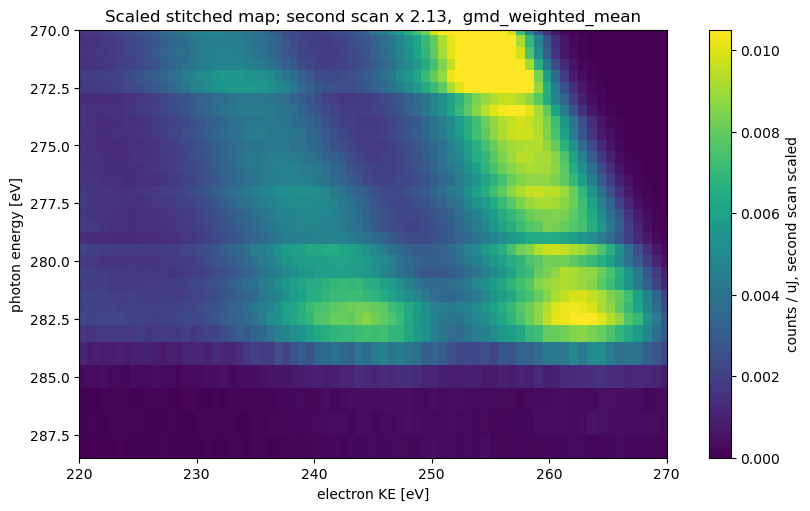

In [77]:
# --- Plot scaled stitched 2D map --------------------------------------

TOF_RANGE = (800, 1100)
USE_KE_AXIS = True
VMIN, VMAX = None, None

def _energy_edges_local(e):
    e = np.asarray(e, dtype=float)
    if len(e) == 1:
        return np.array([e[0] - 0.5, e[0] + 0.5])
    mid = 0.5 * (e[:-1] + e[1:])
    return np.concatenate([[2 * e[0] - mid[0]], mid, [2 * e[-1] - mid[-1]]])


def _robust_limits_local(arr, p_lo=1, p_hi=99.5):
    finite = arr[np.isfinite(arr)]
    if finite.size == 0:
        return 0.0, 1.0
    return float(np.nanpercentile(finite, p_lo)), float(np.nanpercentile(finite, p_hi))


e_edges = _energy_edges_local(combined_energies)

if USE_KE_AXIS:
    x_edges, map_to_plot = _tof_window_to_ke_edges_and_data(
        tof_edges,
        combined_scaled_stack,
        TOF_RANGE,
    )
    xlabel = "electron KE [eV]"
else:
    tof_cent = 0.5 * (tof_edges[:-1] + tof_edges[1:])
    mask = np.ones_like(tof_cent, dtype=bool)
    if TOF_RANGE[0] is not None:
        mask &= tof_cent >= TOF_RANGE[0]
    if TOF_RANGE[1] is not None:
        mask &= tof_cent <= TOF_RANGE[1]

    idx = np.where(mask)[0]
    lo = int(idx[0])
    hi = int(idx[-1]) + 1

    x_edges = tof_edges[lo:hi + 1]
    map_to_plot = combined_scaled_stack[:, lo:hi]
    xlabel = "eTOF [100 ps ticks]"

vmin_auto, vmax_auto = _robust_limits_local(map_to_plot)
vmin = vmin_auto if VMIN is None else VMIN
vmax = vmax_auto if VMAX is None else VMAX

fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

pcm = ax.pcolormesh(
    x_edges,
    e_edges,
    map_to_plot,
    shading="auto",
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
)

fig.colorbar(pcm, ax=ax, label="counts / uJ, second scan scaled")
ax.set_xlabel(xlabel)
ax.set_ylabel("photon energy [eV]")
ax.set_title(
    f"Scaled stitched map; second scan x {SCALE_SECOND_TO_FIRST:.3g}, "
    f" {OVERLAP_POLICY}"
)

ax.set_ylim(288.5,270)
if USE_KE_AXIS:
    ax.set_xlim(220, 270)

plt.show()

## Subtraction

### Second scan inspection and functions

In [28]:
# --- Load eTOF -> KE calibration ------------------------------------

from pathlib import Path
import json
import numpy as np

CALIB_PATH = Path(config.COMBINED_DIR).parent / "Calibrations" / "etof_energy_calibration_t0_scan.json"

with open(CALIB_PATH, "r", encoding="utf-8") as fh:
    calib = json.load(fh)

best_t0 = calib["t0_tof_units"]
best_slope = calib["slope_eV_tof_unit2"]
best_E0 = calib["E0_eV"]

def KE_from_TOF(t):
    t = np.asarray(t, dtype=float)
    with np.errstate(divide="ignore", invalid="ignore"):
        ke = best_slope / (t - best_t0)**2 + best_E0
    return np.where(t > best_t0, ke, np.nan)

tof_to_ke = KE_from_TOF

print("Loaded eTOF calibration:")
print(f"  path  = {CALIB_PATH}")
print(f"  t0    = {best_t0:.6f} TOF units")
print(f"  slope = {best_slope:.6e} eV * TOF_unit^2")
print(f"  E0    = {best_E0:.6f} eV")

if "effective_length_mm" in calib:
    print(f"  L     = {calib['effective_length_mm']:.2f} mm")

if "fit_quality" in calib:
    print(f"  RMSE  = {calib['fit_quality'].get('rmse_eV', np.nan):.4f} eV")
    print(f"  R²    = {calib['fit_quality'].get('r2', np.nan):.8f}")

Loaded eTOF calibration:
  path  = /asap3/flash/gpfs/fl24/2026/data/11022188/processed/Calibrations/etof_energy_calibration_t0_scan.json
  t0    = 70.317117 TOF units
  slope = 1.726561e+08 eV * TOF_unit^2
  E0    = -32.015747 eV
  L     = 779.32 mm
  RMSE  = 1.1566 eV
  R²    = 0.99982907


In [29]:
# --- Helpers for plotting TOF-binned maps on calibrated KE axis -------

def _tof_window_to_ke_edges_and_data(tof_edges, data, tof_range):
    """
    Slice TOF-binned data to a TOF window, convert bin edges to KE,
    and reverse columns so KE increases left-to-right.
    """
    tof_cent = 0.5 * (tof_edges[:-1] + tof_edges[1:])

    mask = np.ones_like(tof_cent, dtype=bool)
    if tof_range[0] is not None:
        mask &= tof_cent >= tof_range[0]
    if tof_range[1] is not None:
        mask &= tof_cent <= tof_range[1]

    idx = np.where(mask)[0]
    if idx.size == 0:
        raise ValueError(f"No TOF bins inside range {tof_range}")

    lo = int(idx[0])
    hi = int(idx[-1]) + 1

    data_s = data[..., lo:hi]
    ke_edges = tof_to_ke(tof_edges[lo:hi + 1])

    good_edges = np.isfinite(ke_edges)
    if not np.all(good_edges):
        raise ValueError(
            "Some KE edges are NaN. Choose a TOF range fully above t0."
        )

    # Convert counts per TOF bin to counts per eV.
    # Must be done before/after reversing consistently with ke_edges.
    ke_widths = np.abs(np.diff(ke_edges))

    with np.errstate(invalid="ignore", divide="ignore"):
        data_s = data_s / ke_widths

    # TOF increases while KE usually decreases, so reverse to increasing KE.
    if ke_edges[0] > ke_edges[-1]:
        ke_edges = ke_edges[::-1]
        data_s = data_s[..., ::-1]

    return ke_edges, data_s


def _tof_lineout_to_ke(tof_cent, y, tof_range):
    mask = np.ones_like(tof_cent, dtype=bool)
    if tof_range[0] is not None:
        mask &= tof_cent >= tof_range[0]
    if tof_range[1] is not None:
        mask &= tof_cent <= tof_range[1]

    ke = tof_to_ke(tof_cent[mask])
    yy = y[mask]

    good = np.isfinite(ke)
    ke = ke[good]
    yy = yy[good]

    order = np.argsort(ke)
    return ke[order], yy[order]

In [30]:
# --- Match residual-gas background to signal energy/GMD/TOF grid -----

BG_SCALE = 1.0
ENERGY_TOL = 1e-6

if not np.array_equal(tof_edges, bg_agg_tof_edges):
    raise ValueError("Signal and background TOF edges do not match.")

if not np.array_equal(gmd_edges, bg_agg_gmd_edges):
    raise ValueError("Signal and background GMD edges do not match.")

bg_on_signal = np.full_like(stack, np.nan, dtype=np.float64)
has_background = np.zeros(len(energies), dtype=bool)
bg_match_index = np.full(len(energies), -1, dtype=int)

for i, e in enumerate(energies):
    matches = np.where(np.isclose(bg_agg_energies, e, atol=ENERGY_TOL))[0]
    if len(matches) == 0:
        continue
    j = int(matches[0])
    bg_on_signal[i] = bg_agg_stack[j]
    has_background[i] = True
    bg_match_index[i] = j

# Partial subtraction:
# where background exists -> signal - scaled background
# where background does not exist -> keep raw signal unchanged
stack_bgsub_partial = stack.copy()
stack_bgsub_partial[has_background] = (
    stack[has_background] - BG_SCALE * bg_on_signal[has_background]
)

print("Signal energies:")
print(energies)
print("Background energies:")
print(bg_agg_energies)
print("Matched energies:")
for i, ok in enumerate(has_background):
    if ok:
        print(f"  {energies[i]:7.2f} eV  signal row {i} <- background row {bg_match_index[i]}")
print("No measured background for:")
print(energies[~has_background])

Signal energies:
[270.  270.5 271.  271.5 272.  272.5 273.  273.5 274.  274.5 275.  275.5
 276.  276.5 277.  277.5 278.  278.5 279.  279.5 280.  280.5 281.  281.5
 282.  282.5 283.  284.  285.  286.  287.  288. ]
Background energies:
[271.  271.5 272.  272.5 273.  273.5 274.  274.5 275. ]
Matched energies:
   271.00 eV  signal row 2 <- background row 0
   271.50 eV  signal row 3 <- background row 1
   272.00 eV  signal row 4 <- background row 2
   272.50 eV  signal row 5 <- background row 3
   273.00 eV  signal row 6 <- background row 4
   273.50 eV  signal row 7 <- background row 5
   274.00 eV  signal row 8 <- background row 6
   274.50 eV  signal row 9 <- background row 7
   275.00 eV  signal row 10 <- background row 8
No measured background for:
[270.  270.5 275.5 276.  276.5 277.  277.5 278.  278.5 279.  279.5 280.
 280.5 281.  281.5 282.  282.5 283.  284.  285.  286.  287.  288. ]


In [37]:
# --- 2D map for the integer-energy / higher-energy scan only ----------
# Uses all-GMD-combined spectra for files named like 279eV, 280eV, ...

INTEGER_SCAN_MIN_E = 279.0
TOF_RANGE = (800, 1100)       # set to (None, None) for full TOF
USE_KE_AXIS = True            # requires tof_to_ke if True
VMIN, VMAX = None, None       # set manually if desired, e.g. 0, 0.01

# Find integer-energy files: glycine_WL_scan_279eV_aggregates_etof1.h5
integer_file_rows = []
for p, e in FILES:
    stem = Path(p).stem
    m = re.search(r"_scan_(\d+)eV_aggregates_etof1$", stem)
    if m and e >= INTEGER_SCAN_MIN_E:
        integer_file_rows.append((Path(p), float(e)))

integer_file_rows = sorted(integer_file_rows, key=lambda pe: pe[1])

if not integer_file_rows:
    raise RuntimeError("No integer-energy scan files found in FILES.")

integer_energies = np.array([e for _, e in integer_file_rows], dtype=float)

integer_stack = None
integer_tof_edges = None
integer_gmd_edges = None
integer_n_shots = None
integer_total_gmd = None

for k, (path, e) in enumerate(integer_file_rows):
    agg = load_aggregates(path)

    if agg.config != 1:
        raise ValueError(f"{path.name}: config={agg.config}, expected 1")
    if agg.mode != "spectral":
        raise ValueError(f"{path.name}: mode={agg.mode!r}, expected 'spectral'")

    if integer_tof_edges is None:
        integer_tof_edges = agg.tof_edges
        integer_gmd_edges = agg.gmd_edges

        n_E = len(integer_file_rows)
        n_gmd = agg.n_gmd_bins
        n_tof = agg.n_tof

        integer_stack = np.full((n_E, n_tof), np.nan, dtype=float)
        integer_n_shots = np.zeros((n_E, n_gmd), dtype=np.int64)
        integer_total_gmd = np.zeros((n_E, n_gmd), dtype=float)
    else:
        if not np.array_equal(agg.tof_edges, integer_tof_edges):
            raise ValueError(f"{path.name}: tof_edges mismatch")
        if not np.array_equal(agg.gmd_edges, integer_gmd_edges):
            raise ValueError(f"{path.name}: gmd_edges mismatch")

    n = np.asarray(agg.n_per_bin, dtype=float)
    total_gmd_g = np.asarray(agg.G, dtype=float) * n

    with np.errstate(invalid="ignore", divide="ignore"):
        per_gmd_bin = agg.D / agg.G[:, None]

    valid = np.isfinite(per_gmd_bin).any(axis=1) & (total_gmd_g > 0)

    if valid.any():
        # all-GMD combined spectrum:
        # sum(counts per TOF bin over GMD bins) / sum(GMD over GMD bins)
        integer_stack[k] = np.average(
            per_gmd_bin[valid],
            axis=0,
            weights=total_gmd_g[valid],
        )

    integer_n_shots[k] = np.asarray(agg.n_per_bin, dtype=np.int64)
    integer_total_gmd[k] = total_gmd_g

print("Integer scan energies:", integer_energies)
print("integer_stack:", integer_stack.shape)


# --- Plot -------------------------------------------------------------

def _energy_edges(e):
    e = np.asarray(e, dtype=float)
    if len(e) == 1:
        return np.array([e[0] - 0.5, e[0] + 0.5])
    mid = 0.5 * (e[:-1] + e[1:])
    return np.concatenate([[2 * e[0] - mid[0]], mid, [2 * e[-1] - mid[-1]]])


def _robust_limits(arr, p_lo=1, p_hi=99.5):
    finite = arr[np.isfinite(arr)]
    if finite.size == 0:
        return 0.0, 1.0
    return float(np.nanpercentile(finite, p_lo)), float(np.nanpercentile(finite, p_hi))


e_edges = _energy_edges(integer_energies)

if USE_KE_AXIS:
    ke_edges, integer_stack_plot = _tof_window_to_ke_edges_and_data(
        integer_tof_edges,
        integer_stack,
        TOF_RANGE,
    )
    x_edges = ke_edges
    xlabel = "electron KE [eV]"
else:
    tof_cent = 0.5 * (integer_tof_edges[:-1] + integer_tof_edges[1:])
    mask = np.ones_like(tof_cent, dtype=bool)
    if TOF_RANGE[0] is not None:
        mask &= tof_cent >= TOF_RANGE[0]
    if TOF_RANGE[1] is not None:
        mask &= tof_cent <= TOF_RANGE[1]

    idx = np.where(mask)[0]
    if idx.size == 0:
        raise ValueError(f"No TOF bins inside range {TOF_RANGE}")

    lo = int(idx[0])
    hi = int(idx[-1]) + 1

    x_edges = integer_tof_edges[lo:hi + 1]
    integer_stack_plot = integer_stack[:, lo:hi]
    xlabel = "eTOF [100 ps ticks]"



Integer scan energies: [279. 280. 281. 282. 283. 284. 285. 286. 287. 288.]
integer_stack: (10, 5000)


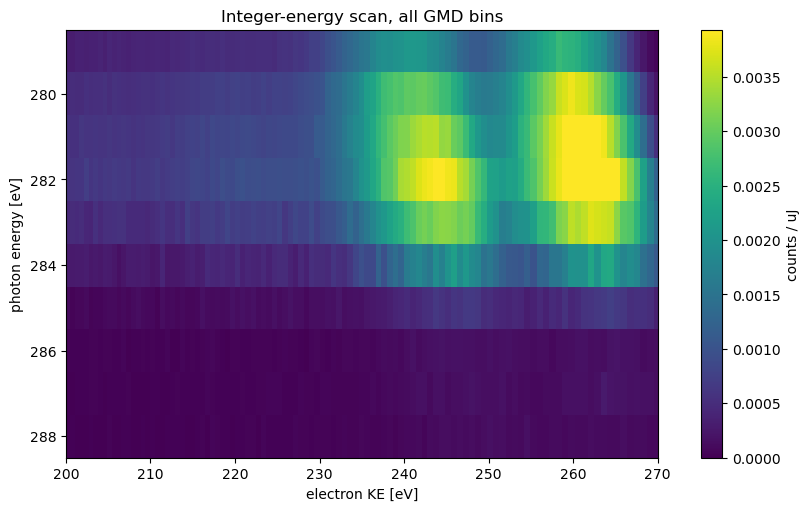

In [42]:
vmin_auto, vmax_auto = _robust_limits(integer_stack_plot)
vmin = vmin_auto if VMIN is None else VMIN
vmax = vmax_auto if VMAX is None else VMAX

fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

pcm = ax.pcolormesh(
    x_edges,
    e_edges,
    integer_stack_plot,
    shading="auto",
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
)

fig.colorbar(pcm, ax=ax, label="counts / uJ")
ax.set_xlabel(xlabel)
ax.set_ylabel("photon energy [eV]")
ax.set_title("Integer-energy scan, all GMD bins")
ax.set_ylim(288.5,278.5)

if USE_KE_AXIS:
    ax.set_xlim(200, 270)

plt.show()

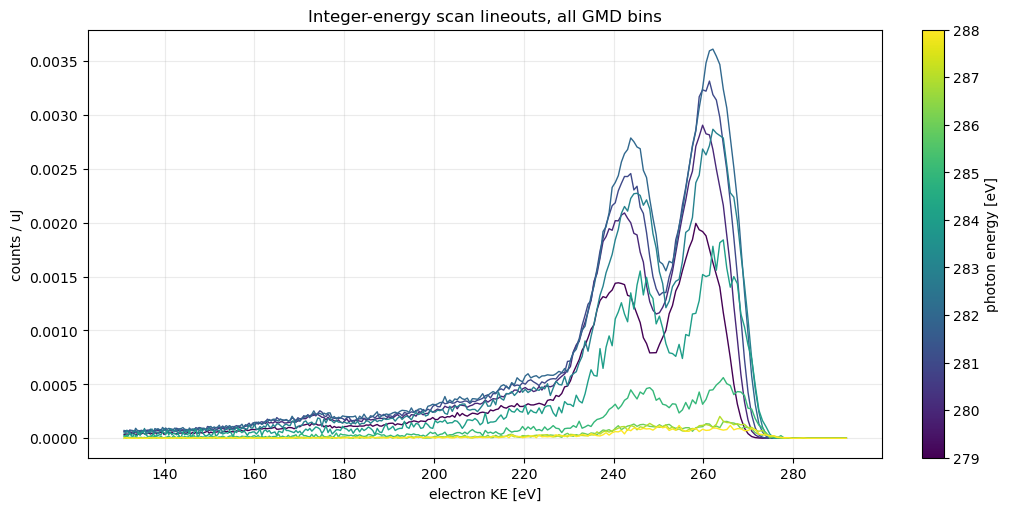

In [53]:
# --- Lineouts from the integer-scan 2D map ----------------------------
# Uses integer_stack from the previous cell.
# Assumes _tof_lineout_to_ke and tof_to_ke are already defined.

ENERGIES_TO_PLOT = None        # None = all integer-scan energies
TOF_LINEOUT_RANGE = (800, 1100)
NORMALISE_AREA = False         # True = compare shapes only
SMOOTH_BINS = 1                # e.g. 5 for light visual smoothing

def _smooth_1d(y, width):
    if width is None or width <= 1:
        return y
    kernel = np.ones(int(width), dtype=float) / float(width)
    return np.convolve(y, kernel, mode="same")


tof_cent = 0.5 * (integer_tof_edges[:-1] + integer_tof_edges[1:])

if ENERGIES_TO_PLOT is None:
    plot_idx = np.arange(len(integer_energies))
else:
    plot_idx = []
    for e_target in ENERGIES_TO_PLOT:
        idx = np.where(np.isclose(integer_energies, e_target))[0]
        if len(idx) == 0:
            i = int(np.argmin(np.abs(integer_energies - e_target)))
            print(f"warning: requested {e_target} eV, using nearest {integer_energies[i]} eV")
        else:
            i = int(idx[0])
        plot_idx.append(i)
    plot_idx = np.array(plot_idx, dtype=int)


fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)

cmap = plt.get_cmap("viridis")
norm = plt.Normalize(
    vmin=np.nanmin(integer_energies[plot_idx]),
    vmax=np.nanmax(integer_energies[plot_idx]),
)

for i in plot_idx:
    ke, y = _tof_lineout_to_ke(
        tof_cent,
        integer_stack[i, :],
        TOF_LINEOUT_RANGE,
    )

    y = _smooth_1d(y, SMOOTH_BINS)

    if NORMALISE_AREA:
        area = np.nansum(y)
        if area > 0:
            y = y / area

    ax.plot(
        ke,
        y,
        lw=1.0,
        color=cmap(norm(integer_energies[i])),
        label=f"{integer_energies[i]:.0f} eV",
    )

sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("photon energy [eV]")

ax.set_xlabel("electron KE [eV]")
ax.set_ylabel("counts / uJ" if not NORMALISE_AREA else "area-normalised intensity")
ax.set_title("Integer-energy scan lineouts, all GMD bins")
ax.grid(alpha=0.25)

# Optional, can get crowded:
# ax.legend(ncol=2, fontsize=8)

plt.show()

### Plots of the loaded runs

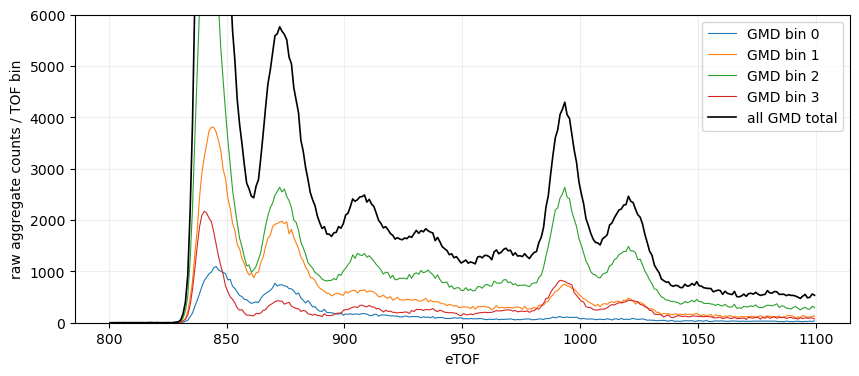

In [65]:
E_TO_PLOT = 274.0
i = int(np.argmin(np.abs(energies - E_TO_PLOT)))
p, e = FILES[i]
agg = load_aggregates(p)

tof_cent = 0.5 * (agg.tof_edges[:-1] + agg.tof_edges[1:])
mask = (tof_cent >= 800) & (tof_cent <= 1100)

fig, ax = plt.subplots(figsize=(10, 4))

for g in range(agg.n_gmd_bins):
    counts_g = agg.D[g] * agg.n_per_bin[g]
    ax.plot(tof_cent[mask], counts_g[mask], lw=0.8, label=f"GMD bin {g}")

counts_total = np.nansum(agg.D * agg.n_per_bin[:, None], axis=0)
ax.plot(tof_cent[mask], counts_total[mask], lw=1.2, color="k", label="all GMD total")

ax.set_xlabel("eTOF")
ax.set_ylabel("raw aggregate counts / TOF bin")
ax.grid(alpha=0.2)
ax.set_ylim(0,6000)
ax.legend()
plt.show()

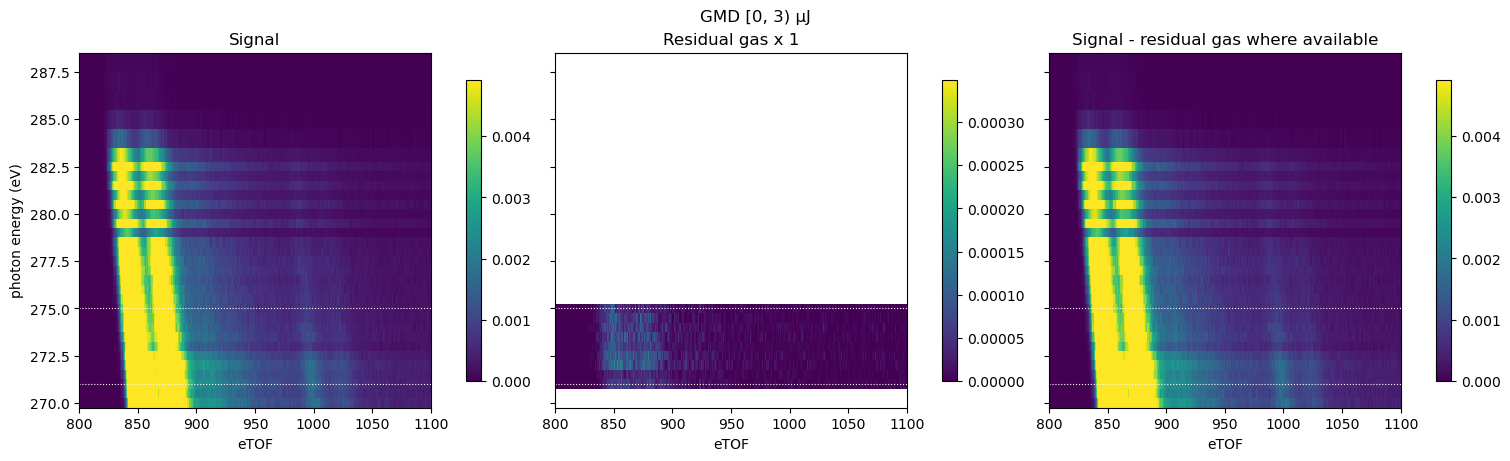

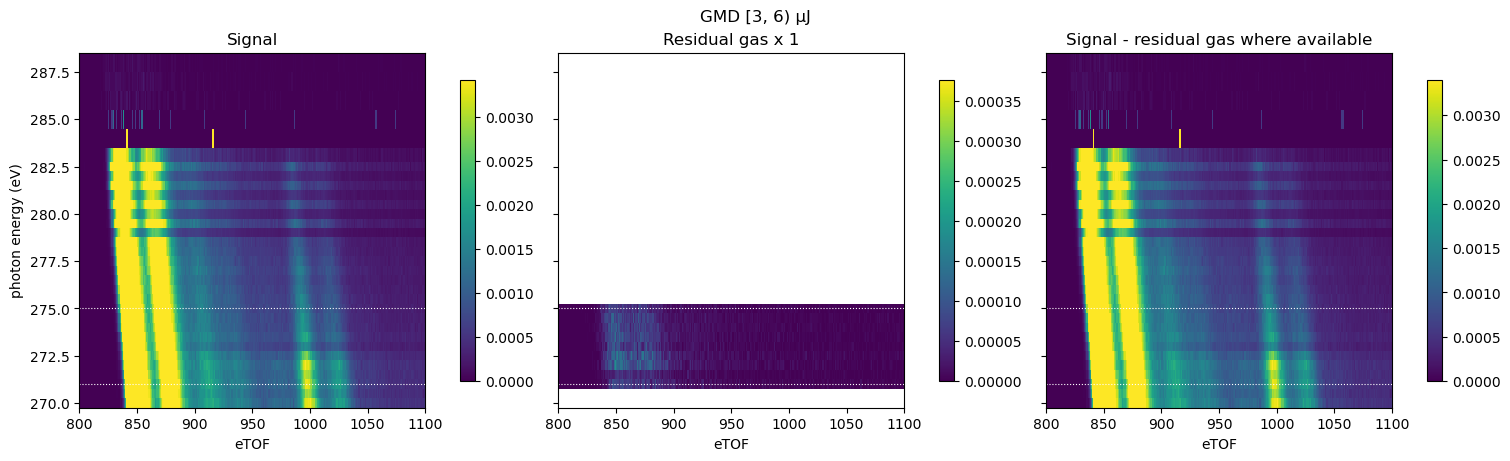

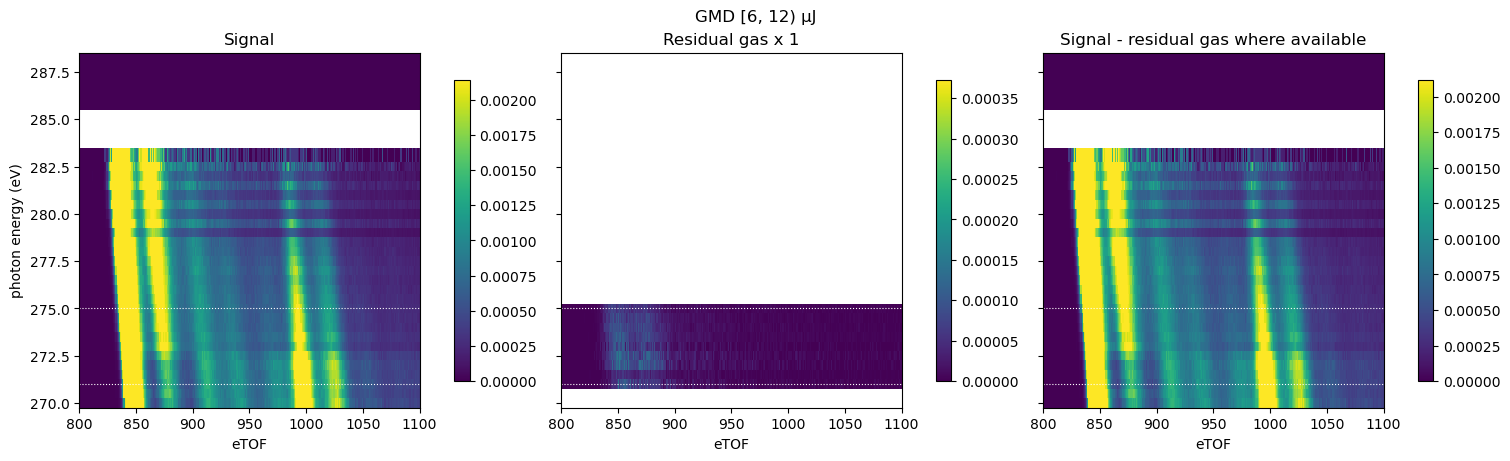

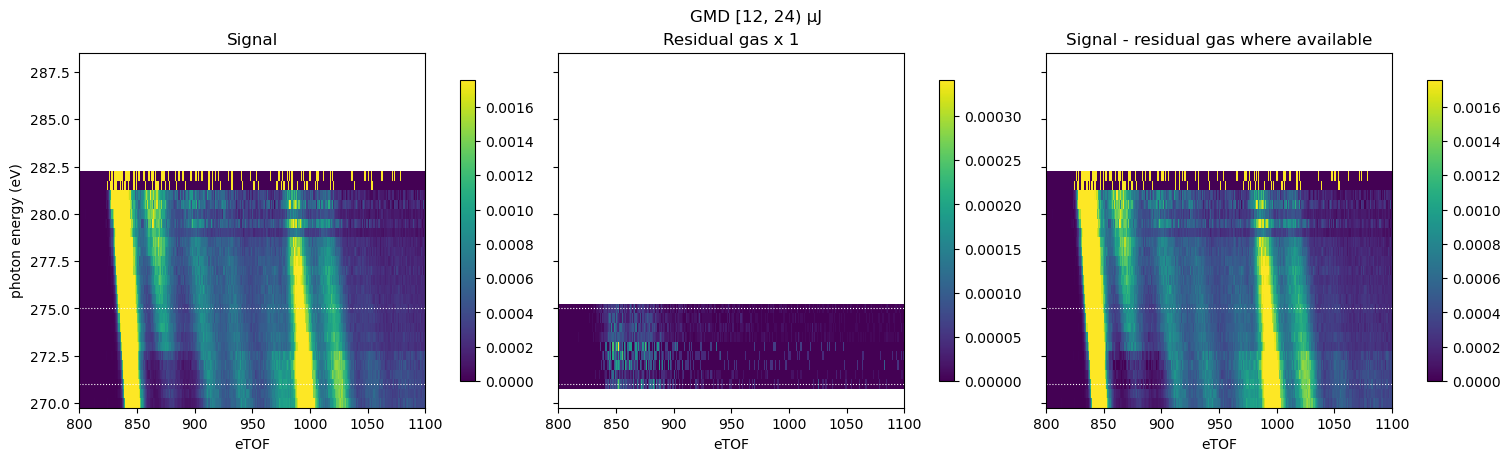

In [54]:
# --- Plot raw signal, matched background, and partial subtraction -----

TOF_RANGE = (800, 1100)

def _energy_edges(e):
    e = np.asarray(e, dtype=np.float64)
    if len(e) == 1:
        return np.array([e[0] - 0.25, e[0] + 0.25])
    mid = 0.5 * (e[:-1] + e[1:])
    return np.concatenate([[2 * e[0] - mid[0]], mid, [2 * e[-1] - mid[-1]]])

def _robust_limits(arr, p_lo=1, p_hi=99.5):
    finite = arr[np.isfinite(arr)]
    if finite.size == 0:
        return 0.0, 1.0
    return float(np.nanpercentile(finite, p_lo)), float(np.nanpercentile(finite, p_hi))

e_edges = _energy_edges(energies)

for g in range(len(gmd_edges) - 1):
    raw = stack[:, g, :]
    bg = bg_on_signal[:, g, :]
    sub = stack_bgsub_partial[:, g, :]

    raw_vmin, raw_vmax = _robust_limits(raw)
    bg_vmin, bg_vmax = _robust_limits(bg)
    sub_vmin, sub_vmax = _robust_limits(sub)

    fig, axes = plt.subplots(
        1, 3, figsize=(15, 4.5), sharey=True, constrained_layout=True
    )

    panels = [
        (raw, raw_vmin, raw_vmax, "Signal"),
        (bg, bg_vmin, bg_vmax, f"Residual gas x {BG_SCALE:g}"),
        (sub, sub_vmin, sub_vmax, "Signal - residual gas where available"),
    ]

    for ax, (data, vmin, vmax, title) in zip(axes, panels):
        pcm = ax.pcolormesh(
            tof_edges,
            e_edges,
            data,
            shading="auto",
            cmap="viridis",
            vmin=vmin,
            vmax=vmax,
        )
        ax.set_title(title)
        ax.set_xlabel("eTOF")
        ax.set_xlim(*TOF_RANGE)
        fig.colorbar(pcm, ax=ax, shrink=0.85)

        # Mark boundary of measured background region.
        if has_background.any():
            ax.axhline(np.nanmin(energies[has_background]), color="w", ls=":", lw=0.8)
            ax.axhline(np.nanmax(energies[has_background]), color="w", ls=":", lw=0.8)

    axes[0].set_ylabel("photon energy (eV)")
    fig.suptitle(f"GMD [{gmd_edges[g]:.2g}, {gmd_edges[g+1]:.2g}) µJ")
    plt.show()

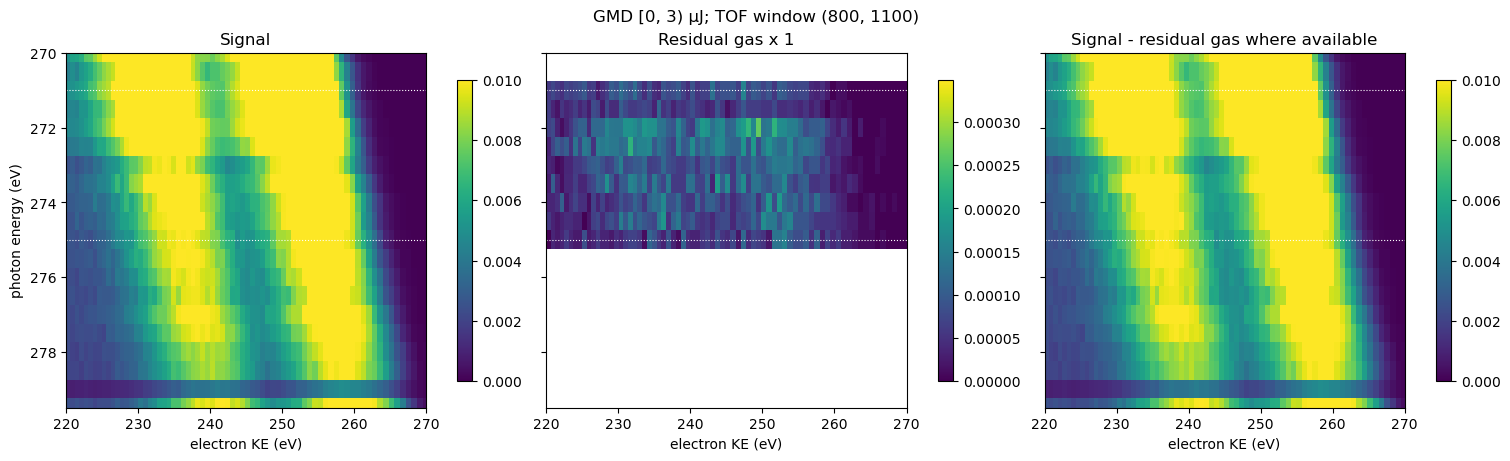

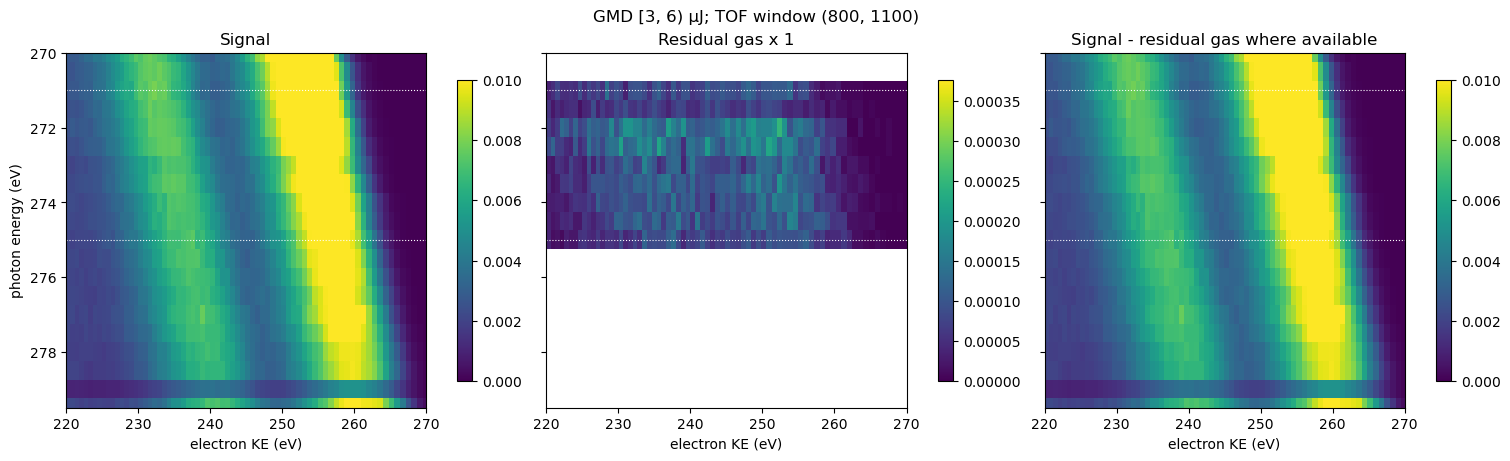

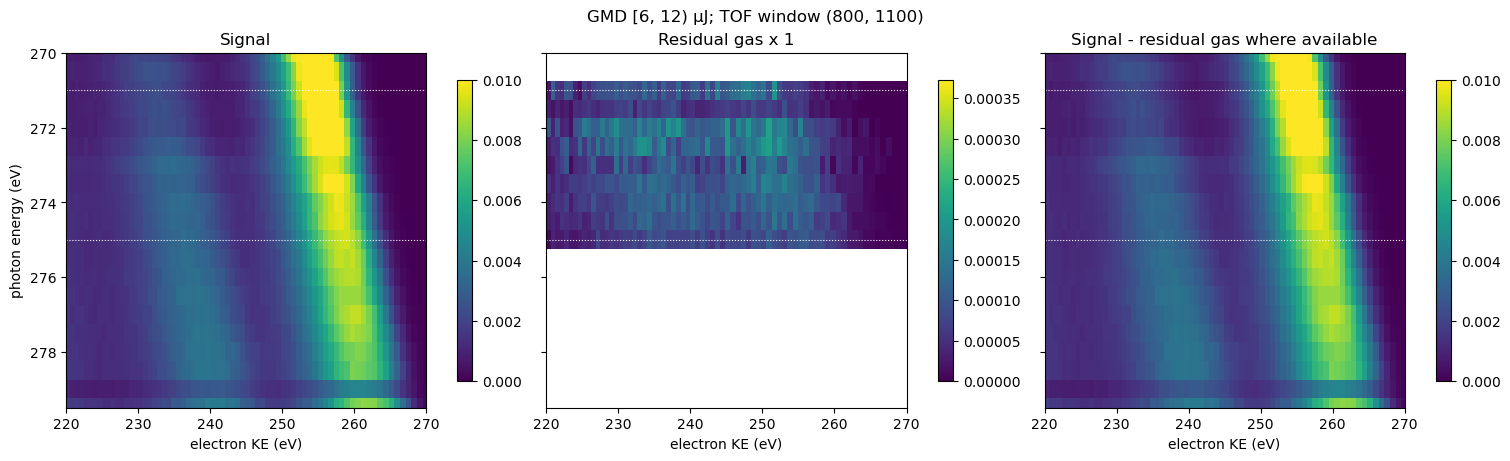

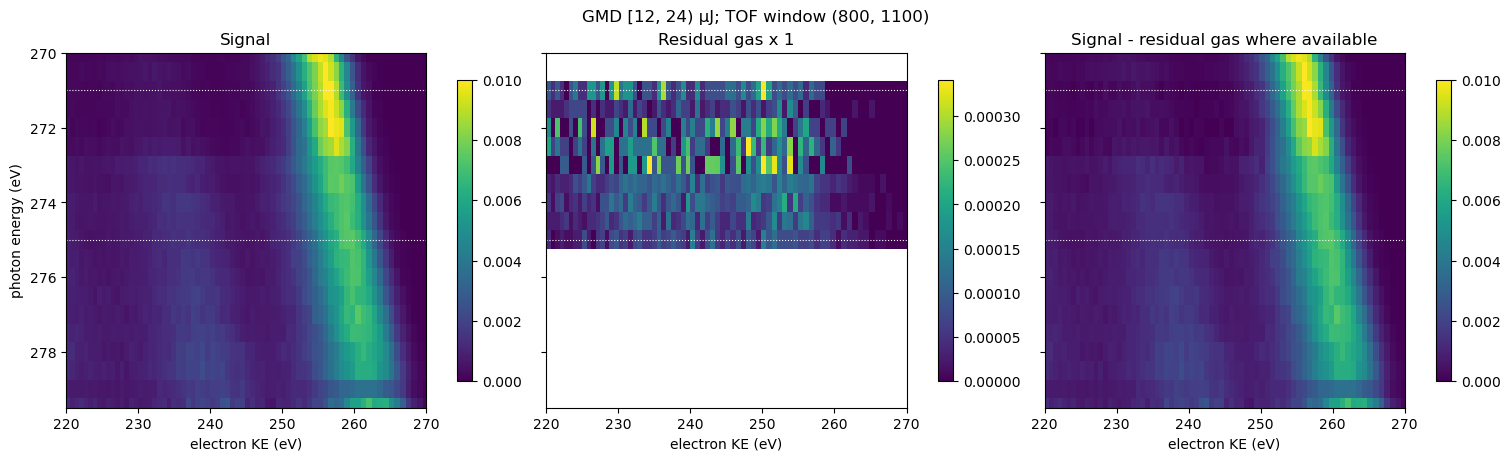

In [59]:
# --- Plot raw signal, matched background, and partial subtraction on KE axis -----

TOF_RANGE = (800, 1100)

RAW_VMAX = 0.01      # change this
BG_VMAX = None       # keep auto
SUB_VMAX = RAW_VMAX      # change this

def _energy_edges(e):
    e = np.asarray(e, dtype=np.float64)
    if len(e) == 1:
        return np.array([e[0] - 0.25, e[0] + 0.25])
    mid = 0.5 * (e[:-1] + e[1:])
    return np.concatenate([[2 * e[0] - mid[0]], mid, [2 * e[-1] - mid[-1]]])

def _robust_limits(arr, p_lo=1, p_hi=99.5):
    finite = arr[np.isfinite(arr)]
    if finite.size == 0:
        return 0.0, 1.0
    return float(np.nanpercentile(finite, p_lo)), float(np.nanpercentile(finite, p_hi))

e_edges = _energy_edges(energies)

for g in range(len(gmd_edges) - 1):
    raw = stack[:, g, :]
    bg = bg_on_signal[:, g, :]
    sub = stack_bgsub_partial[:, g, :]

    raw_vmin, raw_vmax = _robust_limits(raw)
    bg_vmin, bg_vmax = _robust_limits(bg)
    sub_vmin, sub_vmax = _robust_limits(sub)
    
    if RAW_VMAX is not None:
        raw_vmax = RAW_VMAX
    if BG_VMAX is not None:
        bg_vmax = BG_VMAX
    if SUB_VMAX is not None:
        sub_vmax = SUB_VMAX

    fig, axes = plt.subplots(
        1, 3, figsize=(15, 4.5), sharey=True, constrained_layout=True
    )

    panels = [
        (raw, raw_vmin, raw_vmax, "Signal"),
        (bg, bg_vmin, bg_vmax, f"Residual gas x {BG_SCALE:g}"),
        (sub, sub_vmin, sub_vmax, "Signal - residual gas where available"),
    ]

    for ax, (data, vmin, vmax, title) in zip(axes, panels):
        ke_edges, data_ke = _tof_window_to_ke_edges_and_data(
            tof_edges, data, TOF_RANGE
        )

        pcm = ax.pcolormesh(
            ke_edges,
            e_edges,
            data_ke,
            shading="auto",
            cmap="viridis",
            vmin=vmin,
            vmax=vmax,
        )

        ax.set_title(title)
        ax.set_xlabel("electron KE (eV)")
        fig.colorbar(pcm, ax=ax, shrink=0.85)

        if has_background.any():
            ax.axhline(np.nanmin(energies[has_background]), color="w", ls=":", lw=0.8)
            ax.axhline(np.nanmax(energies[has_background]), color="w", ls=":", lw=0.8)
        ax.set_ylim(279.5,270)
        ax.set_xlim(220,270)

    axes[0].set_ylabel("photon energy (eV)")
    fig.suptitle(
        f"GMD [{gmd_edges[g]:.2g}, {gmd_edges[g+1]:.2g}) µJ; "
        f"TOF window {TOF_RANGE}"
    )
    plt.show()

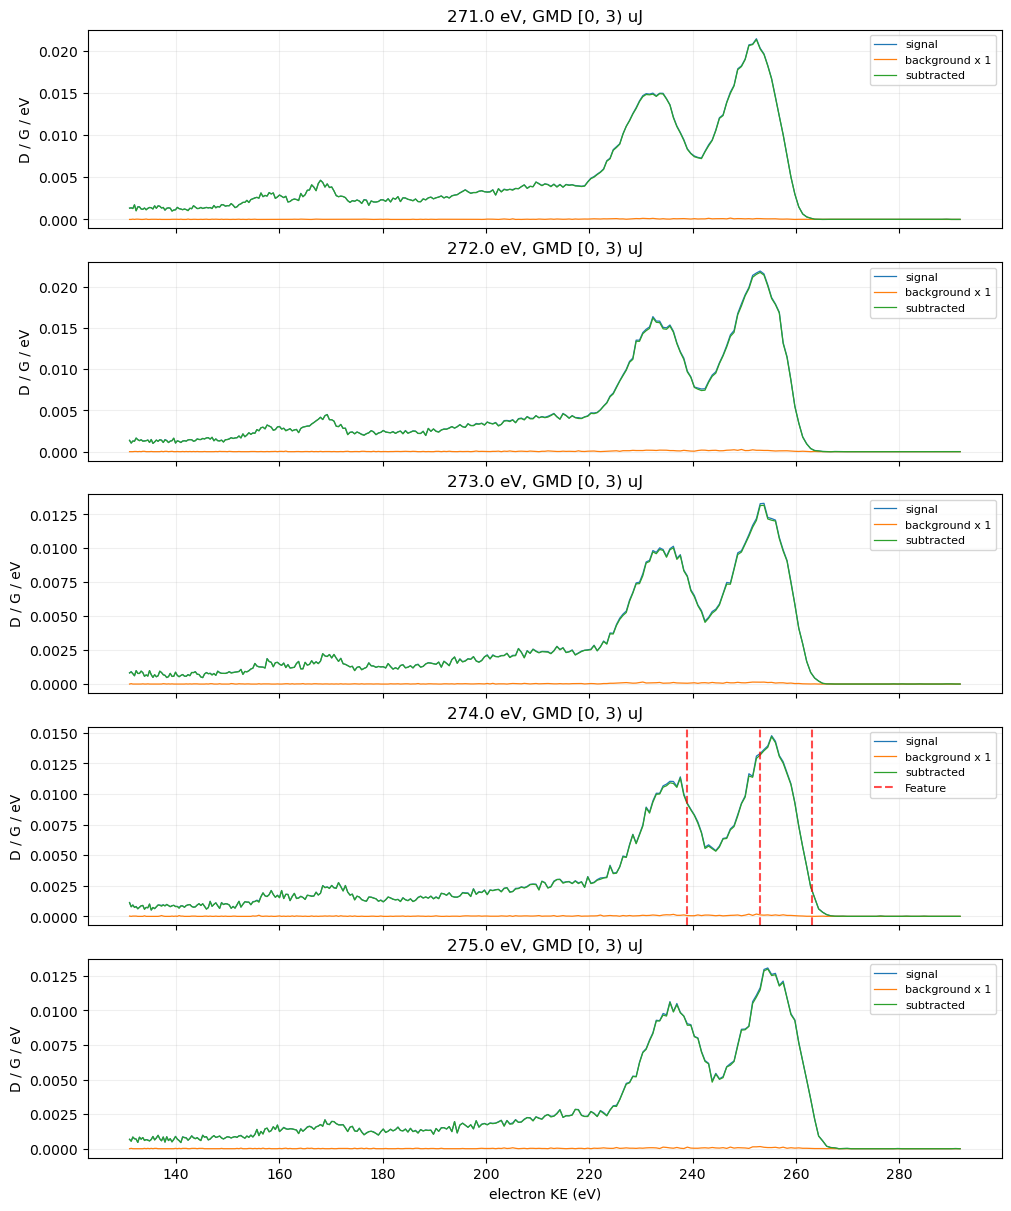

In [56]:
# --- Lineouts: raw signal vs background vs subtracted on KE axis ------
# This version plots intensity density: D/G/eV.
# It divides each original TOF-bin value by the calibrated KE bin width.

ENERGIES_TO_COMPARE = [271.0, 272.0, 273.0, 274.0, 275.0]
GMD_BIN = 0
TOF_LINEOUT_RANGE = (800, 1100)
PLOT_DENSITY = True   # True -> D/G/eV, False -> D/G per original TOF bin

tof_cent = 0.5 * (tof_edges[:-1] + tof_edges[1:])

tof_mask = np.ones_like(tof_cent, dtype=bool)
if TOF_LINEOUT_RANGE[0] is not None:
    tof_mask &= tof_cent >= TOF_LINEOUT_RANGE[0]
if TOF_LINEOUT_RANGE[1] is not None:
    tof_mask &= tof_cent <= TOF_LINEOUT_RANGE[1]

idx_tof = np.where(tof_mask)[0]
if idx_tof.size == 0:
    raise ValueError(f"No TOF bins inside TOF_LINEOUT_RANGE={TOF_LINEOUT_RANGE}")

lo = int(idx_tof[0])
hi = int(idx_tof[-1]) + 1

tof_edges_s = tof_edges[lo:hi + 1]
tof_cent_s = tof_cent[lo:hi]

ke_edges_s = tof_to_ke(tof_edges_s)
ke_cent_s = tof_to_ke(tof_cent_s)

if not np.all(np.isfinite(ke_edges_s)):
    raise ValueError("Some KE edges are NaN. Choose a TOF range fully above t0.")

good = np.isfinite(ke_cent_s)

if PLOT_DENSITY:
    dke = np.abs(np.diff(ke_edges_s))
    yscale = dke
    ylabel = "D / G / eV"
else:
    yscale = np.ones_like(ke_cent_s)
    ylabel = "D / G per TOF bin"

order = np.argsort(ke_cent_s[good])
ke_plot = ke_cent_s[good][order]

fig, axes = plt.subplots(
    len(ENERGIES_TO_COMPARE),
    1,
    figsize=(10, 2.4 * len(ENERGIES_TO_COMPARE)),
    sharex=True,
    constrained_layout=True,
)
axes = np.atleast_1d(axes)

for idx_plot, (ax, e) in enumerate(zip(axes, ENERGIES_TO_COMPARE)):
    idx_energy = np.where(np.isclose(energies, e))[0]

    if len(idx_energy) == 0:
        ax.text(0.5, 0.5, f"{e:.1f} eV not in signal", transform=ax.transAxes)
        ax.set_ylabel(ylabel)
        continue

    i = int(idx_energy[0])

    with np.errstate(invalid="ignore", divide="ignore"):
        sig_y = stack[i, GMD_BIN, lo:hi].astype(float) / yscale

    ax.plot(
        ke_plot,
        sig_y[good][order],
        lw=0.9,
        label="signal",
    )

    if has_background[i]:
        with np.errstate(invalid="ignore", divide="ignore"):
            bg_y = BG_SCALE * bg_on_signal[i, GMD_BIN, lo:hi].astype(float) / yscale
            sub_y = stack_bgsub_partial[i, GMD_BIN, lo:hi].astype(float) / yscale

        ax.plot(
            ke_plot,
            bg_y[good][order],
            lw=0.9,
            label=f"background x {BG_SCALE:g}",
        )
        ax.plot(
            ke_plot,
            sub_y[good][order],
            lw=0.9,
            label="subtracted",
        )
    else:
        with np.errstate(invalid="ignore", divide="ignore"):
            sub_y = stack_bgsub_partial[i, GMD_BIN, lo:hi].astype(float) / yscale

        ax.plot(
            ke_plot,
            sub_y[good][order],
            lw=0.9,
            label="unchanged",
        )

    if idx_plot == 3:
        lines_x = [273.2 - 10, 273.2 - 20.2, 273.2 - 34.3]
        for n, x_val in enumerate(lines_x):
            ax.axvline(
                x=x_val,
                color="red",
                linestyle="--",
                alpha=0.7,
                label="Feature" if n == 0 else "",
            )

    ax.set_title(
        f"{e:.1f} eV, GMD [{gmd_edges[GMD_BIN]:.2g}, "
        f"{gmd_edges[GMD_BIN + 1]:.2g}) uJ"
    )
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.2)
    ax.legend(fontsize=8)

axes[-1].set_xlabel("electron KE (eV)")
plt.show()

In [47]:
# --- Combine all GMD bins into one total map -------------------------

def _weighted_mean_over_gmd(arr, weights):
    """
    arr:     (n_energy, n_gmd, n_tof)
    weights: (n_energy, n_gmd), e.g. n_shots

    Returns:
        (n_energy, n_tof)
    """
    arr = np.asarray(arr, dtype=float)
    weights = np.asarray(weights, dtype=float)

    valid = np.isfinite(arr) & np.isfinite(weights[:, :, None]) & (weights[:, :, None] > 0)
    w = np.where(valid, weights[:, :, None], 0.0)
    x = np.where(valid, arr, 0.0)

    denom = np.sum(w, axis=1)
    out = np.sum(x * w, axis=1) / denom
    out[denom == 0] = np.nan
    return out


# Signal weights: use signal aggregate shot counts.
signal_total = _weighted_mean_over_gmd(stack, n_shots)

# Background on signal grid: use the signal weights so the combined background
# matches the GMD-bin mixture of the signal at each energy.
background_total = _weighted_mean_over_gmd(bg_on_signal, n_shots)

# Partial subtraction: exact-energy background subtracted where available,
# unchanged otherwise, already GMD-bin resolved; now combine the result.
subtracted_total = _weighted_mean_over_gmd(stack_bgsub_partial, n_shots)

print("signal_total:", signal_total.shape)
print("background_total:", background_total.shape)
print("subtracted_total:", subtracted_total.shape)

signal_total: (32, 5000)
background_total: (32, 5000)
subtracted_total: (32, 5000)


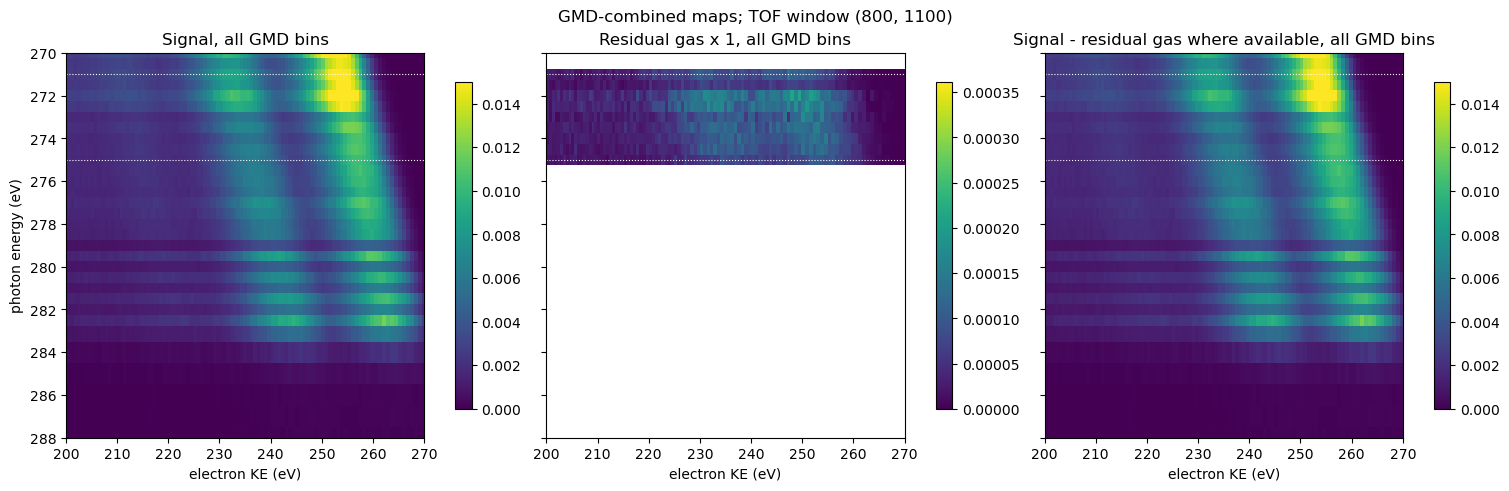

In [50]:
# --- Plot total GMD-combined signal/background/subtracted maps --------
import matplotlib.colors as mcolors
w_b_r = mcolors.LinearSegmentedColormap.from_list("WhiteBlueRed", ["white", "blue", "red"])

TOF_RANGE = (800, 1100)

RAW_VMAX = 0.015      # change this
BG_VMAX = None       # keep auto
SUB_VMAX = RAW_VMAX      # change this



e_edges = _energy_edges(energies)

panels = [
    (signal_total, RAW_VMAX, "Signal, all GMD bins"),
    (background_total, BG_VMAX, f"Residual gas x {BG_SCALE:g}, all GMD bins"),
    (subtracted_total, SUB_VMAX, "Signal - residual gas where available, all GMD bins"),
]

fig, axes = plt.subplots(
    1, 3, figsize=(15, 4.8), sharey=True, constrained_layout=True
)

for ax, (data, manual_vmax, title) in zip(axes, panels):
    vmin, vmax = _robust_limits(data)
    if manual_vmax is not None:
        vmax = manual_vmax

    ke_edges, data_ke = _tof_window_to_ke_edges_and_data(
        tof_edges, data, TOF_RANGE
    )

    pcm = ax.pcolormesh(
        ke_edges,
        e_edges,
        data_ke,
        shading="auto",
        cmap="viridis",
        #cmap=w_b_r,  This is the red and blue map similar to the paper, but not quite, as the red in the paper reached low4er values
        vmin=vmin,
        vmax=vmax,
    )

    ax.set_title(title)
    ax.set_xlabel("electron KE (eV)")
    fig.colorbar(pcm, ax=ax, shrink=0.85)

    if has_background.any():
        ax.axhline(np.nanmin(energies[has_background]), color="w", ls=":", lw=0.8)
        ax.axhline(np.nanmax(energies[has_background]), color="w", ls=":", lw=0.8)

    ax.set_ylim(288,270)
    ax.set_xlim(200,270)


axes[0].set_ylabel("photon energy (eV)")
fig.suptitle(f"GMD-combined maps; TOF window {TOF_RANGE}")
plt.show()

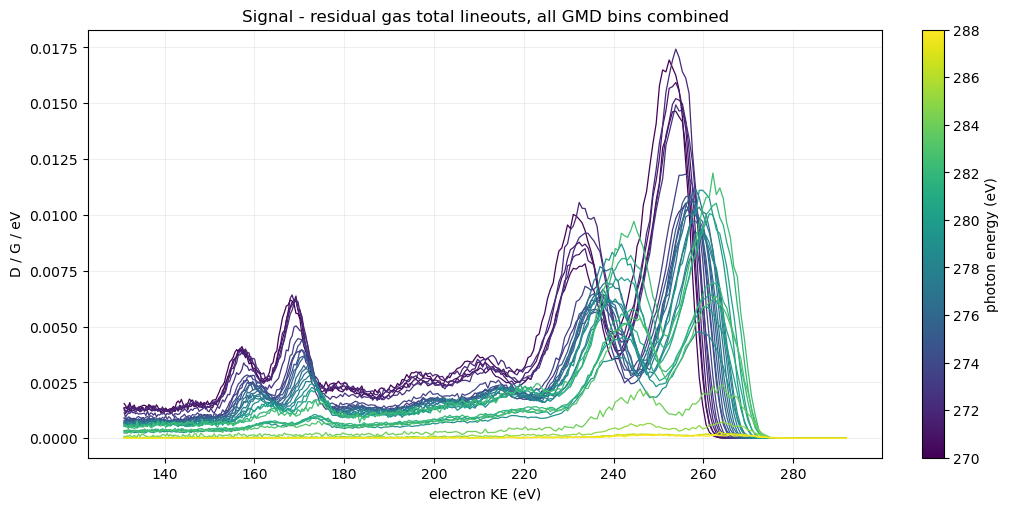

In [49]:
# --- Total-map lineouts: all photon energies, calibrated KE ----------
# This version plots intensity density: D/G/eV.
# It divides each original TOF-bin value by the calibrated KE bin width.

TOF_LINEOUT_RANGE = (800, 1100)
PLOT_DENSITY = True   # True -> D/G/eV, False -> D/G per original TOF bin

# Choose which total map to plot:
TOTAL_MAP = subtracted_total
TITLE_LABEL = "Signal - residual gas total"

# Alternatives:
# TOTAL_MAP = signal_total
# TITLE_LABEL = "Signal total"
#
# TOTAL_MAP = background_total
# TITLE_LABEL = "Residual gas total"
#
# TOTAL_MAP = subtracted_total
# TITLE_LABEL = "Signal - residual gas total"

tof_cent = 0.5 * (tof_edges[:-1] + tof_edges[1:])

tof_mask = np.ones_like(tof_cent, dtype=bool)
if TOF_LINEOUT_RANGE[0] is not None:
    tof_mask &= tof_cent >= TOF_LINEOUT_RANGE[0]
if TOF_LINEOUT_RANGE[1] is not None:
    tof_mask &= tof_cent <= TOF_LINEOUT_RANGE[1]

idx = np.where(tof_mask)[0]
if idx.size == 0:
    raise ValueError(f"No TOF bins inside TOF_LINEOUT_RANGE={TOF_LINEOUT_RANGE}")

lo = int(idx[0])
hi = int(idx[-1]) + 1

tof_edges_s = tof_edges[lo:hi + 1]
tof_cent_s = tof_cent[lo:hi]

ke_edges_s = tof_to_ke(tof_edges_s)
ke_cent_s = tof_to_ke(tof_cent_s)

if not np.all(np.isfinite(ke_edges_s)):
    raise ValueError("Some KE edges are NaN. Choose a TOF range fully above t0.")

good = np.isfinite(ke_cent_s)

if PLOT_DENSITY:
    dke = np.abs(np.diff(ke_edges_s))
    yscale = dke
    ylabel = "D / G / eV"
else:
    yscale = np.ones_like(ke_cent_s)
    ylabel = "D / G per TOF bin"

order = np.argsort(ke_cent_s[good])
ke_plot = ke_cent_s[good][order]

cmap = plt.get_cmap("viridis")
norm = plt.Normalize(vmin=np.nanmin(energies), vmax=np.nanmax(energies))

fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)

for i, e in enumerate(energies):
    y = TOTAL_MAP[i, lo:hi].astype(float)

    with np.errstate(invalid="ignore", divide="ignore"):
        y = y / yscale

    y_plot = y[good][order]

    ax.plot(
        ke_plot,
        y_plot,
        lw=0.9,
        color=cmap(norm(e)),
        label=f"{e:.1f} eV",
    )

sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("photon energy (eV)")

ax.set_xlabel("electron KE (eV)")
ax.set_ylabel(ylabel)
ax.set_title(f"{TITLE_LABEL} lineouts, all GMD bins combined")
ax.grid(alpha=0.2)

plt.show()

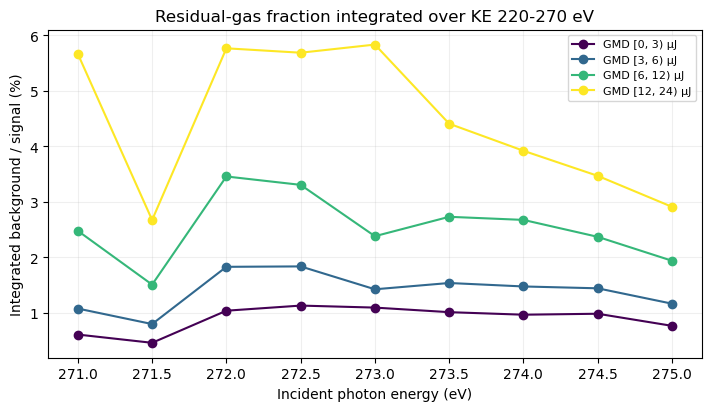

Integrated over KE range: 220-270 eV
Number of TOF/KE bins included: 72


In [39]:
# --- Integrated background/signal fraction vs photon energy ----------
#     One curve per GMD bin, integrated over a KE window.

KE_COMPARE_RANGE = (220, 270)  # eV

tof_cent = 0.5 * (tof_edges[:-1] + tof_edges[1:])
ke_cent = tof_to_ke(tof_cent)

ke_mask = (
    np.isfinite(ke_cent)
    & (ke_cent >= KE_COMPARE_RANGE[0])
    & (ke_cent <= KE_COMPARE_RANGE[1])
)

fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)

cmap = plt.get_cmap("viridis")
n_gmd = len(gmd_edges) - 1

for GMD_BIN in range(n_gmd):
    e_plot = []
    frac_sum = []

    for i, e in enumerate(energies):
        if not has_background[i]:
            continue

        sig = stack[i, GMD_BIN, ke_mask]
        bg = bg_on_signal[i, GMD_BIN, ke_mask]

        sig_sum = np.nansum(sig)
        bg_sum = np.nansum(bg)

        e_plot.append(e)
        frac_sum.append(100 * bg_sum / sig_sum if sig_sum else np.nan)

    color = cmap(GMD_BIN / max(n_gmd - 1, 1))
    label = f"GMD [{gmd_edges[GMD_BIN]:.2g}, {gmd_edges[GMD_BIN+1]:.2g}) µJ"

    ax.plot(e_plot, frac_sum, "o-", color=color, label=label)

ax.set_xlabel("Incident photon energy (eV)")
ax.set_ylabel("Integrated background / signal (%)")
ax.set_title(f"Residual-gas fraction integrated over KE {KE_COMPARE_RANGE[0]}-{KE_COMPARE_RANGE[1]} eV")
ax.grid(alpha=0.2)
ax.legend(fontsize=8)

plt.show()

print(f"Integrated over KE range: {KE_COMPARE_RANGE[0]}-{KE_COMPARE_RANGE[1]} eV")
print(f"Number of TOF/KE bins included: {np.count_nonzero(ke_mask)}")

## Binding energy representation

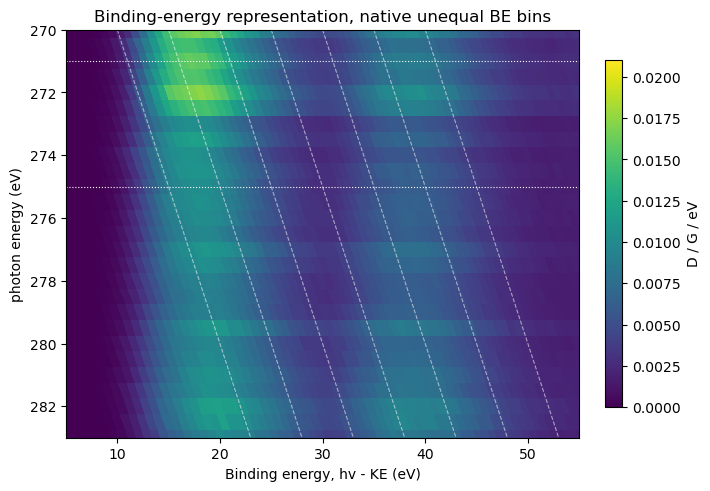

KE edges: (301,)
binding_map: (27, 300)
be_x_edges: (28, 301)
be_y_edges: (28, 301)


In [323]:
# --- Binding-energy map from calibrated unequal KE bins ----------------
# This version keeps the native unequal bins from the TOF -> KE calibration.
# It does NOT interpolate onto a uniform BE grid.

TOF_RANGE = (800, 1100)
BE_RANGE = (5.0, 55.0)

def kinetic_to_binding_map(
    signal_ke_map,
    photon_energies,
    ke_edges,
    *,
    binding_bins="unequal",
    be_centres=None,
    energy_edges=None,
):
    """
    Remap S(hv, KE) onto apparent binding energy, BE = hv - KE.

    binding_bins="unequal":
        Keeps the native calibrated KE bin widths.
        BE bin edges are different for each photon-energy row.
        Returns:
            be_map, be_x_edges, be_y_edges

    binding_bins="equal":
        Interpolates onto one shared BE axis given by be_centres.
        Returns:
            be_map, be_edges
    """
    signal_ke_map = np.asarray(signal_ke_map, dtype=float)
    photon_energies = np.asarray(photon_energies, dtype=float)
    ke_edges = np.asarray(ke_edges, dtype=float)

    ke_centres = 0.5 * (ke_edges[:-1] + ke_edges[1:])

    expected_shape = (len(photon_energies), len(ke_centres))
    if signal_ke_map.shape != expected_shape:
        raise ValueError(
            f"shape mismatch: signal_ke_map has {signal_ke_map.shape}, "
            f"expected {expected_shape}"
        )

    if binding_bins in ("unequal", "native", "calibrated"):
        if energy_edges is None:
            energy_edges = _energy_edges(photon_energies)

        energy_edges = np.asarray(energy_edges, dtype=float)

        # We want BE increasing left-to-right.
        # If KE increases left-to-right, BE = hv - KE decreases left-to-right,
        # so reverse the KE axis and data columns.
        if ke_edges[0] < ke_edges[-1]:
            ke_edges_for_be = ke_edges[::-1]
            be_map = signal_ke_map[:, ::-1]
        else:
            ke_edges_for_be = ke_edges
            be_map = signal_ke_map

        be_x_edges = energy_edges[:, None] - ke_edges_for_be[None, :]
        be_y_edges = np.repeat(
            energy_edges[:, None],
            len(ke_edges_for_be),
            axis=1,
        )

        return be_map, be_x_edges, be_y_edges

    if binding_bins in ("equal", "uniform", "interpolated"):
        if be_centres is None:
            raise ValueError("be_centres is required for binding_bins='equal'")

        be_centres = np.asarray(be_centres, dtype=float)
        be_edges = _energy_edges(be_centres)

        be_map = np.full(
            (len(photon_energies), len(be_centres)),
            np.nan,
            dtype=float,
        )

        for row, hv in enumerate(photon_energies):
            apparent_be = hv - ke_centres
            order = np.argsort(apparent_be)

            be_map[row] = np.interp(
                be_centres,
                apparent_be[order],
                signal_ke_map[row, order],
                left=np.nan,
                right=np.nan,
            )

        return be_map, be_edges

    raise ValueError(
        "binding_bins must be 'unequal'/'native' or 'equal'/'uniform'"
    )


# Convert total subtracted TOF map to calibrated unequal KE bins.
# Your helper divides by dKE, so subtracted_ke is D/G/eV.
ke_edges, subtracted_ke = _tof_window_to_ke_edges_and_data(
    tof_edges,
    subtracted_total,
    TOF_RANGE,
)

e_edges = _energy_edges(energies)

binding_map, be_x_edges, be_y_edges = kinetic_to_binding_map(
    signal_ke_map=subtracted_ke,
    photon_energies=energies,
    ke_edges=ke_edges,
    binding_bins="unequal",
    energy_edges=e_edges,
)

vmin, vmax = _robust_limits(binding_map)
if SUB_VMAX is not None:
    vmax = SUB_VMAX * 1.4

fig, ax = plt.subplots(figsize=(7, 4.8), constrained_layout=True)

pcm = ax.pcolormesh(
    be_x_edges,
    be_y_edges,
    binding_map,
    shading="auto",
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
)

fig.colorbar(pcm, ax=ax, shrink=0.85, label="D / G / eV")

ax.set_xlabel("Binding energy, hv - KE (eV)")
ax.set_ylabel("photon energy (eV)")
ax.set_title("Binding-energy representation, native unequal BE bins")

fixed_ke_values = [230, 235, 240, 245, 250, 255, 260]

for fixed_ke in fixed_ke_values:
    expected_be = energies - fixed_ke

    visible = (
        np.isfinite(expected_be)
        & (expected_be >= BE_RANGE[0])
        & (expected_be <= BE_RANGE[1])
    )

    if np.any(visible):
        ax.plot(
            expected_be[visible],
            energies[visible],
            linestyle="--",
            linewidth=0.8,
            alpha=0.55,
            color="w",
        )

        label_idx = np.flatnonzero(visible)[0]
        ax.text(
            expected_be[label_idx],
            energies[label_idx],
            f"{fixed_ke:g} eV KE",
            color="w",
            fontsize=7,
            alpha=0.8,
            va="bottom",
            ha="left",
        )

if has_background.any():
    ax.axhline(np.nanmin(energies[has_background]), color="w", ls=":", lw=0.8)
    ax.axhline(np.nanmax(energies[has_background]), color="w", ls=":", lw=0.8)

ax.set_ylim(283, 270)
ax.set_xlim(BE_RANGE)

plt.show()

print("KE edges:", ke_edges.shape)
print("binding_map:", binding_map.shape)
print("be_x_edges:", be_x_edges.shape)
print("be_y_edges:", be_y_edges.shape)

### Normalisation by the integral of each line

In [324]:

# --- Row-normalise binding_map by its integrated BE intensity ----------

# Use bin widths, so this is a real integral over binding energy.


binding_map_norm, binding_integral = row_normalise_binding_map(
    binding_map,
    be_x_edges=be_x_edges,
    integral_mode="signed",
)

print("binding_map shape:", binding_map.shape)
print("binding_map_norm shape:", binding_map_norm.shape)
print("Integral range before normalisation:")
print(f"  min    = {np.nanmin(binding_integral):.6g}")
print(f"  median = {np.nanmedian(binding_integral):.6g}")
print(f"  max    = {np.nanmax(binding_integral):.6g}")

binding_map shape: (27, 300)
binding_map_norm shape: (27, 300)
Integral range before normalisation:
  min    = 0.322657
  median = 0.3765
  max    = 0.59641


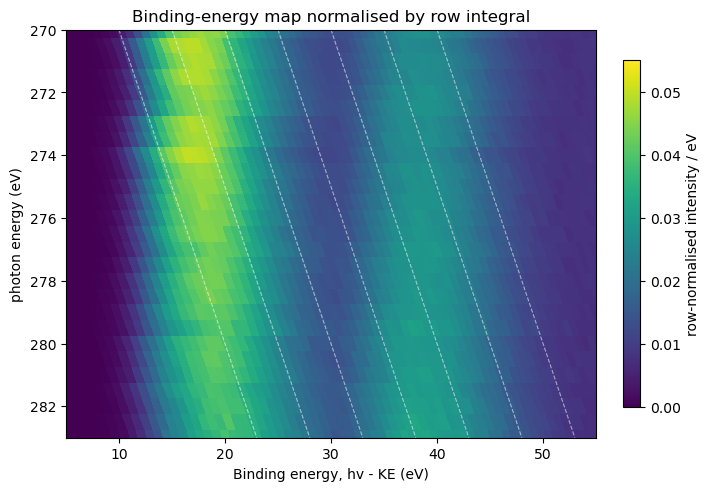

binding_map shape: (27, 300)
be_x_edges shape: (28, 301)
normalisation mode: positive
integral range: 0.211305341457766 0.24835992752252134 0.3712899486418476


In [326]:
# --- Plot BE-normalised binding-energy map, unequal/native BE bins -----

TOF_RANGE = (800, 1100)
BE_RANGE = (5.0, 55.0)

# Convert total subtracted map from TOF bins to unequal calibrated KE bins.
# _tof_window_to_ke_edges_and_data already divides by dKE, so the output is D/G/eV.
ke_edges, subtracted_ke = _tof_window_to_ke_edges_and_data(
    tof_edges,
    subtracted_total,
    TOF_RANGE,
)

e_edges = _energy_edges(energies)

# Convert KE axis to native/unequal BE coordinates.
binding_map, be_x_edges, be_y_edges = kinetic_to_binding_map(
    signal_ke_map=subtracted_ke,
    photon_energies=energies,
    ke_edges=ke_edges,
    binding_bins="unequal",
    energy_edges=e_edges,
)

# Build per-cell BE widths and centres from the 2D pcolormesh edge grid.
# be_x_edges has shape (n_energy_edges, n_be_edges).
be_widths_edges = np.abs(np.diff(be_x_edges, axis=1))

if be_widths_edges.shape[0] == binding_map.shape[0] + 1:
    be_widths = 0.5 * (be_widths_edges[:-1, :] + be_widths_edges[1:, :])
else:
    be_widths = be_widths_edges

be_centres_2d = 0.25 * (
    be_x_edges[:-1, :-1]
    + be_x_edges[:-1, 1:]
    + be_x_edges[1:, :-1]
    + be_x_edges[1:, 1:]
)

visible_be = (
    np.isfinite(be_centres_2d)
    & (be_centres_2d >= BE_RANGE[0])
    & (be_centres_2d <= BE_RANGE[1])
)

# Row-normalise by the displayed BE integral.
# For subtracted data, "positive" is often more stable than signed.
INTEGRAL_MODE = "positive"  # options: "signed", "positive", "absolute"

if INTEGRAL_MODE == "signed":
    integrand = binding_map
elif INTEGRAL_MODE == "positive":
    integrand = np.where(binding_map > 0, binding_map, 0.0)
elif INTEGRAL_MODE == "absolute":
    integrand = np.abs(binding_map)
else:
    raise ValueError("INTEGRAL_MODE must be 'signed', 'positive', or 'absolute'")

binding_integral = np.nansum(
    np.where(visible_be, integrand * be_widths, np.nan),
    axis=1,
)

with np.errstate(invalid="ignore", divide="ignore"):
    binding_map_norm = binding_map / binding_integral[:, None]

binding_map_norm[~np.isfinite(binding_map_norm)] = np.nan

# Plot.
vmin, vmax = _robust_limits(binding_map_norm)
vmax = 0.055

fig, ax = plt.subplots(figsize=(7, 4.8), constrained_layout=True)

pcm = ax.pcolormesh(
    be_x_edges,
    be_y_edges,
    binding_map_norm,
    shading="auto",
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
)

fixed_ke_values = [230, 235, 240, 245, 250, 255, 260]

for fixed_ke in fixed_ke_values:
    expected_be = energies - fixed_ke
    visible = (
        np.isfinite(expected_be)
        & (expected_be >= BE_RANGE[0])
        & (expected_be <= BE_RANGE[1])
    )

    if np.any(visible):
        ax.plot(
            expected_be[visible],
            energies[visible],
            linestyle="--",
            linewidth=0.8,
            alpha=0.55,
            color="w",
        )

fig.colorbar(pcm, ax=ax, shrink=0.85, label="row-normalised intensity / eV")
ax.set_xlabel("Binding energy, hv - KE (eV)")
ax.set_ylabel("photon energy (eV)")
ax.set_title("Binding-energy map normalised by row integral")

ax.set_ylim(283, 270)
ax.set_xlim(BE_RANGE)

plt.show()

print("binding_map shape:", binding_map.shape)
print("be_x_edges shape:", be_x_edges.shape)
print("normalisation mode:", INTEGRAL_MODE)
print("integral range:", np.nanmin(binding_integral), np.nanmedian(binding_integral), np.nanmax(binding_integral))

### For each GMD bin

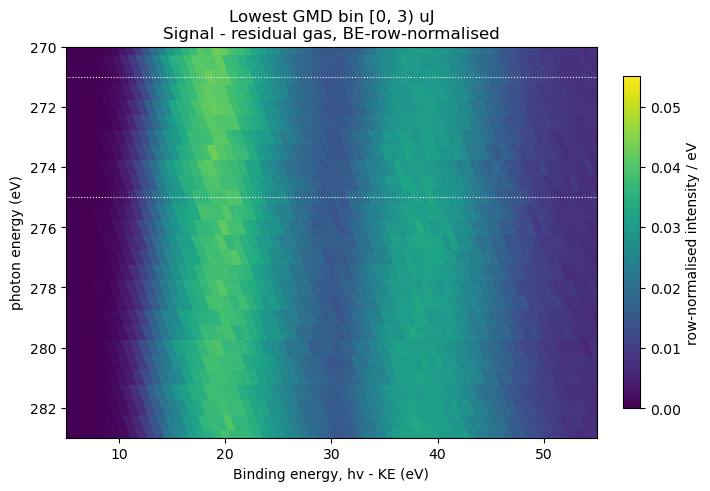

binding_low_gmd shape: (27, 300)
be_x_edges_low_gmd shape: (28, 301)
normalisation mode: positive
integral range: 0.2623570017234382 0.3233943409158792 0.5264706254332783


In [328]:
# --- Lowest-GMD bin: residual-background-subtracted BE map, row-normalised -----

TOF_RANGE = (800, 1100)
BE_RANGE = (5.0, 55.0)
GMD_BIN = 0

e_edges = _energy_edges(energies)

# Lowest-GMD residual-background-subtracted map.
sub_low_gmd = stack_bgsub_partial[:, GMD_BIN, :]

# Convert TOF axis to unequal calibrated KE bins.
# _tof_window_to_ke_edges_and_data already divides by dKE, so the output is D/G/eV.
ke_edges_low_gmd, sub_low_gmd_ke = _tof_window_to_ke_edges_and_data(
    tof_edges,
    sub_low_gmd,
    TOF_RANGE,
)

# Convert KE axis to native/unequal BE coordinates.
binding_low_gmd, be_x_edges_low_gmd, be_y_edges_low_gmd = kinetic_to_binding_map(
    signal_ke_map=sub_low_gmd_ke,
    photon_energies=energies,
    ke_edges=ke_edges_low_gmd,
    binding_bins="unequal",
    energy_edges=e_edges,
)

# Build per-cell BE widths and centres from the 2D pcolormesh edge grid.
be_widths_edges = np.abs(np.diff(be_x_edges_low_gmd, axis=1))

if be_widths_edges.shape[0] == binding_low_gmd.shape[0] + 1:
    be_widths = 0.5 * (be_widths_edges[:-1, :] + be_widths_edges[1:, :])
else:
    be_widths = be_widths_edges

be_centres_2d = 0.25 * (
    be_x_edges_low_gmd[:-1, :-1]
    + be_x_edges_low_gmd[:-1, 1:]
    + be_x_edges_low_gmd[1:, :-1]
    + be_x_edges_low_gmd[1:, 1:]
)

visible_be = (
    np.isfinite(be_centres_2d)
    & (be_centres_2d >= BE_RANGE[0])
    & (be_centres_2d <= BE_RANGE[1])
)

# Row-normalise by the displayed BE integral.
# For subtracted data, "positive" is often more stable than signed.
INTEGRAL_MODE = "positive"  # options: "signed", "positive", "absolute"

if INTEGRAL_MODE == "signed":
    integrand = binding_low_gmd
elif INTEGRAL_MODE == "positive":
    integrand = np.where(binding_low_gmd > 0, binding_low_gmd, 0.0)
elif INTEGRAL_MODE == "absolute":
    integrand = np.abs(binding_low_gmd)
else:
    raise ValueError("INTEGRAL_MODE must be 'signed', 'positive', or 'absolute'")

binding_low_gmd_integral = np.nansum(
    np.where(visible_be, integrand * be_widths, np.nan),
    axis=1,
)

with np.errstate(invalid="ignore", divide="ignore"):
    binding_low_gmd_norm = binding_low_gmd / binding_low_gmd_integral[:, None]

binding_low_gmd_norm[~np.isfinite(binding_low_gmd_norm)] = np.nan

# Plot.
vmin, vmax = _robust_limits(binding_low_gmd_norm)
vmax = 0.055

fig, ax = plt.subplots(figsize=(7, 4.8), constrained_layout=True)

pcm = ax.pcolormesh(
    be_x_edges_low_gmd,
    be_y_edges_low_gmd,
    binding_low_gmd_norm,
    shading="auto",
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
)

fig.colorbar(pcm, ax=ax, shrink=0.85, label="row-normalised intensity / eV")

ax.set_xlabel("Binding energy, hv - KE (eV)")
ax.set_ylabel("photon energy (eV)")
ax.set_title(
    f"Lowest GMD bin [{gmd_edges[GMD_BIN]:.2g}, {gmd_edges[GMD_BIN + 1]:.2g}) uJ\n"
    "Signal - residual gas, BE-row-normalised"
)

if has_background.any():
    ax.axhline(np.nanmin(energies[has_background]), color="w", ls=":", lw=0.8)
    ax.axhline(np.nanmax(energies[has_background]), color="w", ls=":", lw=0.8)

ax.set_ylim(283, 270)
ax.set_xlim(BE_RANGE)

plt.show()

print("binding_low_gmd shape:", binding_low_gmd.shape)
print("be_x_edges_low_gmd shape:", be_x_edges_low_gmd.shape)
print("normalisation mode:", INTEGRAL_MODE)
print(
    "integral range:",
    np.nanmin(binding_low_gmd_integral),
    np.nanmedian(binding_low_gmd_integral),
    np.nanmax(binding_low_gmd_integral),
)

## Bin size inspection and regular map (no aggregates)

In [41]:
from data_loading import load_data

# --- Runs --------------------------------------------------------------
RUN_AR = 58890   # Argon calibration
RUN_BG = 58825   # residual-gas background

# Combined-H5 paths. Default to COMBINED_DIR/run<N>.h5; override if needed.
AR_H5 = config.COMBINED_DIR / f"glycine_WL_scan_278.0eV.h5"
BG_H5 = config.COMBINED_DIR / f"background_run58890_per_energy/background_272.0eV_run58890.h5"
#BG_H5 = config.COMBINED_DIR / f"residual_gas_nozzle_in.h5"

# --- Photon energy of the Argon run (eV) -------------------------------
# REQUIRED for photoline KE = hv - BE. Read from the logbook / mpe.
PHOTON_ENERGY_EV = 270   # e.g. 285.0

# --- Signal bunch range (half-open) ------------------------------------
# Determine from the diagnostics notebook for these runs.
SIGNAL_BUNCH_RANGE = (10, 40)

# --- TOF histogram binning (ns) ----------------------------------------
# Span the eTOF window; refine after a first look at the spectrum.
TOF_MIN, TOF_MAX, TOF_BIN = 0.0, 4000.0, 1.0
tof_edges = np.arange(TOF_MIN, TOF_MAX + TOF_BIN, TOF_BIN)
tof_cent  = 0.5 * (tof_edges[:-1] + tof_edges[1:])

# --- Normalisation -----------------------------------------------------
# "per_shot": counts per (train, bunch) shot.
# "per_uJ"  : counts per shot per uJ of GMD (fluence-normalised).
NORMALISE = "per_shot"

# --- Background scaling -------------------------------------------------
# Residual-gas pressure may differ between runs; tune if the subtraction
# over/under-shoots in a known-empty TOF region.
BG_SCALE = 1.0

# --- Resolve / check ---------------------------------------------------
for label, p in [("Ar", AR_H5), ("background", BG_H5)]:
    if not Path(p).exists():
        raise FileNotFoundError(
            f"{label} combined H5 not found: {p}\n"
            f"Build it with write_h5.py (config 1) or set the path above."
        )
print(f"Ar run {RUN_AR}: {AR_H5}")
print(f"BG run {RUN_BG}: {BG_H5}")
print(f"signal bunches [{SIGNAL_BUNCH_RANGE[0]}, {SIGNAL_BUNCH_RANGE[1]}), "
      f"TOF [{TOF_MIN}, {TOF_MAX}] ns / {TOF_BIN} ns bins, normalise={NORMALISE}")

Ar run 58890: /asap3/flash/gpfs/fl24/2026/data/11022188/processed/combined/glycine_WL_scan_278.0eV.h5
BG run 58825: /asap3/flash/gpfs/fl24/2026/data/11022188/processed/combined/background_run58890_per_energy/background_272.0eV_run58890.h5
signal bunches [10, 40), TOF [0.0, 4000.0] ns / 1.0 ns bins, normalise=per_shot


In [42]:
b0, b1 = SIGNAL_BUNCH_RANGE

ar = load_data(str(AR_H5), config=1)
bg = load_data(str(BG_H5), config=1)

for name, d in [("Ar", ar), ("background", bg)]:
    if d.tofs_e is None:
        raise RuntimeError(f"{name} run has no tofs_e - is it a config-1 file?")
    print(f"{name:>10}: n_trains={d.n_trains}, m={d.n_bunches}, "
          f"max_ecounts={d.tofs_e.shape[-1]}")
    if not (0 <= b0 < b1 <= d.n_bunches):
        raise ValueError(
            f"{name}: SIGNAL_BUNCH_RANGE {SIGNAL_BUNCH_RANGE} outside [0, {d.n_bunches}]"
        )

        Ar: n_trains=3001, m=101, max_ecounts=50
background: n_trains=1835, m=101, max_ecounts=50


In [43]:
hits = ar.tofs_e[:, 10:40, :]
n_shots = hits.shape[0] * hits.shape[1]
n_shots
valid = hits[hits > 0] 
mask = hits > 0
valid = hits[mask]
valid

array([ 843,  837,  901, ...,  849,  865, 2266], dtype=uint32)

In [44]:
def average_etof(data, bunch_range, edges, normalise="per_shot"):
    """Average eTOF spectrum over a signal bunch range.

    Excludes zero-padding, histograms all hits in a single pass, and
    normalises so spectra from different runs are comparable.
    Returns (spectrum, n_shots, total_gmd).
    """
    lo, hi = bunch_range
    hits = data.tofs_e[:, lo:hi, :]            # (n_trains, n_sig, max_hits)
    n_shots = hits.shape[0] * hits.shape[1]    # number of (train, bunch) shots
    valid = hits[hits > 0]                     # drop zero-padding
    counts, _ = np.histogram(valid, bins=edges)
    counts = counts.astype(np.float64)

    gmd_sig = np.asarray(data.gmd[:, lo:hi], dtype=np.float64)
    total_gmd = np.nansum(gmd_sig)

    if normalise == "per_shot":
        spectrum = counts / max(n_shots, 1)
    elif normalise == "per_uJ":
        spectrum = counts / total_gmd if total_gmd > 0 else counts
    else:
        raise ValueError(f"unknown NORMALISE={normalise!r}")
    return spectrum, n_shots, total_gmd

ar_spec, ar_n, ar_g = average_etof(ar, SIGNAL_BUNCH_RANGE, tof_edges, NORMALISE)
bg_spec, bg_n, bg_g = average_etof(bg, SIGNAL_BUNCH_RANGE, tof_edges, NORMALISE)

print(f"Ar: {ar_n} shots, total GMD {ar_g:.3g} uJ")
print(f"BG: {bg_n} shots, total GMD {bg_g:.3g} uJ")

Ar: 90030 shots, total GMD 4.73e+05 uJ
BG: 55050 shots, total GMD 1.79e+05 uJ


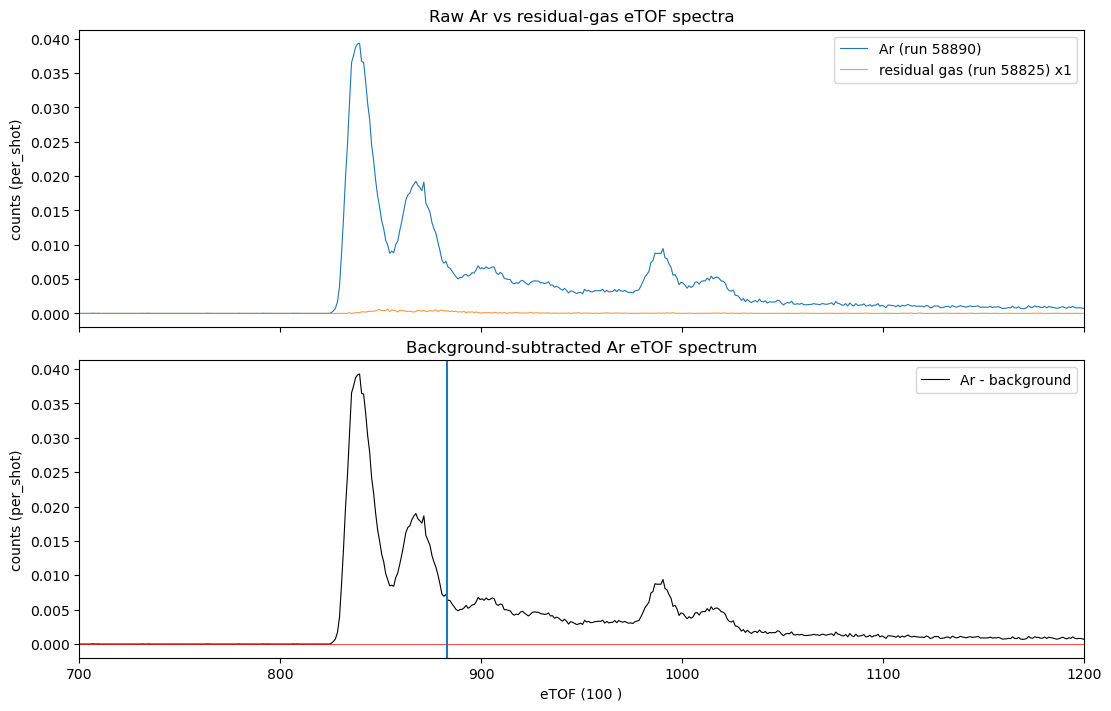

In [45]:
ar_sub = ar_spec - BG_SCALE * bg_spec

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                               constrained_layout=True)
ax1.plot(tof_cent, ar_spec, lw=0.8, label=f"Ar (run {RUN_AR})")
ax1.plot(tof_cent, BG_SCALE * bg_spec, lw=0.8, alpha=0.8,
         label=f"residual gas (run {RUN_BG}) x{BG_SCALE:g}")
ax1.set_ylabel(f"counts ({NORMALISE})")
ax1.legend(); ax1.set_title("Raw Ar vs residual-gas eTOF spectra")

ax2.plot(tof_cent, ar_sub, lw=0.8, color="k", label="Ar - background")
ax2.axhline(0, color="r", lw=0.5)
ax2.set_xlabel("eTOF (100 )"); ax2.set_ylabel(f"counts ({NORMALISE})")
ax2.legend(); ax2.set_title("Background-subtracted Ar eTOF spectrum")
ax2.axvline(883)

# ax2.axvline(x=920.5, color='r', linestyle='--', label='Auger M2')
# ax2.axvline(x=1071.5, color='g', linestyle='--', label='Auger M1')
# ax2.axvline(x=850, color='b', linestyle='--', label='3p')
# ax2.axvline(x=883, color='m', linestyle='--', label='3s')

ax2.set_xlim(700, 1200)

ax2.legend()

# ax2.set_xlim(750,1200)
# ax2.set_xlim(750,1200)
plt.show()

In [334]:
# --- Diagnostic: KE width represented by one TOF bin -------------------

def tof_bin_energy_widths(tof_edges):
    """
    Return KE centre and absolute KE width for each TOF bin.

    Because KE(TOF) is nonlinear, each TOF bin maps to a different
    energy width.
    """
    tof_edges = np.asarray(tof_edges, dtype=float)

    tof_centres = 0.5 * (tof_edges[:-1] + tof_edges[1:])
    ke_edges = tof_to_ke(tof_edges)
    ke_centres = tof_to_ke(tof_centres)

    dke_per_bin = np.abs(np.diff(ke_edges))

    good = (
        np.isfinite(tof_centres)
        & np.isfinite(ke_centres)
        & np.isfinite(dke_per_bin)
    )

    return tof_centres[good], ke_centres[good], dke_per_bin[good]


tof_centres, ke_centres, dke_per_bin = tof_bin_energy_widths(tof_edges)

# Restrict to the TOF range used in your plot.
mask = np.ones_like(tof_centres, dtype=bool)

if TOF_RANGE[0] is not None:
    mask &= tof_centres >= TOF_RANGE[0]
if TOF_RANGE[1] is not None:
    mask &= tof_centres <= TOF_RANGE[1]

tof_w = tof_centres[mask]
ke_w = ke_centres[mask]
dke_w = dke_per_bin[mask]

print(f"TOF bin width in original axis: {np.nanmedian(np.diff(tof_edges)):.6g} TOF units")
print(f"TOF range inspected: {TOF_RANGE}")
print()
print("Across this TOF window:")
print(f"  KE range              : {np.nanmin(ke_w):.3f} to {np.nanmax(ke_w):.3f} eV")
print(f"  eV per TOF bin, min   : {np.nanmin(dke_w):.6f} eV")
print(f"  eV per TOF bin, median: {np.nanmedian(dke_w):.6f} eV")
print(f"  eV per TOF bin, max   : {np.nanmax(dke_w):.6f} eV")

# Value nearest TOF = 800.
target_tof = 840
i = np.nanargmin(np.abs(tof_centres - target_tof))

print()
print(f"Nearest actual TOF bin to {target_tof:g}:")
print(f"  TOF centre            : {tof_centres[i]:.3f}")
print(f"  TOF edges             : {tof_edges[i]:.3f} to {tof_edges[i + 1]:.3f}")
print(f"  KE centre             : {ke_centres[i]:.3f} eV")
print(f"  KE edges              : {tof_to_ke(tof_edges[i]):.3f} to {tof_to_ke(tof_edges[i + 1]):.3f} eV")
print(f"  abs energy width/bin  : {dke_per_bin[i]:.6f} eV")

# Optional analytic local slope at exactly TOF = 800.
# KE = best_slope / (t - best_t0)^2 + best_E0
local_ev_per_tof = abs(-2 * best_slope / (target_tof - best_t0) ** 3)

print()
print(f"Analytic local |dKE/dTOF| at TOF={target_tof:g}:")
print(f"  {local_ev_per_tof:.6f} eV per TOF unit")

TOF bin width in original axis: 1 TOF units
TOF range inspected: (800, 1100)

Across this TOF window:
  KE range              : 130.988 to 291.815 eV
  eV per TOF bin, min   : 0.316763 eV
  eV per TOF bin, median: 0.507265 eV
  eV per TOF bin, max   : 0.886987 eV

Nearest actual TOF bin to 840:
  TOF centre            : 839.500
  TOF edges             : 768.000 to 769.000
  KE centre             : 259.809 eV
  KE edges              : 322.688 to 321.673 eV
  abs energy width/bin  : 0.758793 eV

Analytic local |dKE/dTOF| at TOF=840:
  0.757315 eV per TOF unit


### Interpolating to a uniform eV grid and smoothing

In [335]:
# --- Interpolate TOF-binned map onto uniform KE bins, then smooth -------

from scipy.ndimage import uniform_filter1d

ENERGY_STEP = 0.3          # eV
SMOOTHING_WIDTH_EV = 2.5   # eV
TOF_RANGE = (800, 1100)


def _uniform_edges_from_range(xmin, xmax, step):
    lo = np.ceil(xmin / step) * step
    hi = np.floor(xmax / step) * step
    return np.arange(lo, hi + step, step)


def _nan_uniform_filter1d(a, size, axis=-1, mode="nearest"):
    """
    NaN-aware uniform filter.
    Prevents NaNs from spreading through the smoothed map.
    """
    a = np.asarray(a, dtype=float)
    valid = np.isfinite(a)

    numerator = uniform_filter1d(
        np.where(valid, a, 0.0),
        size=size,
        axis=axis,
        mode=mode,
    )

    denominator = uniform_filter1d(
        valid.astype(float),
        size=size,
        axis=axis,
        mode=mode,
    )

    with np.errstate(invalid="ignore", divide="ignore"):
        out = numerator / denominator

    out[denominator <= 0] = np.nan
    return out


def tof_map_to_uniform_ke_map(tof_edges, data, tof_range, energy_step=0.3):
    """
    Convert a TOF-binned map to a uniform KE grid by interpolation.

    This is intended for plotting/smoothing. It preserves the colour-scale
    quantity approximately, but it is not a strict counts-conserving rebin.
    """
    ke_edges_raw, data_ke_raw = _tof_window_to_ke_edges_and_data(
        tof_edges,
        data,
        tof_range,
    )

    ke_centres_raw = 0.5 * (ke_edges_raw[:-1] + ke_edges_raw[1:])

    ke_uniform_edges = _uniform_edges_from_range(
        np.nanmin(ke_centres_raw),
        np.nanmax(ke_centres_raw),
        energy_step,
    )
    ke_uniform_centres = 0.5 * (ke_uniform_edges[:-1] + ke_uniform_edges[1:])

    data_uniform = np.full(
        (data_ke_raw.shape[0], ke_uniform_centres.size),
        np.nan,
        dtype=float,
    )

    order = np.argsort(ke_centres_raw)
    x = ke_centres_raw[order]

    for i in range(data_ke_raw.shape[0]):
        y = data_ke_raw[i, order]
        good = np.isfinite(x) & np.isfinite(y)

        if good.sum() >= 2:
            data_uniform[i] = np.interp(
                ke_uniform_centres,
                x[good],
                y[good],
                left=np.nan,
                right=np.nan,
            )

    return ke_uniform_edges, ke_uniform_centres, data_uniform


# Choose which map to process.
# You can replace subtracted_total with signal_total or background_total.
ke_edges_03eV, ke_centres_03eV, subtracted_03eV = tof_map_to_uniform_ke_map(
    tof_edges=tof_edges,
    data=subtracted_total,
    tof_range=TOF_RANGE,
    energy_step=ENERGY_STEP,
)

window_bins = max(1, int(round(SMOOTHING_WIDTH_EV / ENERGY_STEP)))

subtracted_03eV_smoothed = _nan_uniform_filter1d(
    subtracted_03eV,
    size=window_bins,
    axis=1,        # smooth only along electron KE
    mode="nearest",
)

print(f"Uniform KE step: {ENERGY_STEP:.3f} eV")
print(f"Smoothing width: {SMOOTHING_WIDTH_EV:.3f} eV = {window_bins} bins")

Uniform KE step: 0.300 eV
Smoothing width: 2.500 eV = 8 bins


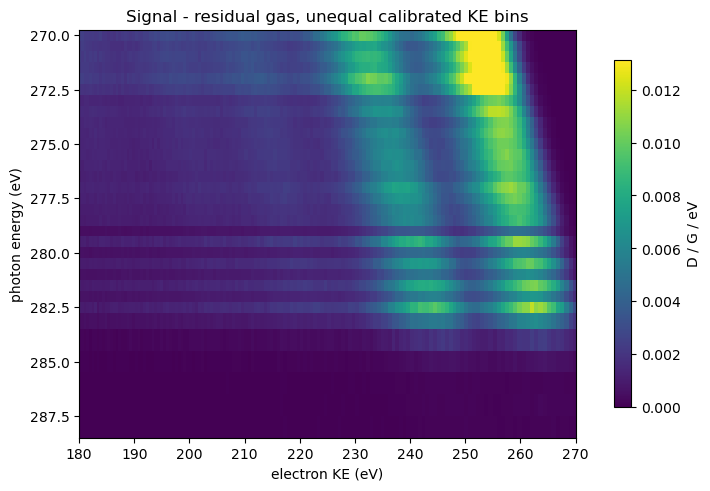

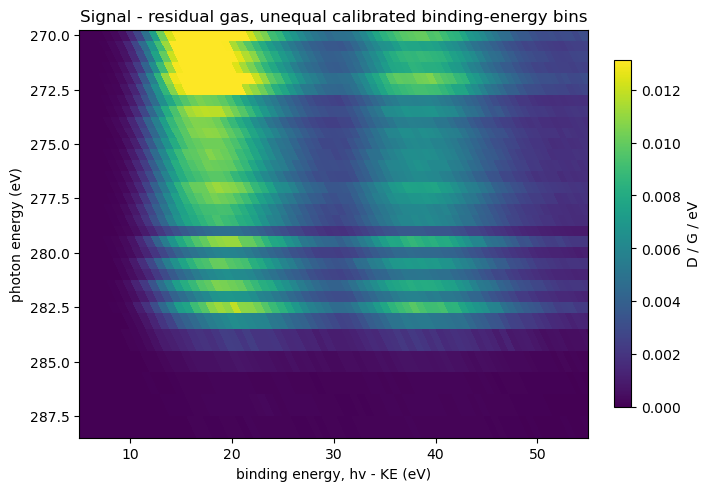

In [48]:
# --- Plot TOF-binned map on calibrated unequal KE bins and unequal BE bins ---
# No interpolation to a uniform eV grid.

MAP_TO_PLOT = subtracted_total   # shape: (n_photon_energies, n_tof_bins)
MAP_LABEL = "Signal - residual gas"
TOF_RANGE = (800, 1100)

KE_XLIM = (180, 270)
BE_XLIM = (5, 55)

VMAX = None          # e.g. 0.015, or None for robust auto
ROW_NORMALISE_BE = False


def _half_step_edges(x):
    x = np.asarray(x, dtype=float)
    if x.size == 1:
        return np.array([x[0] - 0.5, x[0] + 0.5])
    mid = 0.5 * (x[:-1] + x[1:])
    return np.concatenate([[2 * x[0] - mid[0]], mid, [2 * x[-1] - mid[-1]]])


def _robust_limits_local(a, p_lo=1, p_hi=99.5):
    finite = np.asarray(a)[np.isfinite(a)]
    if finite.size == 0:
        return 0.0, 1.0
    return float(np.nanpercentile(finite, p_lo)), float(np.nanpercentile(finite, p_hi))


def tof_map_to_unequal_ke_density(tof_edges, tof_map, tof_range):
    """
    Slice TOF-binned data, convert TOF edges to calibrated KE edges,
    and divide by unequal KE bin width.

    Input units:  D/G per TOF bin
    Output units: D/G per eV
    """
    tof_edges = np.asarray(tof_edges, dtype=float)
    tof_map = np.asarray(tof_map, dtype=float)

    tof_cent = 0.5 * (tof_edges[:-1] + tof_edges[1:])

    mask = np.ones_like(tof_cent, dtype=bool)
    if tof_range[0] is not None:
        mask &= tof_cent >= tof_range[0]
    if tof_range[1] is not None:
        mask &= tof_cent <= tof_range[1]

    idx = np.where(mask)[0]
    if idx.size == 0:
        raise ValueError(f"No TOF bins inside TOF_RANGE={tof_range}")

    lo = int(idx[0])
    hi = int(idx[-1]) + 1

    data = tof_map[:, lo:hi]
    ke_edges = tof_to_ke(tof_edges[lo:hi + 1])

    if not np.all(np.isfinite(ke_edges)):
        raise ValueError("Some KE edges are NaN. Choose a TOF range fully above t0.")

    ke_widths = np.abs(np.diff(ke_edges))

    with np.errstate(invalid="ignore", divide="ignore"):
        data = data / ke_widths[None, :]

    # TOF increases while KE decreases, so reverse to increasing KE.
    if ke_edges[0] > ke_edges[-1]:
        ke_edges = ke_edges[::-1]
        data = data[:, ::-1]

    return ke_edges, data


e_edges = _half_step_edges(energies)
ke_edges_unequal, map_ke_density = tof_map_to_unequal_ke_density(
    tof_edges,
    MAP_TO_PLOT,
    TOF_RANGE,
)

vmin, vmax = _robust_limits_local(map_ke_density)
if VMAX is not None:
    vmax = VMAX

# --- 1) KE plot: unequal calibrated eV bins ---------------------------

fig, ax = plt.subplots(figsize=(7, 4.8), constrained_layout=True)

pcm = ax.pcolormesh(
    ke_edges_unequal,
    e_edges,
    map_ke_density,
    shading="auto",
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
)

fig.colorbar(pcm, ax=ax, shrink=0.85, label="D / G / eV")
ax.set_xlabel("electron KE (eV)")
ax.set_ylabel("photon energy (eV)")
ax.set_title(f"{MAP_LABEL}, unequal calibrated KE bins")
ax.set_xlim(KE_XLIM)
ax.set_ylim(np.nanmax(e_edges), np.nanmin(e_edges))
plt.show()


# --- 2) Binding-energy plot: unequal slanted BE bins -------------------
# BE = hv - KE. Since hv is the y-axis, the true BE bin edges depend on row.

be_x_edges = e_edges[:, None] - ke_edges_unequal[None, :]
be_y_edges = np.repeat(e_edges[:, None], len(ke_edges_unequal), axis=1)

# Reverse columns so binding energy increases left-to-right.
be_x_edges = be_x_edges[:, ::-1]
map_be_density = map_ke_density[:, ::-1]

if ROW_NORMALISE_BE:
    be_widths = np.abs(np.diff(be_x_edges, axis=1))
    row_integral = np.nansum(map_be_density * be_widths[:-1, :], axis=1)
    with np.errstate(invalid="ignore", divide="ignore"):
        map_be_density = map_be_density / row_integral[:, None]
    cbar_label = "row-normalised intensity / eV"
else:
    cbar_label = "D / G / eV"

vmin, vmax = _robust_limits_local(map_be_density)
if VMAX is not None and not ROW_NORMALISE_BE:
    vmax = VMAX

fig, ax = plt.subplots(figsize=(7, 4.8), constrained_layout=True)

pcm = ax.pcolormesh(
    be_x_edges,
    be_y_edges,
    map_be_density,
    shading="auto",
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
)

fig.colorbar(pcm, ax=ax, shrink=0.85, label=cbar_label)
ax.set_xlabel("binding energy, hv - KE (eV)")
ax.set_ylabel("photon energy (eV)")
ax.set_title(f"{MAP_LABEL}, unequal calibrated binding-energy bins")
ax.set_xlim(BE_XLIM)
ax.set_ylim(np.nanmax(e_edges), np.nanmin(e_edges))
plt.show()

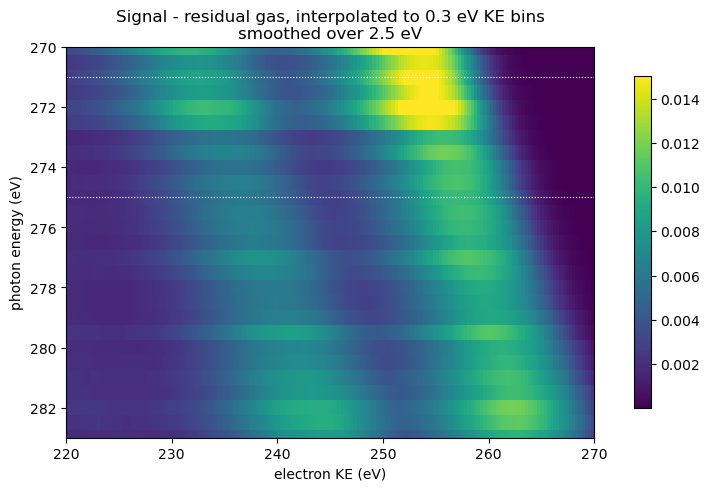

In [338]:
# --- Plot uniform-KE smoothed subtracted map ---------------------------

vmin, vmax = _robust_limits(subtracted_03eV_smoothed)
if SUB_VMAX is not None:
    vmax = SUB_VMAX

fig, ax = plt.subplots(figsize=(7, 4.8), constrained_layout=True)

pcm = ax.pcolormesh(
    ke_edges_03eV,
    e_edges,
    subtracted_03eV_smoothed,
    shading="auto",
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
)

fig.colorbar(pcm, ax=ax, shrink=0.85)
ax.set_xlabel("electron KE (eV)")
ax.set_ylabel("photon energy (eV)")
ax.set_title(
    f"Signal - residual gas, interpolated to {ENERGY_STEP:g} eV KE bins\n"
    f"smoothed over {SMOOTHING_WIDTH_EV:g} eV"
)

if has_background.any():
    ax.axhline(np.nanmin(energies[has_background]), color="w", ls=":", lw=0.8)
    ax.axhline(np.nanmax(energies[has_background]), color="w", ls=":", lw=0.8)

ax.set_ylim(283, 270)
ax.set_xlim(220, 270)

plt.show()

## Intensity and shape scaling

The integrated intensity tracks the total residual-gas yield per GMD. The shape metric compares each spectrum to the mean background shape after area normalisation.

In [ ]:
def spectrum_area(spec, edges):
    # Spectra are histogram counts per summed GMD per bin, not densities.
    # The total yield is therefore the sum over bins.
    return np.nansum(spec, axis=1)


def shape_distance(spec, edges):
    area = spectrum_area(spec, edges)
    shape = spec / area[:, None]
    ref = np.nanmean(shape, axis=0)
    return np.sqrt(np.nansum((shape - ref) ** 2, axis=1))


e_area = spectrum_area(bg_spec_e, ETOF_BIN_EDGES)
i_area = spectrum_area(bg_spec_i, ITOF_BIN_EDGES)
e_shape_dist = shape_distance(bg_spec_e, ETOF_BIN_EDGES)
i_shape_dist = shape_distance(bg_spec_i, ITOF_BIN_EDGES)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), constrained_layout=True)
axes[0].plot(bg_energies, e_area, "o-", label="eTOF")
axes[0].plot(bg_energies, i_area, "o-", label="iTOF")
axes[0].set_xlabel("photon energy (eV)")
axes[0].set_ylabel("integrated hits / GMD")
axes[0].set_title("Background intensity")
axes[0].legend()

axes[1].plot(bg_energies, e_shape_dist, "o-", label="eTOF")
axes[1].plot(bg_energies, i_shape_dist, "o-", label="iTOF")
axes[1].set_xlabel("photon energy (eV)")
axes[1].set_ylabel("distance from mean shape")
axes[1].set_title("Background shape variation")
axes[1].legend()
plt.show()

## Save the per-energy background product

This creates a compact H5 file with the merged, GMD-normalised background spectra. Downstream glycine notebooks can interpolate this onto their energy axis and subtract by matching TOF bins.

In [ ]:
OUT_H5 = Path(path_config.COMBINED_DIR).parent / "xas_static" / f"run{RUN_NO}_cfg1_background_per_energy.h5"

with h5py.File(OUT_H5, "w") as f:
    f.create_dataset("energies", data=bg_energies)
    f.create_dataset("etof_edges", data=ETOF_BIN_EDGES)
    f.create_dataset("itof_edges", data=ITOF_BIN_EDGES)
    f.create_dataset("etof_background", data=bg_spec_e)
    f.create_dataset("itof_background", data=bg_spec_i)
    f.create_dataset("section_energies", data=bg["energies"])
    f.create_dataset("section_n_shots", data=bg["n_shots"])
    f.create_dataset("section_sum_gmd", data=bg_sum_gmd)
    f.attrs["source_static_xas"] = str(BACKGROUND_STATIC_H5)
    f.attrs["normalisation"] = "hits per summed GMD per TOF bin"
    f.attrs["duplicate_energy_policy"] = DUPLICATE_ENERGY_POLICY

print("wrote", OUT_H5)

## Optional glycine subtraction

Set `SIGNAL_STATIC_H5` above to a glycine static-XAS file with compatible TOF binning. This section plots the glycine signal map, the residual-gas background interpolated onto the glycine photon-energy axis, and the difference.

In [ ]:
if SIGNAL_STATIC_H5 is not None:
    sig = load_static_xas(SIGNAL_STATIC_H5)
    sig_spec_e_raw, sig_sum_gmd, _, _ = spectra_per_energy(
        sig["tofs_e"], sig["gmd"], sig["n_shots"], ETOF_BIN_EDGES
    )
    sig_spec_i_raw, _, _, _ = spectra_per_energy(
        sig["tofs_i"], sig["gmd"], sig["n_shots"], ITOF_BIN_EDGES
    )

    sig_energies, sig_spec_e = resolve_duplicate_energies(
        sig_spec_e_raw, sig["energies"], policy=DUPLICATE_ENERGY_POLICY, weights=sig_sum_gmd
    )
    _, sig_spec_i = resolve_duplicate_energies(
        sig_spec_i_raw, sig["energies"], policy=DUPLICATE_ENERGY_POLICY, weights=sig_sum_gmd
    )

    bg_on_sig_e = np.vstack([
        np.interp(sig_energies, bg_energies, bg_spec_e[:, j], left=np.nan, right=np.nan)
        for j in range(bg_spec_e.shape[1])
    ]).T
    bg_on_sig_i = np.vstack([
        np.interp(sig_energies, bg_energies, bg_spec_i[:, j], left=np.nan, right=np.nan)
        for j in range(bg_spec_i.shape[1])
    ]).T

    sub_e = sig_spec_e - BACKGROUND_SCALE * bg_on_sig_e
    sub_i = sig_spec_i - BACKGROUND_SCALE * bg_on_sig_i

    plot_map(sig_spec_e, ETOF_BIN_EDGES, sig_energies, title="Glycine eTOF signal", clabel="hits / GMD / bin", tof_range=ETOF_RANGE)
    plt.show()
    plot_map(bg_on_sig_e, ETOF_BIN_EDGES, sig_energies, title="Residual-gas eTOF background on glycine energy axis", clabel="hits / GMD / bin", tof_range=ETOF_RANGE)
    plt.show()
    plot_diff_map(sub_e, ETOF_BIN_EDGES, sig_energies, title="Glycine eTOF minus residual-gas background", clabel="subtracted hits / GMD / bin", tof_range=ETOF_RANGE)
    plt.show()

    plot_map(sig_spec_i, ITOF_BIN_EDGES, sig_energies, title="Glycine iTOF signal", clabel="hits / GMD / bin", tof_range=ITOF_RANGE)
    plt.show()
    plot_map(bg_on_sig_i, ITOF_BIN_EDGES, sig_energies, title="Residual-gas iTOF background on glycine energy axis", clabel="hits / GMD / bin", tof_range=ITOF_RANGE)
    plt.show()
    plot_diff_map(sub_i, ITOF_BIN_EDGES, sig_energies, title="Glycine iTOF minus residual-gas background", clabel="subtracted hits / GMD / bin", tof_range=ITOF_RANGE)
    plt.show()

elif SIGNAL_AGG_FILES is not None:
    sig = load_signal_aggregate_map(SIGNAL_AGG_FILES, gmd_bin=SIGNAL_GMD_BIN)
    sig_energies = sig["energies"]
    sig_spec_e = sig["spec_e"]
    sig_edges = sig["tof_edges"]

    bg_spec_for_signal = rebin_background_if_needed(bg_spec_e, ETOF_BIN_EDGES, sig_edges)
    bg_on_sig_e = np.vstack([
        np.interp(sig_energies, bg_energies, bg_spec_for_signal[:, j], left=np.nan, right=np.nan)
        for j in range(bg_spec_for_signal.shape[1])
    ]).T
    sub_e = sig_spec_e - BACKGROUND_SCALE * bg_on_sig_e

    suffix = "weighted over GMD bins" if SIGNAL_GMD_BIN is None else f"GMD bin {SIGNAL_GMD_BIN}"
    plot_map(sig_spec_e, sig_edges, sig_energies, title=f"Glycine aggregate eTOF signal ({suffix})", clabel="D / G", tof_range=ETOF_RANGE)
    plt.show()
    plot_map(bg_on_sig_e, sig_edges, sig_energies, title="Residual-gas eTOF background on glycine aggregate energy axis", clabel="hits / GMD / bin", tof_range=ETOF_RANGE)
    plt.show()
    plot_diff_map(sub_e, sig_edges, sig_energies, title="Glycine aggregate eTOF minus residual-gas background", clabel="subtracted D / G", tof_range=ETOF_RANGE)
    plt.show()

else:
    print("Set SIGNAL_STATIC_H5 or SIGNAL_AGG_FILES to enable glycine subtraction plots.")

# High GMD Auger search